## Purifying Selection in CREs
- TFBS Komposition 
    - von CREs im design um kardiac vs neuro 
    - von CREs mit signifikanter Aktivität
- Korrelation von phastCons vs MPRA Aktivität => purifying selection
- What do I expect? 
  - generally: more TFBS more activity
  - this depends on the distribution of the CREs in the group with the activity

In [2]:
import seaborn as sns
import ast
import sys
import pandas as pd
import numpy as np # For potential NaN handling if needed
import os


sys.path.append('../../00_helpful_functions')
import helpful_functions as hf
# from importlib import reload
# reload(hf)

# column names
col_name = 'name'
col_header = 'name'
col_sequence = 'sequence'
col_category = 'category'
col_class = 'class'
col_source = 'source'
col_ref = 'ref'
col_chr = 'chr'
col_start = 'start'
col_end = 'end'
col_strand = 'strand'
col_variant_class = 'variant_class'
col_variant_pos = 'variant_pos'
col_SPDI = 'SPDI'
col_allele = 'allele'
col_info = 'info'


list_columns = [col_variant_class, col_variant_pos, col_SPDI, col_allele]

# Function to safely evaluate string representations of lists
def safe_eval(x):
    if pd.isna(x):
        return None
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return x


import re

def extract_eh38e_number(header):
    # Use regex to find the pattern that starts with EH38E followed by digits
    match = re.search(r"EH38E\d+", header)
    if match:
        return match.group(0)  # Return the matched string
    return None  # Return None if no match is found


import yaml

config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/global80K_config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()

significance_threshold = 0.05

In [2]:
# load CRE data:
config["files"]["creating"]["NGN2_element_metadata_with_bcalm_2025_04_bbmap_normalized_counts_scrambled"]
NGN2_element_activity = pd.read_csv(config["files"]["creating"]["NGN2_element_metadata_with_bcalm_2025_04_bbmap_normalized_counts_scrambled"], sep="\t", low_memory=False)
NGN2_element_activity

,name,sequence,category,class,source,ref,chr,start,end,strand,...,SPDI,allele,info,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,bcalm_data_exists,label,not_shifted_bcalm_element_log_ratio_activity,bcalm_element_log_ratio_activity_z_score_neg_ctrl,bcalm_element_log_ratio_activity_z_score_scrambled_ctrl
0,GC_Mohlke:REF_NC000001.11|159752292|A|G|Mohlke...,ATACATCCTTTAATTTGTTCCTACATCTTGCTTGGATTTTCCCCTG...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,159752058.0,159752328.0,+,...,['NC_000001.11:159752292:A:G'],['ref'],NaN,1.000000e+00,0.002170,True,GC_Mohlke,0.002170,2.425938,0.447914
1,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...,TGTGTCTGGTGAGGTTGCTGACACTGCTTTTGGATGAGAGAGAGAG...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159023.0,230159293.0,+,...,['NC_000001.11:230159168:C:T'],['ref'],NaN,1.000000e+00,-0.005898,True,GC_Mohlke,-0.005898,2.197536,0.239294
2,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...,GTTTACCCAGCCGTGGGAAAGGACGCTGTACCCCTGCCCTATTGGC...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159136.0,230159406.0,+,...,"['NC_000001.11:230159168:C:T', 'NC_000001.11:2...","['ref', 'ref']",NaN,1.000000e+00,0.005348,True,GC_Mohlke,0.005348,2.515917,0.530100
3,GC_Mohlke:ALT_NC000001.11|230158967|C|A|Mohlke...,GTTTACCCAGCCGTGGGAAAGGACGCTGTACCCCTGCCCTATTGGC...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159136.0,230159406.0,+,...,['NC_000001.11:230159328:TCTTAAAGTGTTCAGCACTCC...,['alt'],NaN,1.000000e+00,-0.007093,True,GC_Mohlke,-0.007093,2.163688,0.208377
4,GC_Mohlke:REF_NC000001.11|230161389|C|T|Mohlke...,CCTCAACTCTCCACATGCCCCAGTAGCATAGACCAGCTTCCTTACA...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230161269.0,230161539.0,+,...,['NC_000001.11:230161389:C:T'],['ref'],NaN,1.332728e-33,0.184521,True,GC_Mohlke,0.184521,7.588730,5.163559
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80210,GC_Glut_Chengyu:Glut|chr12:44940899-44941168|-...,TGTCCAAAAAAAGTAAAAGTCATAACAGAAATTGGATTTCAAATGG...,element,element inactive control,NaN,GRCh38,chr12,44940898.0,44941168.0,-,...,NaN,NaN,NaN,1.000000e+00,-0.007241,True,GC_Glut_Chengyu,-0.007241,2.159500,0.204552
80211,GC_Glut_Chengyu:Glut|chr2:212699381-212699650|...,TGTGAGTGCTATAATTGTAACCCTTTATAATTGACAGACATTAATT...,element,element inactive control,NaN,GRCh38,chr2,212699380.0,212699650.0,+,...,NaN,NaN,NaN,1.000000e+00,0.030434,True,GC_Glut_Chengyu,0.030434,3.226171,1.178839
80212,GC_Glut_Chengyu:Glut|chr10:26798829-26799098|-...,TTTAATAGGAGTACTATTGAATTTACATTTAATGTAGTTAATGATA...,element,element inactive control,NaN,GRCh38,chr10,26798828.0,26799098.0,-,...,NaN,NaN,NaN,1.614862e-02,0.051942,True,GC_Glut_Chengyu,0.051942,3.835118,1.735046
80213,GC_Glut_Chengyu:Glut|chr7:31260964-31261233|+|...,TTTCTTATACTGTATGTTTAAAGATATAGACAATGCATATACAAGT...,element,element inactive control,NaN,GRCh38,chr7,31260963.0,31261233.0,+,...,NaN,NaN,NaN,9.615387e-01,0.039459,True,GC_Glut_Chengyu,0.039459,3.481679,1.412218


In [3]:
NGN2_element_activity.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'label',
       'not_shifted_bcalm_element_log_ratio_activity',
       'bcalm_element_log_ratio_activity_z_score_neg_ctrl',
       'bcalm_element_log_ratio_activity_z_score_scrambled_ctrl'],
      dtype='object')

In [4]:
NGN2_element_activity_tested = NGN2_element_activity.loc[NGN2_element_activity['name'].str.startswith("cardiac_neuro_cava_random")].copy()
NGN2_element_activity_tested


NGN2_element_activity_tested['SCREEN_ID'] = NGN2_element_activity_tested["name"].apply(extract_eh38e_number)
NGN2_element_activity_tested

,name,sequence,category,class,source,ref,chr,start,end,strand,...,allele,info,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,bcalm_data_exists,label,not_shifted_bcalm_element_log_ratio_activity,bcalm_element_log_ratio_activity_z_score_neg_ctrl,bcalm_element_log_ratio_activity_z_score_scrambled_ctrl,SCREEN_ID
2287,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843.0,2182113.0,+,...,NaN,NaN,1.000000,-0.074506,True,cardiac_neuro_cava_random,-0.074506,0.255056,-1.534950,EH38E2778476
2288,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439.0,2182709.0,+,...,NaN,NaN,1.000000,0.024747,True,cardiac_neuro_cava_random,0.024747,3.065142,1.031757,EH38E2778477
2289,cardiac_neuro_cava_random:SKI|ENSG00000157933....,ACGAGCAAGGGAATGAGAGAGAGTGGGTTAGAGAGTGAGTGAGCCA...,element,test,NaN,GRCh38,chr1,2182830.0,2183100.0,+,...,NaN,NaN,1.000000,0.058800,True,cardiac_neuro_cava_random,0.058800,4.029274,1.912386,EH38E2778478
2290,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CGTGGACACGCGTGATTGACCCTTTAACTGTATCCTTAACCACCGC...,element,test,NaN,GRCh38,chr1,2185027.0,2185297.0,+,...,NaN,NaN,1.000000,-0.071544,True,cardiac_neuro_cava_random,-0.071544,0.338923,-1.458346,EH38E2778480
2291,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389.0,2188659.0,+,...,NaN,NaN,1.000000,-0.044408,True,cardiac_neuro_cava_random,-0.044408,1.107215,-0.756596,EH38E2778484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76222,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,variant,test,NaN,GRCh38,chrX,154545000.0,154545270.0,-,...,['alt'],NaN,0.451154,0.065547,True,cardiac_neuro_cava_random,0.065547,4.220287,2.086855,EH38E3949733
76223,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,variant,test,NaN,GRCh38,chrX,154549802.0,154550072.0,-,...,['alt'],NaN,0.091747,-0.090558,True,cardiac_neuro_cava_random,-0.090558,-0.199415,-1.950059,EH38E2774396
76224,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,variant,test,NaN,GRCh38,chrX,154552145.0,154552415.0,-,...,['alt'],NaN,0.436290,0.052674,True,cardiac_neuro_cava_random,0.052674,3.855845,1.753977,EH38E3949745
76225,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCTC...,variant,test,NaN,GRCh38,chrX,154552145.0,154552415.0,-,...,['alt'],NaN,1.000000,0.016824,True,cardiac_neuro_cava_random,0.016824,2.840822,0.826865,EH38E3949745


In [5]:
# write screen id based region list:
SCREEN_region_bed = NGN2_element_activity_tested[['chr', 'start', 'end', 'SCREEN_ID']].drop_duplicates(subset=["SCREEN_ID"])
SCREEN_region_bed["start"] = SCREEN_region_bed["start"].astype(int)
SCREEN_region_bed["end"] = SCREEN_region_bed["end"].astype(int)
SCREEN_region_bed
write_output = False
if write_output:
    screen_region_output = "/home/kisa/coding/80K_MPRA/singleton_frequency_per_element/tested_genomic_SCREEN_regions.bed"
    SCREEN_region_bed.to_csv(screen_region_output, sep="\t", index=False, header=False)


In [6]:
# add gene name and gene list
def get_gene_name(header, with_controls=True):
    """Returns the gene name: cardiac_neuro_cava_random:SKI|ENSG00000157933.11|EH38E2778533_fwd_tile1-1 => SKI"""
    if 'cardiac_neuro_cava_random' not in header:
        if not with_controls:
            print(header)
            raise ValueError("Function only defined for tested headers")
        return "Not given - control sequence"


    if 'ALT_' in header:
        return header.split(":ALT_")[1].split('|')[0]

    if 'REF_' in header:
        return header.split(":REF_")[1].split('|')[0]

    return header.split(':')[1].split('|')[0]

from collections import defaultdict
def get_gene_lookup_dict(gene_lists, gene_list_dir='/home/kisa/coding/80K_MPRA/MPRA_design/resources/gene_lists'):
    """
    prepare a dict which has gene_name: (list of associated gene_sets)
    :gene_lists - list of files containing gene names and have useful names
    """
    gene_lookup_dict = defaultdict(list)
    for file in gene_lists:
        with open(os.path.join(gene_list_dir, file), 'r') as f:
            gene_list = f.read().splitlines()
            gene_list_name = file.split('.')[0]
            for gene in gene_list:
                gene_lookup_dict[gene].append(gene_list_name)
    return gene_lookup_dict

# get gene_list files:
gene_list_dir = '/home/kisa/coding/80K_MPRA/MPRA_design/resources/gene_lists'
gene_lists = [gene_list for gene_list in os.listdir(gene_list_dir) if gene_list.endswith('.txt')]

# prepare a dict which has gene_name: (tuple of associated gene_sets)
gene_lookup_dict = get_gene_lookup_dict(gene_lists=gene_lists, gene_list_dir=gene_list_dir)
# # get gene name from variant id
NGN2_element_activity_tested['gene_name'] = NGN2_element_activity_tested['name'].apply(get_gene_name)
# add gene_set annotation
NGN2_element_activity_tested['gene_set'] = NGN2_element_activity_tested['gene_name'].apply(lambda gene: gene_lookup_dict[gene])
NGN2_element_activity_tested['gene_set'].value_counts()

gene_set
[neuro]                   35550
[cardiac]                 21153
[cava]                     8699
[random]                   4716
[neuro, cardiac]           2246
[neuro, cava]               859
[cava, cardiac]             514
[neuro, cava, cardiac]      203
Name: count, dtype: int64

In [7]:
interesting_columns = ['name', 'bcalm_element_adjusted_p_value', 'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'gene_name', 'gene_set', 'SCREEN_ID']
NGN2_element_activity_tested.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'label',
       'not_shifted_bcalm_element_log_ratio_activity',
       'bcalm_element_log_ratio_activity_z_score_neg_ctrl',
       'bcalm_element_log_ratio_activity_z_score_scrambled_ctrl', 'SCREEN_ID',
       'gene_name', 'gene_set'],
      dtype='object')

In [8]:
NGN2_element_activity_tested = NGN2_element_activity_tested.loc[NGN2_element_activity_tested['bcalm_data_exists']].copy()
# Consider only Reference sequences:
NGN2_natural_CREs_tested = NGN2_element_activity_tested.loc[~NGN2_element_activity_tested['name'].str.contains("ALT_")]

In [9]:
NGN2_natural_CREs_tested

,name,sequence,category,class,source,ref,chr,start,end,strand,...,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,bcalm_data_exists,label,not_shifted_bcalm_element_log_ratio_activity,bcalm_element_log_ratio_activity_z_score_neg_ctrl,bcalm_element_log_ratio_activity_z_score_scrambled_ctrl,SCREEN_ID,gene_name,gene_set
2287,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843.0,2182113.0,+,...,1.000000,-0.074506,True,cardiac_neuro_cava_random,-0.074506,0.255056,-1.534950,EH38E2778476,SKI,[neuro]
2288,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439.0,2182709.0,+,...,1.000000,0.024747,True,cardiac_neuro_cava_random,0.024747,3.065142,1.031757,EH38E2778477,SKI,[neuro]
2289,cardiac_neuro_cava_random:SKI|ENSG00000157933....,ACGAGCAAGGGAATGAGAGAGAGTGGGTTAGAGAGTGAGTGAGCCA...,element,test,NaN,GRCh38,chr1,2182830.0,2183100.0,+,...,1.000000,0.058800,True,cardiac_neuro_cava_random,0.058800,4.029274,1.912386,EH38E2778478,SKI,[neuro]
2290,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CGTGGACACGCGTGATTGACCCTTTAACTGTATCCTTAACCACCGC...,element,test,NaN,GRCh38,chr1,2185027.0,2185297.0,+,...,1.000000,-0.071544,True,cardiac_neuro_cava_random,-0.071544,0.338923,-1.458346,EH38E2778480,SKI,[neuro]
2291,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389.0,2188659.0,+,...,1.000000,-0.044408,True,cardiac_neuro_cava_random,-0.044408,1.107215,-0.756596,EH38E2778484,SKI,[neuro]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29848,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,ACCCCACTGCTGCACCAGATTGAGCTGGAGAAGCCCAAGCCCATCC...,variant,test,NaN,GRCh38,chrX,154531979.0,154532249.0,-,...,1.000000,-0.087741,True,cardiac_neuro_cava_random,-0.087741,-0.119654,-1.877206,EH38E3949715,G6PD,[cava]
29849,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,TTGCTGAGTAGTATCCGTTGTATGAATGCACAGTTTGCCGGGTCAC...,variant,test,NaN,GRCh38,chrX,154539055.0,154539325.0,-,...,1.000000,0.025920,True,cardiac_neuro_cava_random,0.025920,3.098377,1.062113,EH38E3949725,G6PD,[cava]
29850,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,variant,test,NaN,GRCh38,chrX,154545000.0,154545270.0,-,...,0.015993,0.100370,True,cardiac_neuro_cava_random,0.100370,5.206220,2.987397,EH38E3949733,G6PD,[cava]
29851,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,variant,test,NaN,GRCh38,chrX,154549802.0,154550072.0,-,...,1.000000,-0.080632,True,cardiac_neuro_cava_random,-0.080632,0.081627,-1.693358,EH38E2774396,G6PD,[cava]


In [10]:
print("significance_threshold: ", significance_threshold)
print(f"Number of significant tested CREs among the reference CREs {NGN2_natural_CREs_tested.loc[NGN2_natural_CREs_tested['bcalm_element_adjusted_p_value'] < significance_threshold].shape[0]} out of {NGN2_natural_CREs_tested.shape[0]} ({(NGN2_natural_CREs_tested.loc[NGN2_natural_CREs_tested['bcalm_element_adjusted_p_value'] < significance_threshold].shape[0] / NGN2_natural_CREs_tested.shape[0]) * 100:.2f}%)")

significance_threshold:  0.05
Number of significant tested CREs among the reference CREs 1358 out of 25578 (5.31%)


/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth

<Figure size 1000x600 with 0 Axes>

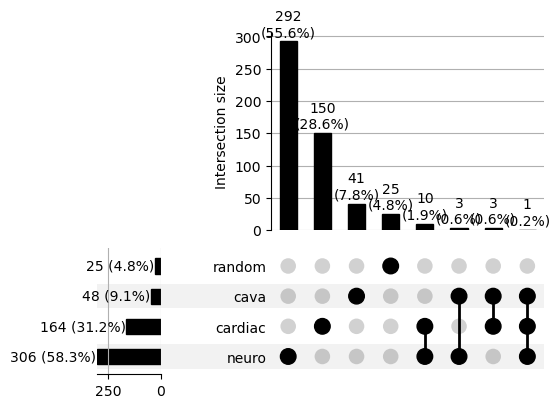

In [11]:
import upsetplot
import matplotlib.pyplot as plt
## Upset plot of gene names:
gene_name_groups = {}
for group in ['neuro', 'cava', 'cardiac', 'random']:
    gene_name_groups[group] = NGN2_natural_CREs_tested[
        NGN2_natural_CREs_tested['gene_set'].apply(lambda x: group in x)
    ]['gene_name'].unique()

upset_data = upsetplot.from_contents(gene_name_groups)

# Create the UpSet plot
fig = plt.figure(figsize=(10, 6))
upsetplot.plot(upset_data, show_counts=True, show_percentages=True)  # Pass the correctly structured data
# plt.title("Upset plot of gene names per group.")
# plt.ylabel("Number of genes")
# plt.xlabel("Gene groups")

plt.tight_layout()
plt.show()


### Investigate the Activity distribution of the gene-based groups

In [12]:
NGN2_natural_CREs_tested.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'label',
       'not_shifted_bcalm_element_log_ratio_activity',
       'bcalm_element_log_ratio_activity_z_score_neg_ctrl',
       'bcalm_element_log_ratio_activity_z_score_scrambled_ctrl', 'SCREEN_ID',
       'gene_name', 'gene_set'],
      dtype='object')

In [13]:
NGN2_natural_CREs_tested

,name,sequence,category,class,source,ref,chr,start,end,strand,...,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,bcalm_data_exists,label,not_shifted_bcalm_element_log_ratio_activity,bcalm_element_log_ratio_activity_z_score_neg_ctrl,bcalm_element_log_ratio_activity_z_score_scrambled_ctrl,SCREEN_ID,gene_name,gene_set
2287,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843.0,2182113.0,+,...,1.000000,-0.074506,True,cardiac_neuro_cava_random,-0.074506,0.255056,-1.534950,EH38E2778476,SKI,[neuro]
2288,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439.0,2182709.0,+,...,1.000000,0.024747,True,cardiac_neuro_cava_random,0.024747,3.065142,1.031757,EH38E2778477,SKI,[neuro]
2289,cardiac_neuro_cava_random:SKI|ENSG00000157933....,ACGAGCAAGGGAATGAGAGAGAGTGGGTTAGAGAGTGAGTGAGCCA...,element,test,NaN,GRCh38,chr1,2182830.0,2183100.0,+,...,1.000000,0.058800,True,cardiac_neuro_cava_random,0.058800,4.029274,1.912386,EH38E2778478,SKI,[neuro]
2290,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CGTGGACACGCGTGATTGACCCTTTAACTGTATCCTTAACCACCGC...,element,test,NaN,GRCh38,chr1,2185027.0,2185297.0,+,...,1.000000,-0.071544,True,cardiac_neuro_cava_random,-0.071544,0.338923,-1.458346,EH38E2778480,SKI,[neuro]
2291,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389.0,2188659.0,+,...,1.000000,-0.044408,True,cardiac_neuro_cava_random,-0.044408,1.107215,-0.756596,EH38E2778484,SKI,[neuro]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29848,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,ACCCCACTGCTGCACCAGATTGAGCTGGAGAAGCCCAAGCCCATCC...,variant,test,NaN,GRCh38,chrX,154531979.0,154532249.0,-,...,1.000000,-0.087741,True,cardiac_neuro_cava_random,-0.087741,-0.119654,-1.877206,EH38E3949715,G6PD,[cava]
29849,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,TTGCTGAGTAGTATCCGTTGTATGAATGCACAGTTTGCCGGGTCAC...,variant,test,NaN,GRCh38,chrX,154539055.0,154539325.0,-,...,1.000000,0.025920,True,cardiac_neuro_cava_random,0.025920,3.098377,1.062113,EH38E3949725,G6PD,[cava]
29850,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,variant,test,NaN,GRCh38,chrX,154545000.0,154545270.0,-,...,0.015993,0.100370,True,cardiac_neuro_cava_random,0.100370,5.206220,2.987397,EH38E3949733,G6PD,[cava]
29851,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,variant,test,NaN,GRCh38,chrX,154549802.0,154550072.0,-,...,1.000000,-0.080632,True,cardiac_neuro_cava_random,-0.080632,0.081627,-1.693358,EH38E2774396,G6PD,[cava]


#### KDE Plot grouped by gene set

Text(0, 0.5, 'Density')

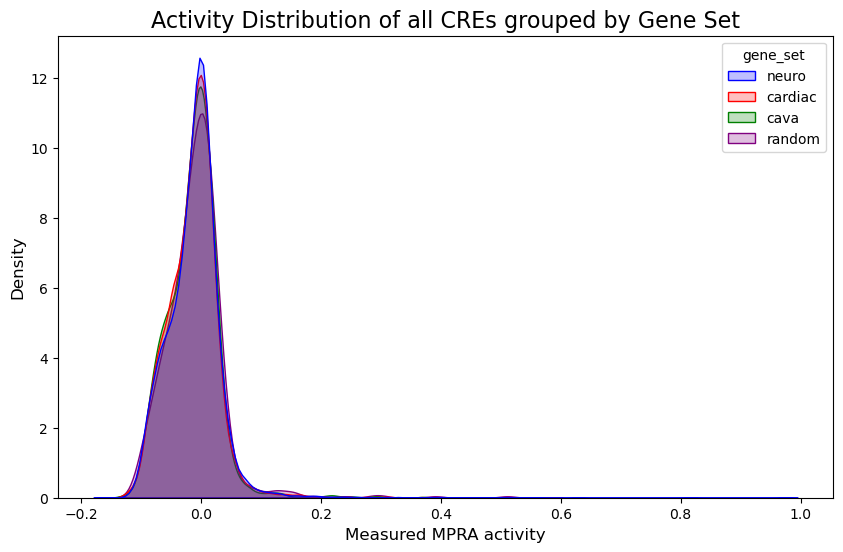

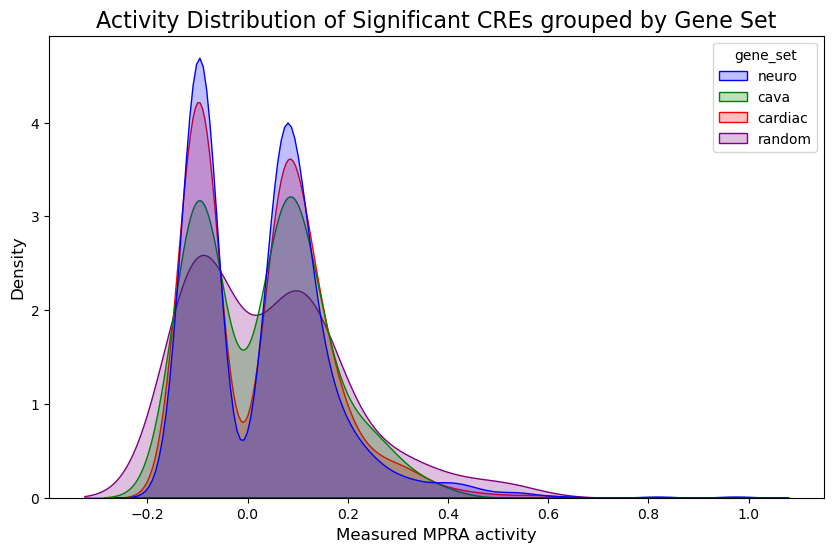

In [14]:
import matplotlib.pyplot as plt

# Define a palette for each gene set
colors = {
    'neuro': 'blue',
    'cardiac': 'red',
    'cava': 'green',
    'random': 'purple'
}
plot_column = "bcalm_element_log_ratio_activity_z_score_scrambled_ctrl"
plot_column = "bcalm_element_log_ratio_activity"
# Create the KDE plot all:
# Explode the 'gene_set' column
df_exploded = NGN2_natural_CREs_tested.loc[NGN2_natural_CREs_tested['bcalm_data_exists']].explode('gene_set')
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_exploded, x=plot_column, hue='gene_set', common_norm=False, fill=True, palette=colors)

# Set title and labels
plt.title('Activity Distribution of all CREs grouped by Gene Set', fontsize=16)
plt.xlabel('Measured MPRA activity', fontsize=12)
plt.ylabel('Density', fontsize=12)
# Create the KDE plot significant
# significance_threshold = 0.1

# Filter for significant sequences
significant_df = NGN2_natural_CREs_tested[NGN2_natural_CREs_tested['bcalm_element_adjusted_p_value'] < significance_threshold].copy()

df_exploded = significant_df.loc[significant_df['bcalm_data_exists']].explode('gene_set')

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_exploded, x=plot_column, hue='gene_set', common_norm=False, fill=True, palette=colors)

# Set title and labels
plt.title('Activity Distribution of Significant CREs grouped by Gene Set', fontsize=16)
plt.xlabel('Measured MPRA activity', fontsize=12)
plt.ylabel('Density', fontsize=12)

/tmp/ipykernel_420402/3754879148.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  NGN2_natural_CREs_tested['activity_bin'] = pd.cut(NGN2_natural_CREs_tested['bcalm_element_log_ratio_activity'], bins=num_bins)
/tmp/ipykernel_420402/3754879148.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_counts = df_exploded.groupby(['activity_bin', 'gene_set']).size().reset_index(name='count')
/tmp/ipykernel_420402/3754879148.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observe

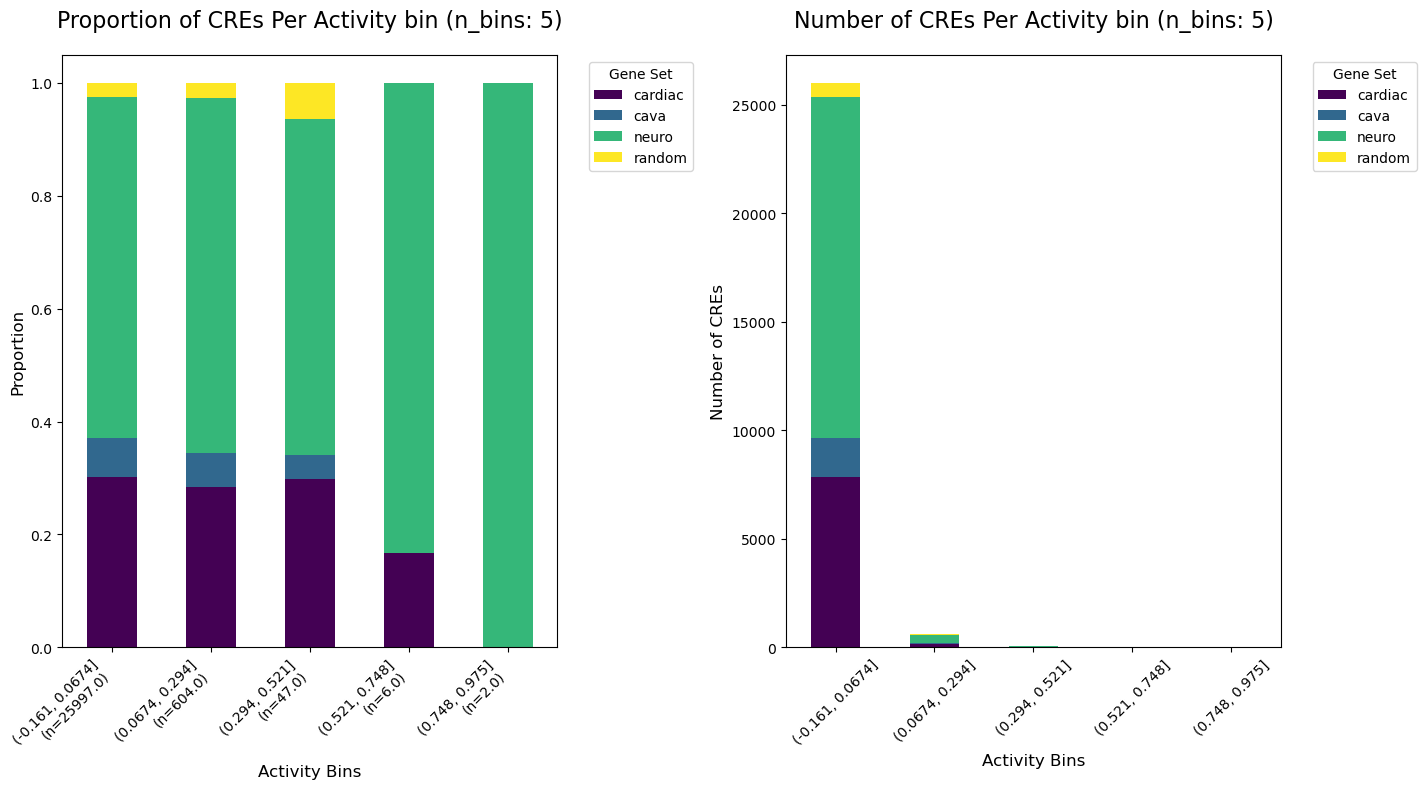

In [15]:
# Set a flexible number of bins, with 5 as the default
num_bins = 5

# Bin the 'bcalm_element_log_ratio_activity' data
NGN2_natural_CREs_tested['activity_bin'] = pd.cut(NGN2_natural_CREs_tested['bcalm_element_log_ratio_activity'], bins=num_bins)
# NGN2_natural_CREs_tested['activity_bin'] = pd.qcut(NGN2_natural_CREs_tested['bcalm_element_log_ratio_activity'], q=num_bins, duplicates='drop')

# Explode the 'gene_set' column so that each gene set becomes a separate row
df_exploded = NGN2_natural_CREs_tested.explode('gene_set')

# Group by the 'activity_bin' and 'gene_set' to count occurrences
bin_counts = df_exploded.groupby(['activity_bin', 'gene_set']).size().reset_index(name='count')

# Calculate the total count for each bin
total_counts_per_bin = bin_counts.groupby('activity_bin')['count'].sum().reset_index(name='total_bin_count')

# Merge the total counts back to the aggregated data to calculate proportions
merged_df = pd.merge(bin_counts, total_counts_per_bin, on='activity_bin')
merged_df['proportion'] = merged_df['count'] / merged_df['total_bin_count']

# Pivot the dataframes for plotting.
proportions_pivot = merged_df.pivot_table(index='activity_bin', columns='gene_set', values='proportion', fill_value=0)
counts_pivot = merged_df.pivot_table(index='activity_bin', columns='gene_set', values='count', fill_value=0)

# --- 3. Plotting with Matplotlib ---

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), sharey=False)

# Get the x-axis labels from the pre-formatted index
bin_labels_base = proportions_pivot.index

# Calculate the total sequences for each bin from the counts_pivot
bin_total_counts = counts_pivot.sum(axis=1)

# Create the new labels with the counts
bin_labels_with_counts = [f'{label}\n(n={bin_total_counts[label]})' for label in bin_labels_base]


# Plot the Proportions Stacked Bar Chart on the first subplot
proportions_pivot.plot(kind='bar', stacked=True, ax=ax1, colormap='viridis')
ax1.set_title(f'Proportion of CREs Per Activity bin (n_bins: {num_bins})', fontsize=16, pad=20)
ax1.set_xlabel('Activity Bins', fontsize=12)
ax1.set_ylabel('Proportion', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.set_xticklabels(bin_labels_with_counts, rotation=45, ha='right')
ax1.legend(title='Gene Set', bbox_to_anchor=(1.05, 1), loc='upper left')


# Plot the Number of CREs Stacked Bar Chart on the second subplot
counts_pivot.plot(kind='bar', stacked=True, ax=ax2, colormap='viridis')
ax2.set_title(f'Number of CREs Per Activity bin (n_bins: {num_bins})', fontsize=16, pad=20)
ax2.set_xlabel('Activity Bins', fontsize=12)
ax2.set_ylabel('Number of CREs', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.legend(title='Gene Set', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout to prevent labels from overlapping
plt.tight_layout(rect=[0, 0, 0.9, 1])

In [16]:
total_counts_per_bin

,activity_bin,total_bin_count
0,"(-0.161, 0.0674]",25997
1,"(0.0674, 0.294]",604
2,"(0.294, 0.521]",47
3,"(0.521, 0.748]",6
4,"(0.748, 0.975]",2


In [17]:
NGN2_natural_CREs_tested['activity_bin'].value_counts()

activity_bin
(-0.161, 0.0674]    24943
(0.0674, 0.294]       581
(0.294, 0.521]         46
(0.521, 0.748]          6
(0.748, 0.975]          2
Name: count, dtype: int64

/tmp/ipykernel_420402/2656077257.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  NGN2_natural_CREs_tested['activity_bin'] = pd.qcut(NGN2_natural_CREs_tested['bcalm_element_log_ratio_activity'], q=num_bins, duplicates='drop')
/tmp/ipykernel_420402/2656077257.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_counts = df_exploded.groupby(['activity_bin', 'gene_set']).size().reset_index(name='count')
/tmp/ipykernel_420402/2656077257.py:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future ver

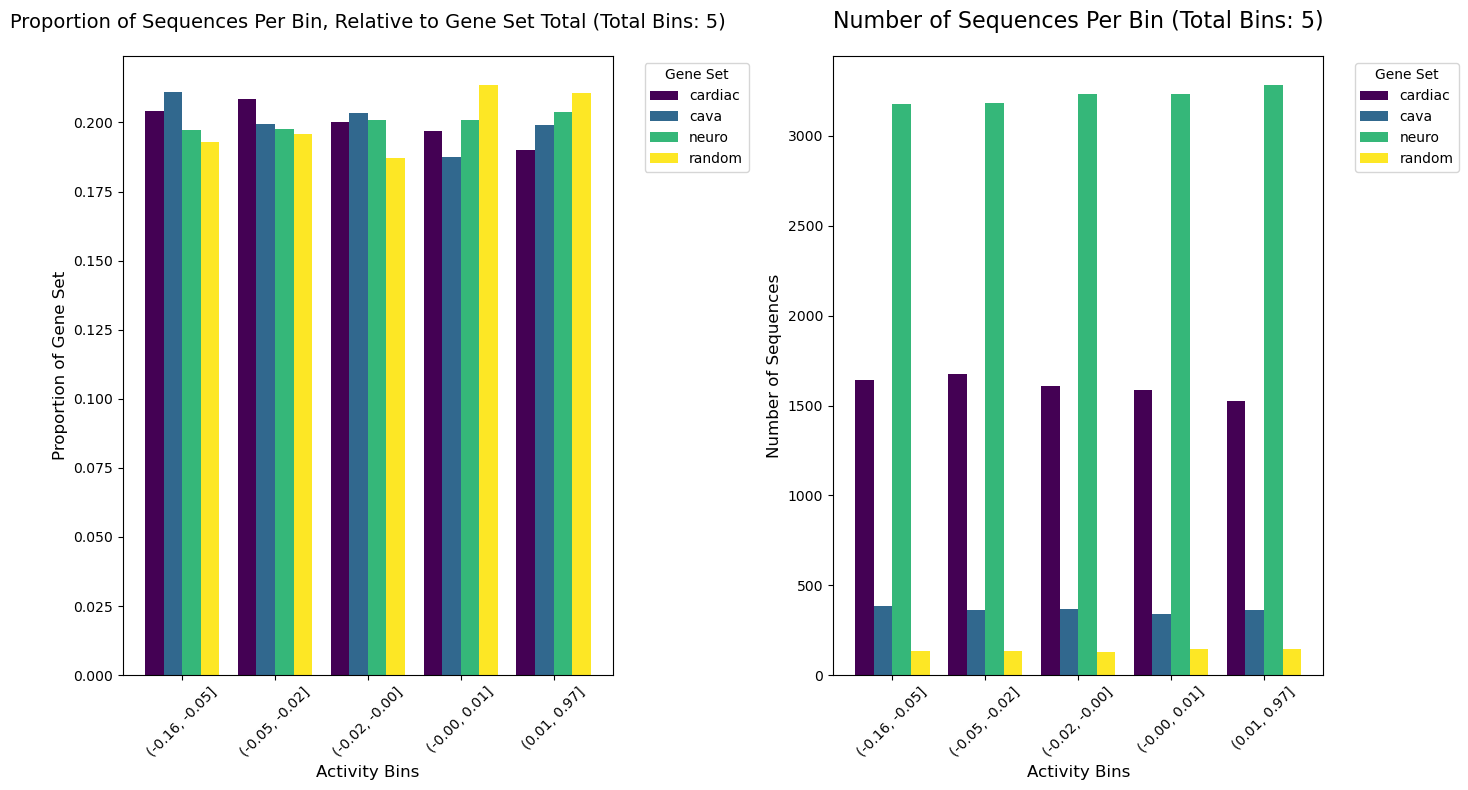

In [18]:
import matplotlib.pyplot as plt
# Set a flexible number of bins, with 5 as the default
num_bins = 5

# Bin the 'bcalm_element_log_ratio_activity' data using pd.qcut for equal number of sequences per bin
NGN2_natural_CREs_tested['activity_bin'] = pd.qcut(NGN2_natural_CREs_tested['bcalm_element_log_ratio_activity'], q=num_bins, duplicates='drop')

# Explode the 'gene_set' column so that each gene set becomes a separate row
df_exploded = NGN2_natural_CREs_tested.explode('gene_set')

# Group by the 'activity_bin' and 'gene_set' to count occurrences
bin_counts = df_exploded.groupby(['activity_bin', 'gene_set']).size().reset_index(name='count')

# Calculate the total count for each gene set across the entire dataframe
gene_set_total_counts = df_exploded.groupby('gene_set').size().reset_index(name='total_gene_set_count')

# Merge the total counts back into the bin_counts dataframe
merged_df = pd.merge(bin_counts, gene_set_total_counts, on='gene_set')

# Calculate the new proportion relative to the total number of sequences for each group
merged_df['proportion'] = merged_df['count'] / merged_df['total_gene_set_count']

# Pivot the dataframes for plotting.
proportions_pivot = merged_df.pivot_table(index='activity_bin', columns='gene_set', values='proportion', fill_value=0)
counts_pivot = bin_counts.pivot_table(index='activity_bin', columns='gene_set', values='count', fill_value=0)

# --- 3. Plotting with Matplotlib ---

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), sharey=False)

# Parameters for the grouped bar plots
n_bins = len(proportions_pivot.index)
n_groups = len(proportions_pivot.columns)
bar_width = 0.2
x = np.arange(n_bins)
colors = plt.cm.viridis(np.linspace(0, 1, n_groups))
groups = proportions_pivot.columns

# Plot the Proportions Grouped Bar Chart on the first subplot
for i, group in enumerate(groups):
    ax1.bar(x + i * bar_width, proportions_pivot[group], bar_width, label=group, color=colors[i])

ax1.set_title(f'Proportion of Sequences Per Bin, Relative to Gene Set Total (Total Bins: {n_bins})', fontsize=14, pad=20)
ax1.set_xlabel('Activity Bins', fontsize=12)
ax1.set_ylabel('Proportion of Gene Set', fontsize=12)
ax1.set_xticks(x + bar_width * (n_groups - 1) / 2)
ax1.set_xticklabels([f'({bin.left:.2f}, {bin.right:.2f}]' for bin in proportions_pivot.index], rotation=45)
ax1.legend(title='Gene Set', bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot the Counts Grouped Bar Chart on the second subplot
for i, group in enumerate(groups):
    ax2.bar(x + i * bar_width, counts_pivot[group], bar_width, label=group, color=colors[i])

ax2.set_title(f'Number of Sequences Per Bin (Total Bins: {n_bins})', fontsize=16, pad=20)
ax2.set_xlabel('Activity Bins', fontsize=12)
ax2.set_ylabel('Number of Sequences', fontsize=12)
ax2.set_xticks(x + bar_width * (n_groups - 1) / 2)
ax2.set_xticklabels([f'({bin.left:.2f}, {bin.right:.2f}]' for bin in counts_pivot.index], rotation=45)
ax2.legend(title='Gene Set', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout to prevent labels from overlapping
plt.tight_layout(rect=[0, 0, 0.9, 1])

Use the p-value and effect size to group the data based on their activity meaningful and investigate the distribution of the gene set

In [19]:
# significance_threshold = 0.1
num_sub_bins = 3

# Filter for significant sequences and split into Increasing/Decreasing
significant_df = NGN2_natural_CREs_tested[NGN2_natural_CREs_tested['bcalm_element_adjusted_p_value'] < significance_threshold].copy()
not_significant_df = NGN2_natural_CREs_tested[NGN2_natural_CREs_tested['bcalm_element_adjusted_p_value'] >= significance_threshold].copy()

# Bin significant sequences
increasing_df = significant_df[significant_df['bcalm_element_log_ratio_activity'] > 0].copy()
decreasing_df = significant_df[significant_df['bcalm_element_log_ratio_activity'] < 0].copy()

if not increasing_df.empty:
    increasing_df['bin_label'] = pd.qcut(increasing_df['bcalm_element_log_ratio_activity'], q=num_sub_bins, duplicates='drop')
else:
    increasing_df['bin_label'] = pd.Series(dtype='category')

if not decreasing_df.empty:
    decreasing_df['bin_label'] = pd.qcut(decreasing_df['bcalm_element_log_ratio_activity'], q=num_sub_bins, duplicates='drop')
else:
    decreasing_df['bin_label'] = pd.Series(dtype='category')

# Create a single bin for all non-significant sequences
if not not_significant_df.empty:
    min_val = not_significant_df['bcalm_element_log_ratio_activity'].min()
    max_val = not_significant_df['bcalm_element_log_ratio_activity'].max()
    not_significant_df['bin_label'] = pd.Interval(min_val, max_val, closed='right')
else:
    not_significant_df['bin_label'] = pd.Series(dtype='category')

# Concatenate all binned data
binned_df = pd.concat([decreasing_df, not_significant_df, increasing_df])

# Create a unique, human-readable label for plotting
def create_unique_label(row):
    label = row['bin_label']
    if not isinstance(label, pd.Interval):
        return 'Not Significant'

    category = 'Not Significant'
    if label in set(increasing_df['bin_label'].unique()):
        category = 'Increasing'
    elif label in set(decreasing_df['bin_label'].unique()):
        category = 'Decreasing'

    return f'({label.left:.2f}, {label.right:.2f}]'

binned_df['plot_label'] = binned_df.apply(create_unique_label, axis=1)

# Sort the bins by their mean value
bin_order = sorted(binned_df['bin_label'].unique(), key=lambda x: x.mid)

# Get the labels for the ordered bins to re-index the pivot tables
sorted_plot_labels = [create_unique_label({'bin_label': bin_val}) for bin_val in bin_order]


# Explode the 'gene_set' column
df_exploded = binned_df.explode('gene_set')

# Group and count occurrences
bin_counts = df_exploded.groupby(['plot_label', 'gene_set']).size().reset_index(name='count')

# Calculate total count for each gene set across the entire dataframe for proportion calculation
gene_set_total_counts = df_exploded.groupby('gene_set').size().reset_index(name='total_gene_set_count')

# Merge and calculate the proportion
merged_df = pd.merge(bin_counts, gene_set_total_counts, on='gene_set')
merged_df['proportion'] = merged_df['count'] / merged_df['total_gene_set_count']

# Pivot for plotting and re-index with the custom order
proportions_pivot = merged_df.pivot_table(index='plot_label', columns='gene_set', values='proportion', fill_value=0).reindex(sorted_plot_labels)
counts_pivot = bin_counts.pivot_table(index='plot_label', columns='gene_set', values='count', fill_value=0).reindex(sorted_plot_labels)

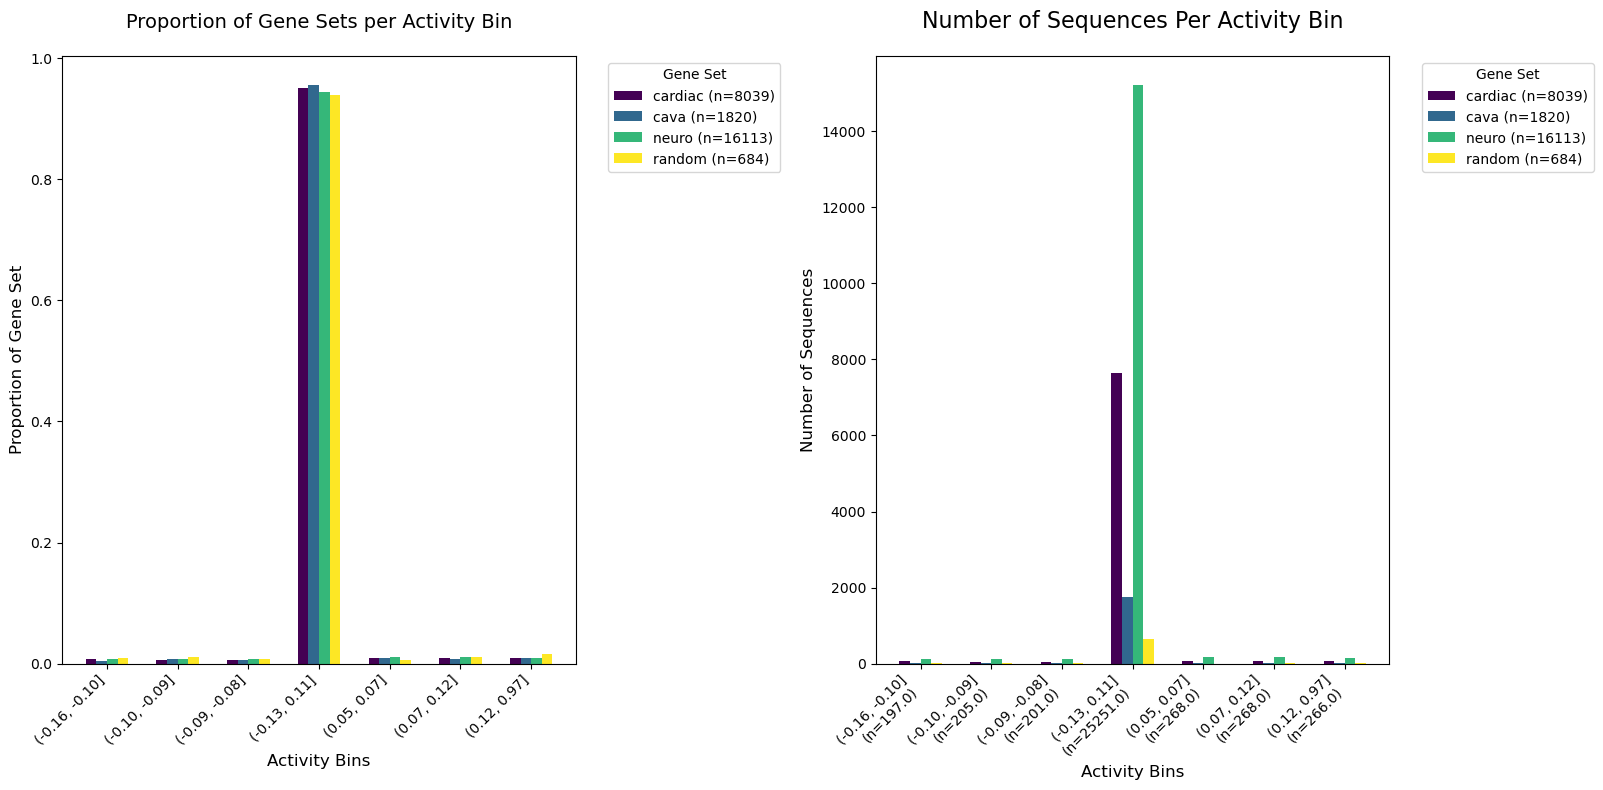

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), sharey=False)

n_bins = len(proportions_pivot.index)
n_groups = len(proportions_pivot.columns)
bar_width = 0.15
x = np.arange(n_bins)
colors = plt.cm.viridis(np.linspace(0, 1, n_groups))
groups = proportions_pivot.columns

# Get the x-axis labels from the pre-formatted index
bin_labels_base = proportions_pivot.index

# Calculate the total sequences for each bin from the counts_pivot
bin_total_counts = counts_pivot.sum(axis=1)

# Create the new labels with the counts
bin_labels_with_counts = [f'{label}\n(n={bin_total_counts[label]})' for label in bin_labels_base]

# Create a dictionary to map gene set to its total count
gene_set_counts_dict = gene_set_total_counts.set_index('gene_set')['total_gene_set_count'].to_dict()

# Plot the Proportions Grouped Bar Chart
for i, group in enumerate(groups):
    # Add the total count to the legend label
    label = f'{group} (n={gene_set_counts_dict.get(group, 0)})'
    ax1.bar(x + i * bar_width, proportions_pivot[group], bar_width, label=label, color=colors[i])

ax1.set_title(f'Proportion of Gene Sets per Activity Bin', fontsize=14, pad=20)
ax1.set_xlabel('Activity Bins', fontsize=12)
ax1.set_ylabel('Proportion of Gene Set', fontsize=12)
ax1.set_xticks(x + bar_width * (n_groups - 1) / 2)
ax1.set_xticklabels(bin_labels_base, rotation=45, ha='right')
ax1.legend(title='Gene Set', bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot the Counts Grouped Bar Chart
for i, group in enumerate(groups):
    # Add the total count to the legend label
    label = f'{group} (n={gene_set_counts_dict.get(group, 0)})'
    ax2.bar(x + i * bar_width, counts_pivot[group], bar_width, label=label, color=colors[i])

ax2.set_title('Number of Sequences Per Activity Bin', fontsize=16, pad=20)
ax2.set_xlabel('Activity Bins', fontsize=12)
ax2.set_ylabel('Number of Sequences', fontsize=12)
ax2.set_xticks(x + bar_width * (n_groups - 1) / 2)
ax2.set_xticklabels(bin_labels_with_counts, rotation=45, ha='right')
ax2.legend(title='Gene Set', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout(rect=[0, 0, 0.9, 1])

##### Only significant

In [21]:
# significance_threshold = 0.1
num_sub_bins = 3

# Filter for significant sequences only
significant_df = NGN2_natural_CREs_tested[NGN2_natural_CREs_tested['bcalm_element_adjusted_p_value'] < significance_threshold].copy()

# Bin significant sequences
increasing_df = significant_df[significant_df['bcalm_element_log_ratio_activity'] > 0].copy()
decreasing_df = significant_df[significant_df['bcalm_element_log_ratio_activity'] < 0].copy()

if not increasing_df.empty:
    increasing_df['bin_label'] = pd.qcut(increasing_df['bcalm_element_log_ratio_activity'], q=num_sub_bins, duplicates='drop')
else:
    increasing_df['bin_label'] = pd.Series(dtype='category')

if not decreasing_df.empty:
    decreasing_df['bin_label'] = pd.qcut(decreasing_df['bcalm_element_log_ratio_activity'], q=num_sub_bins, duplicates='drop')
else:
    decreasing_df['bin_label'] = pd.Series(dtype='category')

# Concatenate all binned data
binned_df = pd.concat([decreasing_df, increasing_df])

# Create a unique, human-readable label for plotting
def create_unique_label(row):
    label = row['bin_label']
    return f'({label.left:.2f}, {label.right:.2f}]'

if not binned_df.empty:
    binned_df['plot_label'] = binned_df.apply(create_unique_label, axis=1)
else:
    binned_df['plot_label'] = pd.Series(dtype='object')


# Sort the bins by their mean value
if not binned_df.empty:
    bin_order = sorted(binned_df['bin_label'].unique(), key=lambda x: x.mid)
    sorted_plot_labels = [create_unique_label({'bin_label': bin_val}) for bin_val in bin_order]
else:
    sorted_plot_labels = []


# Explode the 'gene_set' column
df_exploded = binned_df.explode('gene_set')

# Group and count occurrences
bin_counts = df_exploded.groupby(['plot_label', 'gene_set']).size().reset_index(name='count')

# Calculate total count for each gene set across the entire dataframe for proportion calculation
gene_set_total_counts = df_exploded.groupby('gene_set').size().reset_index(name='total_gene_set_count')

# Merge and calculate the proportion
merged_df = pd.merge(bin_counts, gene_set_total_counts, on='gene_set')
merged_df['proportion'] = merged_df['count'] / merged_df['total_gene_set_count']

# Pivot for plotting and re-index with the custom order
proportions_pivot = merged_df.pivot_table(index='plot_label', columns='gene_set', values='proportion', fill_value=0).reindex(sorted_plot_labels)
counts_pivot = bin_counts.pivot_table(index='plot_label', columns='gene_set', values='count', fill_value=0).reindex(sorted_plot_labels)

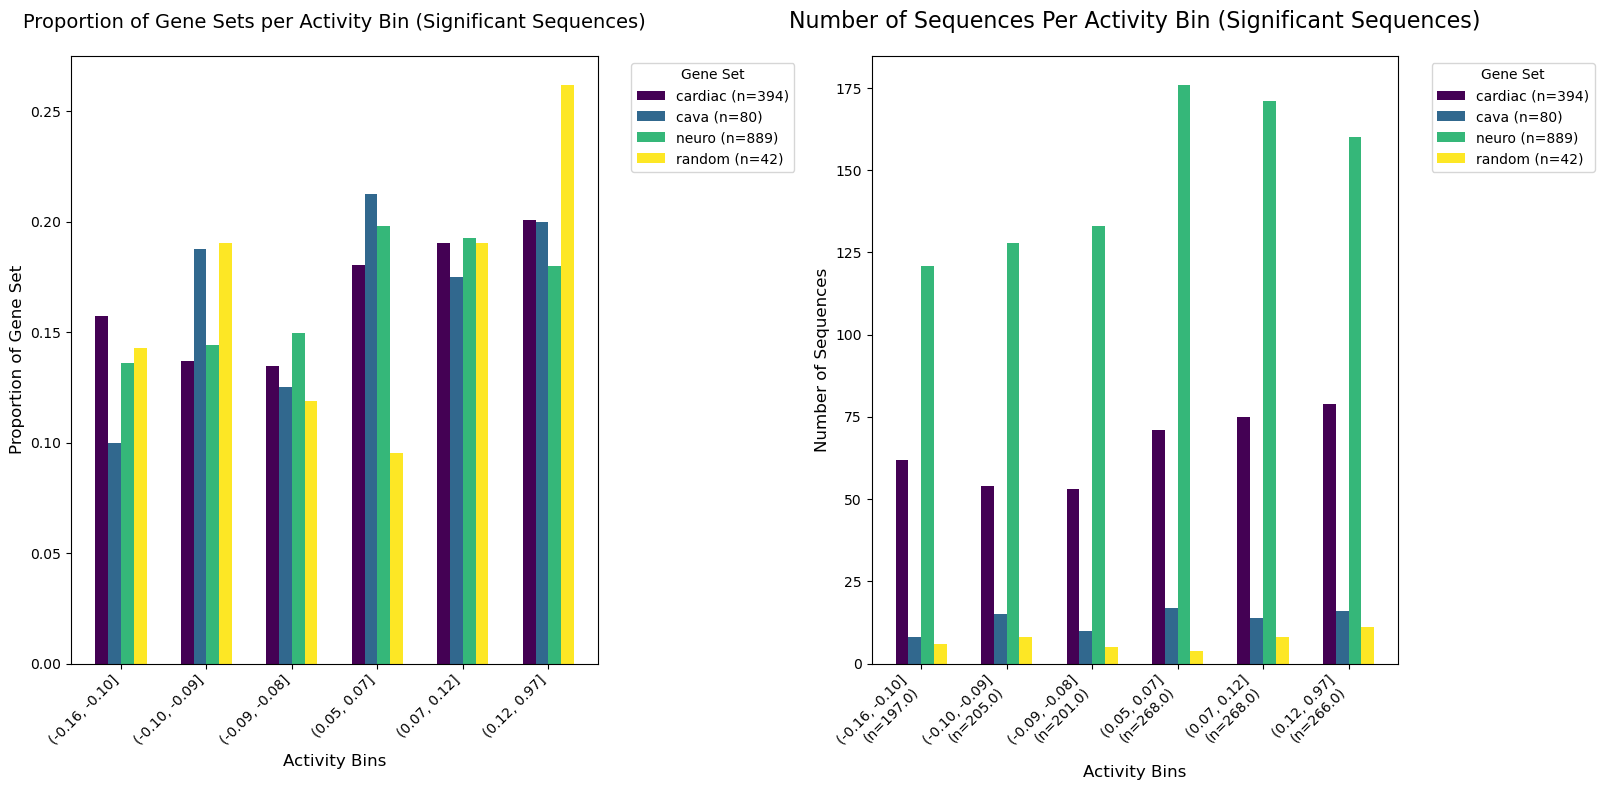

In [22]:
# --- 3. Plotting with Matplotlib ---

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), sharey=False)

n_bins = len(proportions_pivot.index)
n_groups = len(proportions_pivot.columns)
bar_width = 0.15
x = np.arange(n_bins)
colors = plt.cm.viridis(np.linspace(0, 1, n_groups))
groups = proportions_pivot.columns

# Get the x-axis labels from the pre-formatted index
bin_labels_base = proportions_pivot.index

# Calculate the total sequences for each bin from the counts_pivot
bin_total_counts = counts_pivot.sum(axis=1)

# Create the new labels with the counts
bin_labels_with_counts = [f'{label}\n(n={bin_total_counts[label]})' for label in bin_labels_base]

# Create a dictionary to map gene set to its total count
gene_set_counts_dict = gene_set_total_counts.set_index('gene_set')['total_gene_set_count'].to_dict()

# Plot the Proportions Grouped Bar Chart
for i, group in enumerate(groups):
    # Add the total count to the legend label
    label = f'{group} (n={gene_set_counts_dict.get(group, 0)})'
    ax1.bar(x + i * bar_width, proportions_pivot[group], bar_width, label=label, color=colors[i])

ax1.set_title(f'Proportion of Gene Sets per Activity Bin (Significant Sequences)', fontsize=14, pad=20)
ax1.set_xlabel('Activity Bins', fontsize=12)
ax1.set_ylabel('Proportion of Gene Set', fontsize=12)
ax1.set_xticks(x + bar_width * (n_groups - 1) / 2)
ax1.set_xticklabels(bin_labels_base, rotation=45, ha='right')
ax1.legend(title='Gene Set', bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot the Counts Grouped Bar Chart
for i, group in enumerate(groups):
    # Add the total count to the legend label
    label = f'{group} (n={gene_set_counts_dict.get(group, 0)})'
    ax2.bar(x + i * bar_width, counts_pivot[group], bar_width, label=label, color=colors[i])

ax2.set_title('Number of Sequences Per Activity Bin (Significant Sequences)', fontsize=16, pad=20)
ax2.set_xlabel('Activity Bins', fontsize=12)
ax2.set_ylabel('Number of Sequences', fontsize=12)
ax2.set_xticks(x + bar_width * (n_groups - 1) / 2)
ax2.set_xticklabels(bin_labels_with_counts, rotation=45, ha='right')
ax2.legend(title='Gene Set', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout(rect=[0, 0, 0.9, 1])

##### Only significant binned by activity: not symmetrical

In [23]:
# significance_threshold = 0.1
num_sub_bins = 3

# Filter for significant sequences only
significant_df = NGN2_natural_CREs_tested[NGN2_natural_CREs_tested['bcalm_element_adjusted_p_value'] < significance_threshold].copy()

# Bin significant sequences
increasing_df = significant_df[significant_df['bcalm_element_log_ratio_activity'] > 0].copy()
decreasing_df = significant_df[significant_df['bcalm_element_log_ratio_activity'] < 0].copy()

if not increasing_df.empty:
    increasing_df['bin_label'] = pd.cut(increasing_df['bcalm_element_log_ratio_activity'], bins=num_sub_bins)
else:
    increasing_df['bin_label'] = pd.Series(dtype='category')

if not decreasing_df.empty:
    decreasing_df['bin_label'] = pd.cut(decreasing_df['bcalm_element_log_ratio_activity'], bins=num_sub_bins)
else:
    decreasing_df['bin_label'] = pd.Series(dtype='category')

# Concatenate all binned data
binned_df = pd.concat([decreasing_df, increasing_df])

# Create a unique, human-readable label for plotting
def create_unique_label(row):
    label = row['bin_label']
    return f'({label.left:.2f}, {label.right:.2f}]'

if not binned_df.empty:
    binned_df['plot_label'] = binned_df.apply(create_unique_label, axis=1)
else:
    binned_df['plot_label'] = pd.Series(dtype='object')


# Sort the bins by their mean value
if not binned_df.empty:
    bin_order = sorted(binned_df['bin_label'].unique(), key=lambda x: x.mid)
    sorted_plot_labels = [create_unique_label({'bin_label': bin_val}) for bin_val in bin_order]
else:
    sorted_plot_labels = []


# Explode the 'gene_set' column
df_exploded = binned_df.explode('gene_set')

# Group and count occurrences
bin_counts = df_exploded.groupby(['plot_label', 'gene_set']).size().reset_index(name='count')

# Calculate total count for each gene set across the entire dataframe for proportion calculation
gene_set_total_counts = df_exploded.groupby('gene_set').size().reset_index(name='total_gene_set_count')

# Merge and calculate the proportion
merged_df = pd.merge(bin_counts, gene_set_total_counts, on='gene_set')
merged_df['proportion'] = merged_df['count'] / merged_df['total_gene_set_count']

# Pivot for plotting and re-index with the custom order
proportions_pivot = merged_df.pivot_table(index='plot_label', columns='gene_set', values='proportion', fill_value=0).reindex(sorted_plot_labels)
counts_pivot = bin_counts.pivot_table(index='plot_label', columns='gene_set', values='count', fill_value=0).reindex(sorted_plot_labels)

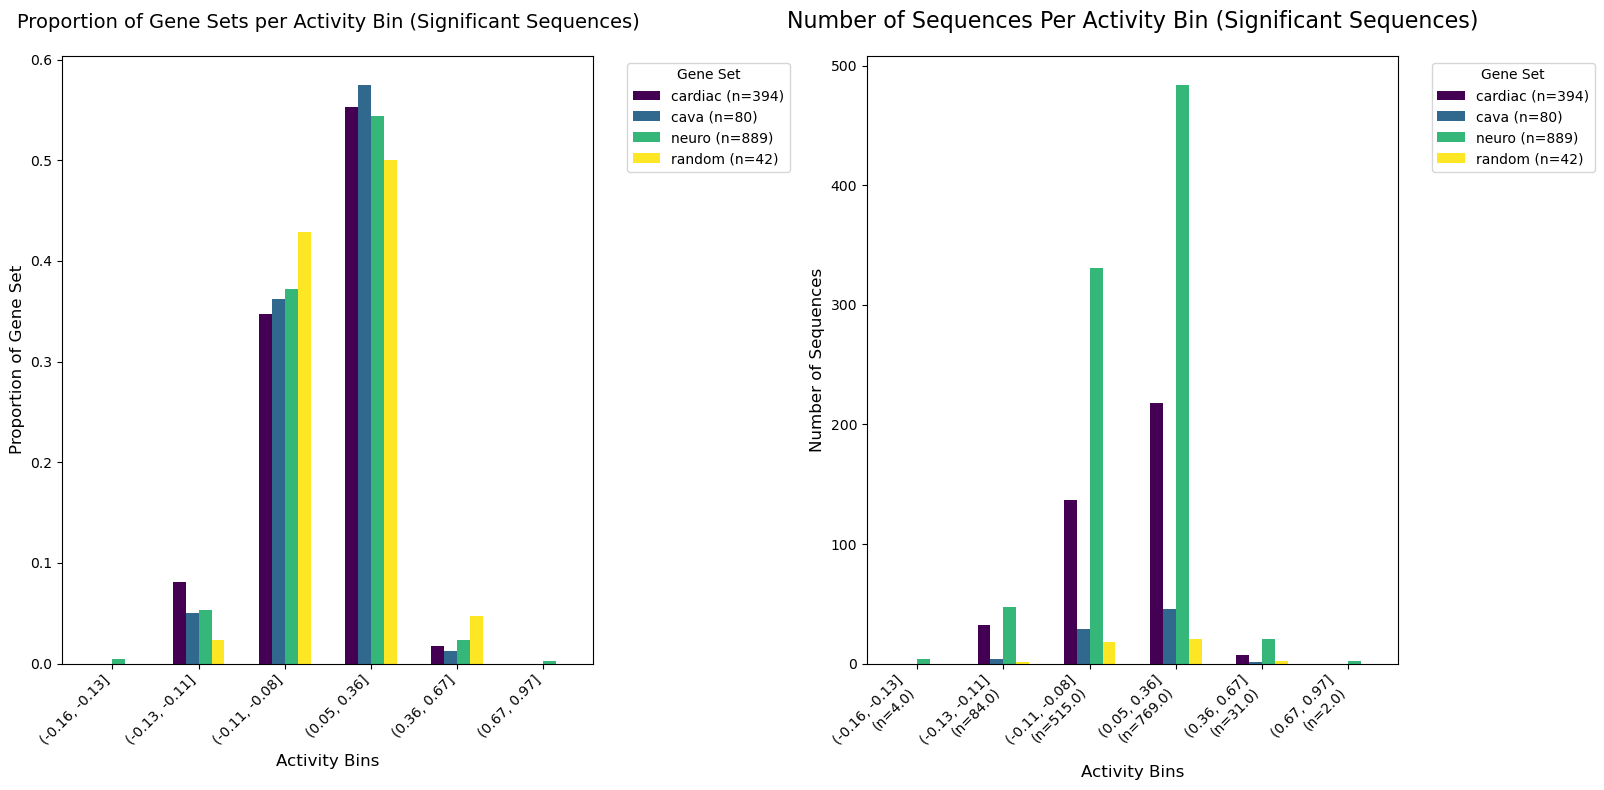

In [24]:
# --- 3. Plotting with Matplotlib ---

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), sharey=False)

n_bins = len(proportions_pivot.index)
n_groups = len(proportions_pivot.columns)
bar_width = 0.15
x = np.arange(n_bins)
colors = plt.cm.viridis(np.linspace(0, 1, n_groups))
groups = proportions_pivot.columns

# Get the x-axis labels from the pre-formatted index
bin_labels_base = proportions_pivot.index

# Calculate the total sequences for each bin from the counts_pivot
bin_total_counts = counts_pivot.sum(axis=1)

# Create the new labels with the counts
bin_labels_with_counts = [f'{label}\n(n={bin_total_counts[label]})' for label in bin_labels_base]

# Create a dictionary to map gene set to its total count
gene_set_counts_dict = gene_set_total_counts.set_index('gene_set')['total_gene_set_count'].to_dict()

# Plot the Proportions Grouped Bar Chart
for i, group in enumerate(groups):
    # Add the total count to the legend label
    label = f'{group} (n={gene_set_counts_dict.get(group, 0)})'
    ax1.bar(x + i * bar_width, proportions_pivot[group], bar_width, label=label, color=colors[i])

ax1.set_title(f'Proportion of Gene Sets per Activity Bin (Significant Sequences)', fontsize=14, pad=20)
ax1.set_xlabel('Activity Bins', fontsize=12)
ax1.set_ylabel('Proportion of Gene Set', fontsize=12)
ax1.set_xticks(x + bar_width * (n_groups - 1) / 2)
ax1.set_xticklabels(bin_labels_base, rotation=45, ha='right')
ax1.legend(title='Gene Set', bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot the Counts Grouped Bar Chart
for i, group in enumerate(groups):
    # Add the total count to the legend label
    label = f'{group} (n={gene_set_counts_dict.get(group, 0)})'
    ax2.bar(x + i * bar_width, counts_pivot[group], bar_width, label=label, color=colors[i])

ax2.set_title('Number of Sequences Per Activity Bin (Significant Sequences)', fontsize=16, pad=20)
ax2.set_xlabel('Activity Bins', fontsize=12)
ax2.set_ylabel('Number of Sequences', fontsize=12)
ax2.set_xticks(x + bar_width * (n_groups - 1) / 2)
ax2.set_xticklabels(bin_labels_with_counts, rotation=45, ha='right')
ax2.legend(title='Gene Set', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout(rect=[0, 0, 0.9, 1])

### Get the TFBS Komposition of cCREs

In [25]:
# remap filtered:
remap_filtered_path = "/home/kisa/coding/80K_MPRA/remap_chipseq_pia/remap_cre_overlap/tested_CREs_remap2022_filtered_summit_overlap_no_border_overlap_min_10bp.bed.gz"
remap_filtered_df = pd.read_csv(remap_filtered_path, sep="\t", header=None, low_memory=False)

remap_filtered_df.columns = ['chrom', 'start', 'end', 'name', 'score', 'strand', 'chrom_B',
       'start_B', 'end_B', 'name_remap', 'score_B', 'strand_B', 'peak_start',
       'peak_end', 'spectrum', 'TF_name', 'overlap_number', 'chip_peak_size',
       'CRE_proportion_overlapped']

In [26]:
remap_filtered_df.columns

Index(['chrom', 'start', 'end', 'name', 'score', 'strand', 'chrom_B',
       'start_B', 'end_B', 'name_remap', 'score_B', 'strand_B', 'peak_start',
       'peak_end', 'spectrum', 'TF_name', 'overlap_number', 'chip_peak_size',
       'CRE_proportion_overlapped'],
      dtype='object')

In [27]:
remap_filtered_df.columns

Index(['chrom', 'start', 'end', 'name', 'score', 'strand', 'chrom_B',
       'start_B', 'end_B', 'name_remap', 'score_B', 'strand_B', 'peak_start',
       'peak_end', 'spectrum', 'TF_name', 'overlap_number', 'chip_peak_size',
       'CRE_proportion_overlapped'],
      dtype='object')

In [28]:
# aggregate a list of TFBS for each sequence given in the dataset and get the number of TFBS overlapping with the sequences
# Group by the sequence identifiers and aggregate the TF_name
# into a list and a count
remap_tfbs_occurences = remap_filtered_df.groupby(['chrom', 'start', 'end', 'name', 'strand']).agg(
    TFBS_list=('TF_name', list),
    number_of_TFBS=('TF_name', 'count')
).reset_index()

print(remap_tfbs_occurences.info())
remap_tfbs_occurences

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65566 entries, 0 to 65565
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   chrom           65566 non-null  object
 1   start           65566 non-null  object
 2   end             65566 non-null  object
 3   name            65566 non-null  object
 4   strand          65566 non-null  object
 5   TFBS_list       65566 non-null  object
 6   number_of_TFBS  65566 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 3.5+ MB
None


,chrom,start,end,name,strand,TFBS_list,number_of_TFBS
0,chr1,10588680,10588950,cardiac_neuro_cava_random:ALT_CASZ1|ENSG000001...,-,[MAFF],1
1,chr1,10588680,10588950,cardiac_neuro_cava_random:ALT_CASZ1|ENSG000001...,-,[MAFF],1
2,chr1,10588680,10588950,cardiac_neuro_cava_random:REF_CASZ1|ENSG000001...,-,[MAFF],1
3,chr1,10594736,10595006,cardiac_neuro_cava_random:ALT_CASZ1|ENSG000001...,-,"[RBPJ, MEF2B, TFAP2C, SND1, ZNF263, POU5F1, SM...",24
4,chr1,10594736,10595006,cardiac_neuro_cava_random:REF_CASZ1|ENSG000001...,-,"[RBPJ, MEF2B, TFAP2C, SND1, ZNF263, POU5F1, SM...",24
...,...,...,...,...,...,...,...
65561,chrX,77786807,77787077,cardiac_neuro_cava_random:REF_ATRX|ENSG0000008...,-,"[ZSCAN4, FOXA1, RFX5, SPI1, ZBTB2, SPIB, KDM1A...",8
65562,chrX,77787587,77787857,cardiac_neuro_cava_random:ATRX|ENSG00000085224...,-,"[BRD4, ZGPAT, HAND2, PHOX2B, ZBED4, TEAD4, SRE...",9
65563,chrX,77788137,77788407,cardiac_neuro_cava_random:ATRX|ENSG00000085224...,-,"[LIN54, SREBP2, MYBL2, FOXA2, ZNF24, KLF4, NFY...",45
65564,chrX,77814307,77814577,cardiac_neuro_cava_random:ATRX|ENSG00000085224...,-,"[ATF7, TBX21, NFIC, ATF2, ATF4, FOXA1, JUNB, M...",14


In [29]:
# add the number of unique TFBS per sequence as measure for TFBS diversity
remap_tfbs_occurences['n_unique_TFBS'] = remap_tfbs_occurences['TFBS_list'].apply(lambda x: len(set(x)))

In [30]:
remap_tfbs_occurences.shape[0]

65566

In [31]:
remap_tfbs_occurences.loc[remap_tfbs_occurences['n_unique_TFBS'] != remap_tfbs_occurences['number_of_TFBS']]

,chrom,start,end,name,strand,TFBS_list,number_of_TFBS,n_unique_TFBS
6,chr1,10599192,10599462,cardiac_neuro_cava_random:CASZ1|ENSG0000013094...,-,"[EGR1, CREBBP, ZNF44, HOXA3, ARID2, MED1, ZBTB...",133,130
16,chr1,10627524,10627794,cardiac_neuro_cava_random:ALT_CASZ1|ENSG000001...,-,"[ELF3, BRD4, AR, ESR1, HNF4A, ELF1, CEBPA, DNM...",13,12
17,chr1,10627524,10627794,cardiac_neuro_cava_random:REF_CASZ1|ENSG000001...,-,"[ELF3, BRD4, AR, ESR1, HNF4A, ELF1, CEBPA, DNM...",13,12
47,chr1,10675074,10675344,cardiac_neuro_cava_random:ALT_CASZ1|ENSG000001...,-,"[ZNF2, WT1, MZF1, KLF4, ZNF561, IKZF3, RUNX1, ...",77,76
48,chr1,10675074,10675344,cardiac_neuro_cava_random:ALT_CASZ1|ENSG000001...,-,"[ZNF2, WT1, MZF1, KLF4, ZNF561, IKZF3, RUNX1, ...",77,76
...,...,...,...,...,...,...,...,...
65528,chrX,71182443,71182713,cardiac_neuro_cava_random:REF_NLGN3|ENSG000001...,+,"[ASH2L, PAXIP1, RBBP5, ZNF652, SRF, FOS, BRD3,...",98,95
65537,chrX,77503094,77503364,cardiac_neuro_cava_random:ATRX|ENSG00000085224...,-,"[PAF1, ZNF528, SP7, PKNOX1, POU5F1, NANOG, SOX...",43,40
65548,chrX,77668495,77668765,cardiac_neuro_cava_random:ATRX|ENSG00000085224...,-,"[HDAC2, RUNX1, ERG, KDM5B, TCF7L2, CDK6, FLI1,...",9,8
65549,chrX,77668930,77669200,cardiac_neuro_cava_random:ALT_ATRX|ENSG0000008...,-,"[KLF6, ELF3, HOXB8, JUNB, ONECUT2, GATA2, ETV4...",74,72


In [32]:
# add the activity:
# remap_tfbs_occurences.merge(NGN2_element_activity_tested[interesting_columns], on='name', how='left')['gene_name'].isna().sum() # 0
designed_cre_activity_remap_tfbs_occurences = remap_tfbs_occurences.merge(NGN2_element_activity_tested[interesting_columns], on='name', how='left')
print(f"Number of sequences: {designed_cre_activity_remap_tfbs_occurences.shape[0]}")

tested_cre_activity_remap_tfbs_occurences = designed_cre_activity_remap_tfbs_occurences.loc[designed_cre_activity_remap_tfbs_occurences['bcalm_data_exists'] == True].copy()
tested_cre_activity_remap_tfbs_occurences
print(f"Number of sequences with measurements: {tested_cre_activity_remap_tfbs_occurences.shape[0]}")


Number of sequences: 65566
Number of sequences with measurements: 65565


In [33]:
# add the screen information:
element_metadata_path = "/home/kisa/coding/80K_MPRA/element_variant_analysis_output/ngn2_wtc11_elements_bcalm_scrambled095_screenv4_annotation_groups_2507_ngn2_neuro_ctrl.tsv.gz"
element_metadata_table = pd.read_csv(element_metadata_path, sep="\t")
element_metadata_table

unique_screen_id_annotation = element_metadata_table.drop_duplicates(subset=["SCREEN_ID"]).copy()
screen_id_cell_type_groups = ['SCREEN_ID', 'is_NPC_SCREEN_cCRE', 'is_H9_SCREEN_cCRE',
       'is_H1_SCREEN_cCRE', 'is_neural_stem_SCREEN_cCRE',
       'is_excitatory_neuron_SCREEN_cCRE']

tested_cre_activity_remap_tfbs_occurences = tested_cre_activity_remap_tfbs_occurences.merge(unique_screen_id_annotation[screen_id_cell_type_groups], on="SCREEN_ID", how="left")

In [34]:
REF_designed_cre_activity_remap_tfbs_occurences = remap_tfbs_occurences.merge(NGN2_natural_CREs_tested[interesting_columns], on='name', how='left')
print(f"Number of sequences: {REF_designed_cre_activity_remap_tfbs_occurences.shape[0]}")

REF_tested_cre_activity_remap_tfbs_occurences = REF_designed_cre_activity_remap_tfbs_occurences.loc[REF_designed_cre_activity_remap_tfbs_occurences['bcalm_data_exists'] == True].copy()
REF_tested_cre_activity_remap_tfbs_occurences = REF_tested_cre_activity_remap_tfbs_occurences.merge(unique_screen_id_annotation[screen_id_cell_type_groups], on="SCREEN_ID", how="left")
REF_tested_cre_activity_remap_tfbs_occurences
print(f"Number of sequences with measurements: {REF_tested_cre_activity_remap_tfbs_occurences.shape[0]}")

Number of sequences: 65566
Number of sequences with measurements: 24586


In [35]:
tested_cre_activity_remap_tfbs_occurences.columns


Index(['chrom', 'start', 'end', 'name', 'strand', 'TFBS_list',
       'number_of_TFBS', 'n_unique_TFBS', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'gene_name',
       'gene_set', 'SCREEN_ID', 'is_NPC_SCREEN_cCRE', 'is_H9_SCREEN_cCRE',
       'is_H1_SCREEN_cCRE', 'is_neural_stem_SCREEN_cCRE',
       'is_excitatory_neuron_SCREEN_cCRE'],
      dtype='object')

In [36]:
REF_tested_cre_activity_remap_tfbs_occurences.columns

Index(['chrom', 'start', 'end', 'name', 'strand', 'TFBS_list',
       'number_of_TFBS', 'n_unique_TFBS', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'gene_name',
       'gene_set', 'SCREEN_ID', 'is_NPC_SCREEN_cCRE', 'is_H9_SCREEN_cCRE',
       'is_H1_SCREEN_cCRE', 'is_neural_stem_SCREEN_cCRE',
       'is_excitatory_neuron_SCREEN_cCRE'],
      dtype='object')

In [37]:
tested_cre_activity_remap_tfbs_occurences['gene_set'].value_counts()

gene_set
[neuro]                   31361
[cardiac]                 18729
[cava]                     7926
[random]                   4318
[neuro, cardiac]           1989
[neuro, cava]               697
[cava, cardiac]             446
[neuro, cava, cardiac]       99
Name: count, dtype: int64

In [38]:
# for only reference CREs:
REF_tested_cre_activity_remap_tfbs_occurences['gene_set'].value_counts()

gene_set
[neuro]                   14521
[cardiac]                  6873
[cava]                     1501
[neuro, cardiac]            772
[random]                    658
[neuro, cava]               150
[cava, cardiac]              97
[neuro, cava, cardiac]       14
Name: count, dtype: int64

#### Plot the number of TFBS per sequence: 
- We see more TFBS in the "cardiac" sequences compared to the "neuro" sequences. 
  - Potential reasons: Neurons are under higher conservational or population constraints, leading to fewer TFBS.
  - 

In [39]:
# plotting function:
import pandas as pd
import matplotlib.pyplot as plt

def plot_gene_set_for_all_sequences(df, group_list, column_to_plot, gene_set_column='gene_set', x_label='Gene Set', y_label='Number of TFBS', title='Mean and Median Number of TFBS for "Neuro", "Cardiac", and "Random" Sequences'):
    """
    Plots the mean and median of a specified column for a list of gene sets.

    Args:
        df (pd.DataFrame): The input DataFrame.
        group_list (list): A list of gene set names (strings) to be plotted.
        column_to_plot (str): The name of the column to plot (e.g., 'number_of_TFBS').
        x_label (str): The label for the x-axis.
        y_label (str): The label for the y-axis.
        title (str): The title of the plot.
    """
    group_result = []
    for group in group_list:
        # Filter sequences for each gene set
        group_sequences = df[
            df[gene_set_column].apply(lambda x: group.lower() in x)
        ]

        # Calculate mean, median, and count for all three groups
        mean_group = group_sequences[column_to_plot].mean()
        median_group = group_sequences[column_to_plot].median()
        count_group = len(group_sequences)

        group_result.append({
            'Gene_Set': group,
            'Mean': mean_group,
            'Median': median_group,
            'Count': count_group
        })


    # Create a DataFrame for plotting
    plot_data = pd.DataFrame(group_result)

    print("Summary Statistics with Group Sizes:")
    print(plot_data)

    # Plotting the data
    fig, ax = plt.subplots(figsize=(12, 6))

    bar_width = 0.35
    index = range(len(group_list))

    ax.bar(index, plot_data['Mean'], bar_width, label='Mean')
    ax.bar([i + bar_width for i in index], plot_data['Median'], bar_width, label='Median')

    # Add group sizes as text labels
    for i, row in plot_data.iterrows():
        ax.text(index[i] + bar_width / 2, row['Mean'] + 0.1, f'n={row["Count"]}', ha='center', va='bottom', fontsize=10)

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.set_xticks([i + bar_width / 2 for i in index])
    ax.set_xticklabels(plot_data['Gene_Set'])
    ax.legend()

    plt.tight_layout()
    plt.show()

Summary Statistics with Group Sizes:
  Gene_Set       Mean  Median  Count
0    Neuro  29.284338    15.0  34146
1  Cardiac  34.208672    18.0  21263
2     Cava  39.732112    22.0   9168
3   Random  41.784623    22.0   4318


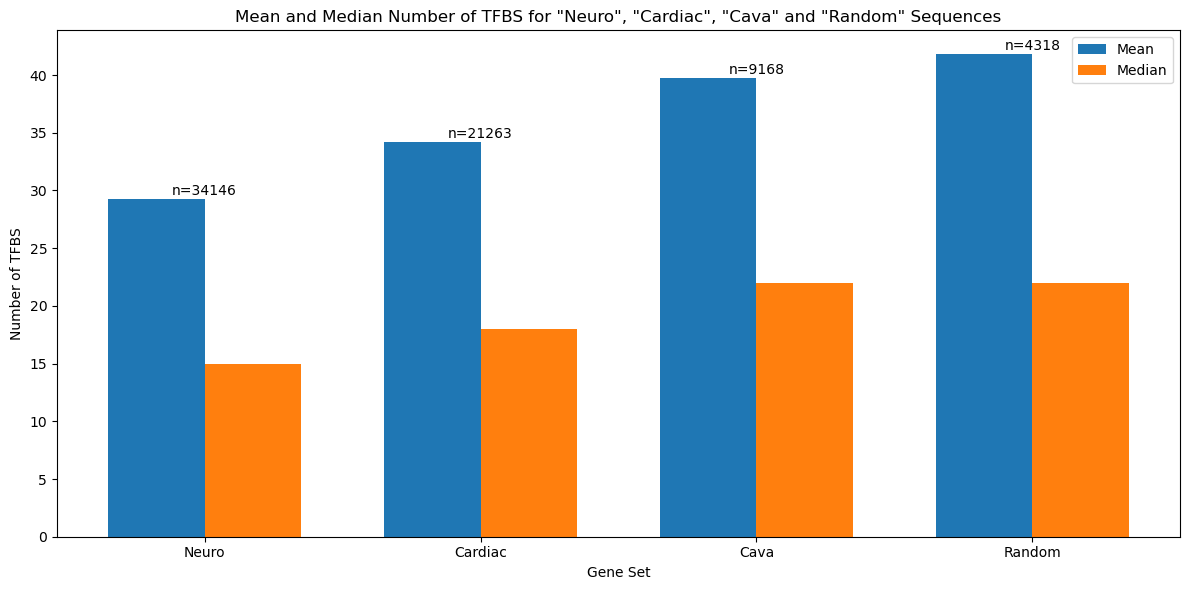

In [40]:
plot_gene_set_for_all_sequences(tested_cre_activity_remap_tfbs_occurences, group_list=['Neuro', 'Cardiac', 'Cava', 'Random'], column_to_plot='number_of_TFBS', x_label='Gene Set', y_label='Number of TFBS', title='Mean and Median Number of TFBS for "Neuro", "Cardiac", "Cava" and "Random" Sequences')

Summary Statistics with Group Sizes:
  Gene_Set       Mean  Median  Count
0    Neuro  34.442872    17.0   1978
1  Cardiac  38.527962    20.0   1055
2     Cava  54.349206    32.0    441
3   Random  55.155932    36.0    295


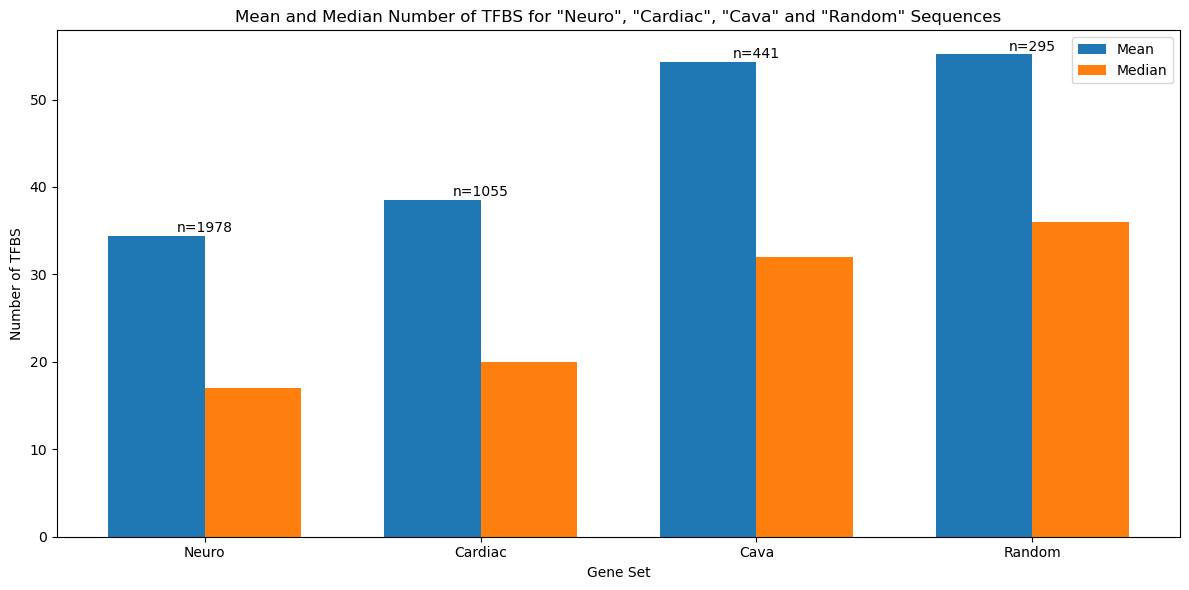

In [41]:
# only for the sequences which show significant activity:

tested_cre_activity_remap_tfbs_occurences_significant = tested_cre_activity_remap_tfbs_occurences[
    tested_cre_activity_remap_tfbs_occurences['bcalm_element_adjusted_p_value'] < significance_threshold
]
plot_gene_set_for_all_sequences(tested_cre_activity_remap_tfbs_occurences_significant, group_list=['Neuro', 'Cardiac', 'Cava', 'Random'], column_to_plot='number_of_TFBS', x_label='Gene Set', y_label='Number of TFBS', title='Mean and Median Number of TFBS for "Neuro", "Cardiac", "Cava" and "Random" Sequences')

Summary Statistics with Group Sizes:
  Gene_Set       Mean  Median  Count
0    Neuro  23.635181    13.0  15457
1  Cardiac  25.697396    14.0   7756
2     Cava  26.359251    15.0   1762
3   Random  26.199088    14.0    658


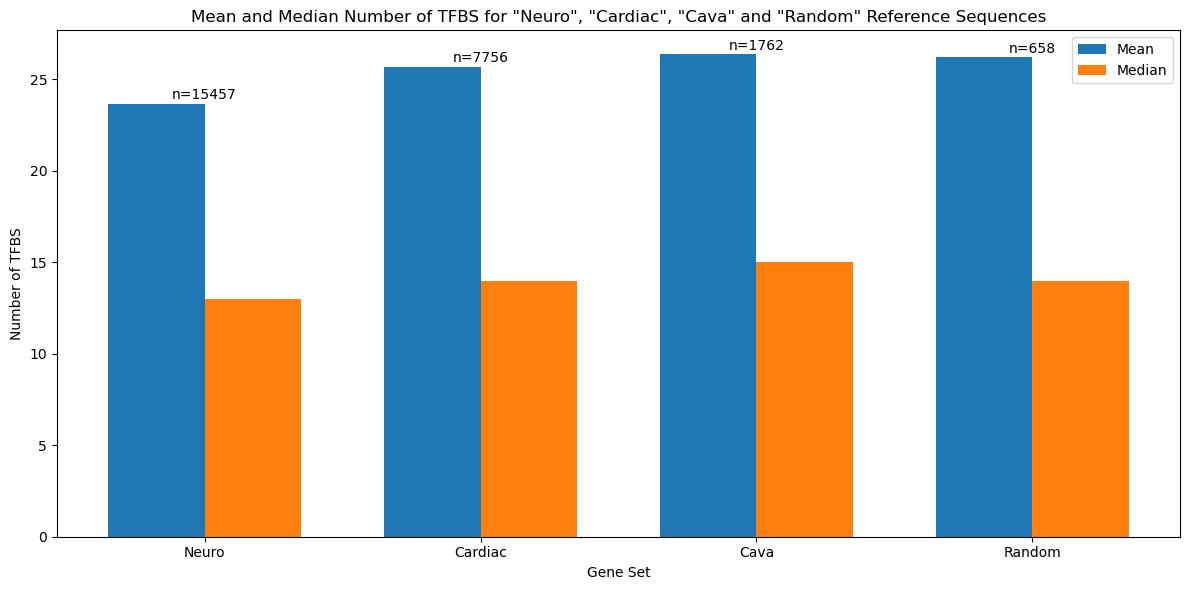

In [42]:
plot_gene_set_for_all_sequences(REF_tested_cre_activity_remap_tfbs_occurences, group_list=['Neuro', 'Cardiac', 'Cava', 'Random'], column_to_plot='number_of_TFBS', x_label='Gene Set', y_label='Number of TFBS', title='Mean and Median Number of TFBS for "Neuro", "Cardiac", "Cava" and "Random" Reference Sequences')

In [43]:
tested_cre_activity_remap_tfbs_occurences

,chrom,start,end,name,strand,TFBS_list,number_of_TFBS,n_unique_TFBS,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,bcalm_data_exists,gene_name,gene_set,SCREEN_ID,is_NPC_SCREEN_cCRE,is_H9_SCREEN_cCRE,is_H1_SCREEN_cCRE,is_neural_stem_SCREEN_cCRE,is_excitatory_neuron_SCREEN_cCRE
0,chr1,10588680,10588950,cardiac_neuro_cava_random:ALT_CASZ1|ENSG000001...,-,[MAFF],1,1,1.0,0.019942,True,CASZ1,[neuro],EH38E1318114,False,False,False,False,False
1,chr1,10588680,10588950,cardiac_neuro_cava_random:ALT_CASZ1|ENSG000001...,-,[MAFF],1,1,1.0,-0.016678,True,CASZ1,[neuro],EH38E1318114,False,False,False,False,False
2,chr1,10588680,10588950,cardiac_neuro_cava_random:REF_CASZ1|ENSG000001...,-,[MAFF],1,1,1.0,0.015284,True,CASZ1,[neuro],EH38E1318114,False,False,False,False,False
3,chr1,10594736,10595006,cardiac_neuro_cava_random:ALT_CASZ1|ENSG000001...,-,"[RBPJ, MEF2B, TFAP2C, SND1, ZNF263, POU5F1, SM...",24,24,1.0,0.023542,True,CASZ1,[neuro],EH38E1318122,False,True,False,False,False
4,chr1,10594736,10595006,cardiac_neuro_cava_random:REF_CASZ1|ENSG000001...,-,"[RBPJ, MEF2B, TFAP2C, SND1, ZNF263, POU5F1, SM...",24,24,1.0,0.018937,True,CASZ1,[neuro],EH38E1318122,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65560,chrX,77786807,77787077,cardiac_neuro_cava_random:ALT_ATRX|ENSG0000008...,-,"[ZSCAN4, FOXA1, RFX5, SPI1, ZBTB2, SPIB, KDM1A...",8,8,1.0,0.045921,True,ATRX,[neuro],EH38E2759274,False,False,False,False,False
65561,chrX,77786807,77787077,cardiac_neuro_cava_random:REF_ATRX|ENSG0000008...,-,"[ZSCAN4, FOXA1, RFX5, SPI1, ZBTB2, SPIB, KDM1A...",8,8,1.0,0.035090,True,ATRX,[neuro],EH38E2759274,False,False,False,False,False
65562,chrX,77787587,77787857,cardiac_neuro_cava_random:ATRX|ENSG00000085224...,-,"[BRD4, ZGPAT, HAND2, PHOX2B, ZBED4, TEAD4, SRE...",9,9,1.0,-0.010949,True,ATRX,[neuro],EH38E2759276,False,False,False,False,False
65563,chrX,77788137,77788407,cardiac_neuro_cava_random:ATRX|ENSG00000085224...,-,"[LIN54, SREBP2, MYBL2, FOXA2, ZNF24, KLF4, NFY...",45,45,1.0,-0.031196,True,ATRX,[neuro],EH38E3938017,False,False,False,False,False


In [44]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_gene_set_for_all_vs_significant(df, group_list,
                                         column_to_plot,
                                         significant_column='bcalm_element_adjusted_p_value',
                                         significance_threshold=0.1,
                                         gene_set_column='gene_set',
                                         x_label='Gene Set', y_label='Number of TFBS',
                                         title='Mean and Median Number of TFBS for "Neuro", "Cardiac", and "Random" Sequences',
                                         use_median=False,
                                         legend_location="best"):
    """
    Plots the mean and median of a specified column for a list of gene sets.

    Args:
        df (pd.DataFrame): The input DataFrame.
        group_list (list): A list of gene set names (strings) to be plotted.
        column_to_plot (str): The name of the column to plot (e.g., 'number_of_TFBS').
        x_label (str): The label for the x-axis.
        y_label (str): The label for the y-axis.
        title (str): The title of the plot.
    """
    group_result = []
    for group in group_list:
        # Filter sequences for each gene set
        group_sequences = df[
            df[gene_set_column].apply(lambda x: group.lower() in x)
        ]

        significant_group_sequences = group_sequences[group_sequences[significant_column] < significance_threshold]

        # Calculate mean, median, and count for all three groups
        all_group = group_sequences[column_to_plot].mean()
        sig_group = significant_group_sequences[column_to_plot].mean()
        if use_median:
            all_group = group_sequences[column_to_plot].median()
            sig_group = significant_group_sequences[column_to_plot].median()
        count_group = len(group_sequences)

        group_result.append({
            'Gene_Set': group,
            'All': all_group,
            'Significant': sig_group,
            'All_Count': count_group,
            'Significant_Count': len(significant_group_sequences)
        })


    # Create a DataFrame for plotting
    plot_data = pd.DataFrame(group_result)

    print("Summary Statistics with Group Sizes:")
    print(plot_data)

    # Plotting the data
    fig, ax = plt.subplots(figsize=(12, 6))

    bar_width = 0.35
    index = range(len(group_list))

    ax.bar(index, plot_data['All'], bar_width, label='All')
    ax.bar([i + bar_width for i in index], plot_data['Significant'], bar_width, label='Significantly Active')

    # Add group sizes as text labels
    for i, row in plot_data.iterrows():
        ax.text(index[i], row['All'] + 0.1, f'n={row["All_Count"]}', ha='center', va='bottom', fontsize=10)
        ax.text(index[i], row['All'] - 5, f'{round(row["All"],1)}', ha='center', va='bottom', fontsize=10)
        ax.text(index[i] + bar_width, row['Significant'] + 0.1, f'n={row["Significant_Count"]}', ha='center', va='bottom', fontsize=10)
        ax.text(index[i] + bar_width, row['Significant'] - 5, f'{round(row["Significant"],1)}', ha='center', va='bottom', fontsize=10)

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title + f" (sig. level: {significance_threshold})")
    ax.set_xticks([i + bar_width / 2 for i in index])
    ax.set_xticklabels(plot_data['Gene_Set'])
    ax.legend(loc=legend_location)

    plt.tight_layout()
    plt.show()

Summary Statistics with Group Sizes:
  Gene_Set        All  Significant  All_Count  Significant_Count
0    Neuro  29.284338    33.639410      34146               2238
1  Cardiac  34.208672    38.204098      21263               1220
2     Cava  39.732112    52.312016       9168                516
3   Random  41.784623    54.753943       4318                317


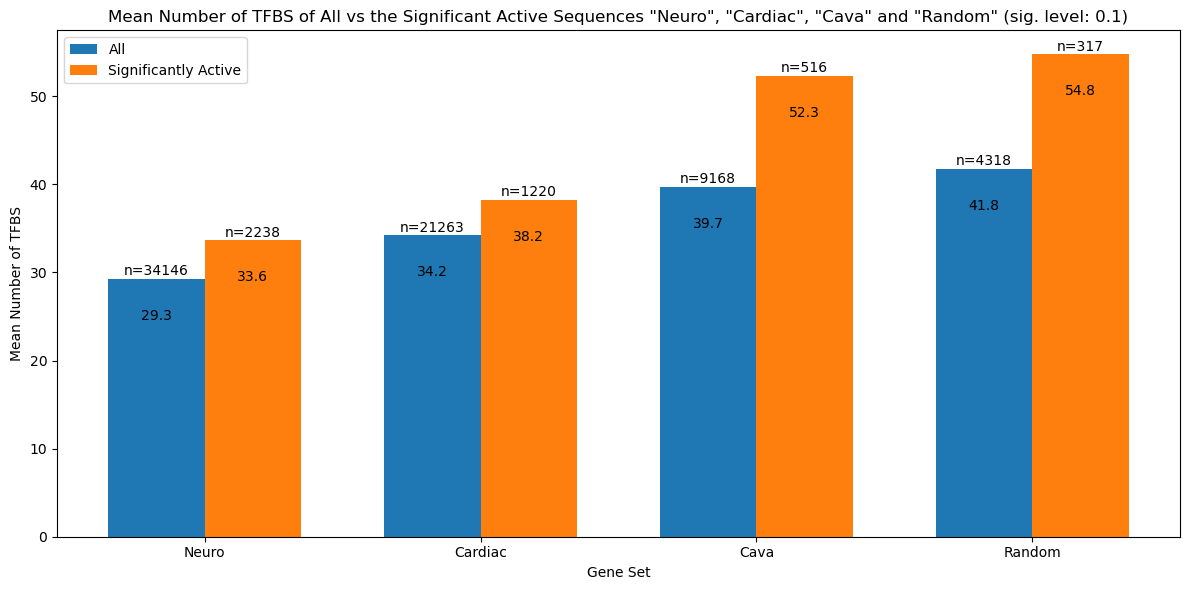

In [45]:
plot_gene_set_for_all_vs_significant(tested_cre_activity_remap_tfbs_occurences, group_list=['Neuro', 'Cardiac', 'Cava', 'Random'], significant_column='bcalm_element_adjusted_p_value', significance_threshold=0.1, column_to_plot='number_of_TFBS', x_label='Gene Set', y_label='Mean Number of TFBS', title='Mean Number of TFBS of All vs the Significant Active Sequences "Neuro", "Cardiac", "Cava" and "Random"')

In [46]:
tested_cre_activity_remap_tfbs_occurences

,chrom,start,end,name,strand,TFBS_list,number_of_TFBS,n_unique_TFBS,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,bcalm_data_exists,gene_name,gene_set,SCREEN_ID,is_NPC_SCREEN_cCRE,is_H9_SCREEN_cCRE,is_H1_SCREEN_cCRE,is_neural_stem_SCREEN_cCRE,is_excitatory_neuron_SCREEN_cCRE
0,chr1,10588680,10588950,cardiac_neuro_cava_random:ALT_CASZ1|ENSG000001...,-,[MAFF],1,1,1.0,0.019942,True,CASZ1,[neuro],EH38E1318114,False,False,False,False,False
1,chr1,10588680,10588950,cardiac_neuro_cava_random:ALT_CASZ1|ENSG000001...,-,[MAFF],1,1,1.0,-0.016678,True,CASZ1,[neuro],EH38E1318114,False,False,False,False,False
2,chr1,10588680,10588950,cardiac_neuro_cava_random:REF_CASZ1|ENSG000001...,-,[MAFF],1,1,1.0,0.015284,True,CASZ1,[neuro],EH38E1318114,False,False,False,False,False
3,chr1,10594736,10595006,cardiac_neuro_cava_random:ALT_CASZ1|ENSG000001...,-,"[RBPJ, MEF2B, TFAP2C, SND1, ZNF263, POU5F1, SM...",24,24,1.0,0.023542,True,CASZ1,[neuro],EH38E1318122,False,True,False,False,False
4,chr1,10594736,10595006,cardiac_neuro_cava_random:REF_CASZ1|ENSG000001...,-,"[RBPJ, MEF2B, TFAP2C, SND1, ZNF263, POU5F1, SM...",24,24,1.0,0.018937,True,CASZ1,[neuro],EH38E1318122,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65560,chrX,77786807,77787077,cardiac_neuro_cava_random:ALT_ATRX|ENSG0000008...,-,"[ZSCAN4, FOXA1, RFX5, SPI1, ZBTB2, SPIB, KDM1A...",8,8,1.0,0.045921,True,ATRX,[neuro],EH38E2759274,False,False,False,False,False
65561,chrX,77786807,77787077,cardiac_neuro_cava_random:REF_ATRX|ENSG0000008...,-,"[ZSCAN4, FOXA1, RFX5, SPI1, ZBTB2, SPIB, KDM1A...",8,8,1.0,0.035090,True,ATRX,[neuro],EH38E2759274,False,False,False,False,False
65562,chrX,77787587,77787857,cardiac_neuro_cava_random:ATRX|ENSG00000085224...,-,"[BRD4, ZGPAT, HAND2, PHOX2B, ZBED4, TEAD4, SRE...",9,9,1.0,-0.010949,True,ATRX,[neuro],EH38E2759276,False,False,False,False,False
65563,chrX,77788137,77788407,cardiac_neuro_cava_random:ATRX|ENSG00000085224...,-,"[LIN54, SREBP2, MYBL2, FOXA2, ZNF24, KLF4, NFY...",45,45,1.0,-0.031196,True,ATRX,[neuro],EH38E3938017,False,False,False,False,False


Summary Statistics with Group Sizes:
  Gene_Set        All  Significant  All_Count  Significant_Count
0    Neuro  23.635181    27.777257      15457                853
1  Cardiac  25.697396    28.553806       7756                381
2     Cava  26.359251    35.468354       1762                 79
3   Random  26.199088    33.095238        658                 42


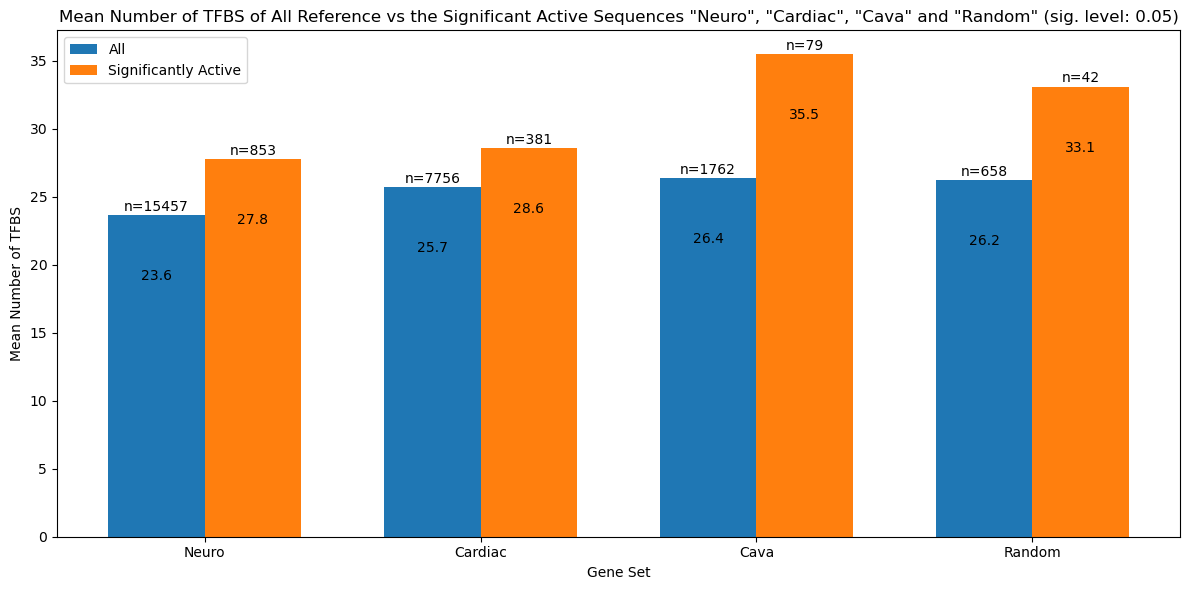

In [47]:
plot_gene_set_for_all_vs_significant(REF_tested_cre_activity_remap_tfbs_occurences, group_list=['Neuro', 'Cardiac', 'Cava', 'Random'], significant_column='bcalm_element_adjusted_p_value', significance_threshold=significance_threshold, column_to_plot='number_of_TFBS', x_label='Gene Set', y_label='Mean Number of TFBS', title='Mean Number of TFBS of All Reference vs the Significant Active Sequences "Neuro", "Cardiac", "Cava" and "Random"', legend_location="upper left")


In [48]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
def correlation_of_tfbs_number_vs_mpra_activity(cre_activity_tfbs_df, groups_to_plot=['neuro', 'cardiac', 'cava', 'random'], title=""):
    # Define the groups to analyze
    fig, axes = plt.subplots(1, len(groups_to_plot), figsize=(18, 6), sharey=True)

    for i, group in enumerate(groups_to_plot):
        # Filter the dataframe for the current group and where activity data exists
        df_group = cre_activity_tfbs_df[
            cre_activity_tfbs_df['gene_set'].apply(lambda x: group in x) &
            (cre_activity_tfbs_df['bcalm_data_exists'] == True)
        ]

        ax = axes[i]

        if len(df_group) < 2:
            ax.set_title(f"Not enough data for '{group.capitalize()}'")
            ax.set_xlabel('Number of TFBS')
            ax.set_ylabel('Activity logFC')
            continue

        # Calculate both Pearson and Spearman correlation coefficients
        pearson_corr, pearson_p = pearsonr(df_group['number_of_TFBS'], df_group['bcalm_element_log_ratio_activity'])
        spearman_corr, spearman_p = spearmanr(df_group['number_of_TFBS'], df_group['bcalm_element_log_ratio_activity'])

        # Create a scatter plot
        ax.scatter(df_group['number_of_TFBS'], df_group['bcalm_element_log_ratio_activity'])

        ax.set_xlabel('Number of TFBS')
        ax.set_title(
            f'{group.capitalize()} (n: {len(df_group)}) (Pearson r={pearson_corr:.2f}, p={pearson_p:.3f})\n'
            f'(Spearman r={spearman_corr:.2f}, p={spearman_p:.3f})'
        )
        ax.grid(True)

    # Set a common y-axis label for the entire figure
    axes[0].set_ylabel('Activity logFC')
    # figure title:
    fig.suptitle(title)

    plt.tight_layout()
    plt.show()

In [49]:
tested_cre_activity_remap_tfbs_occurences_significant_more_active = tested_cre_activity_remap_tfbs_occurences_significant[
    tested_cre_activity_remap_tfbs_occurences_significant['bcalm_element_log_ratio_activity'] > 0
]
tested_cre_activity_remap_tfbs_occurences_significant_less_active = tested_cre_activity_remap_tfbs_occurences_significant[
    tested_cre_activity_remap_tfbs_occurences_significant['bcalm_element_log_ratio_activity'] < 0
]

REF_tested_cre_activity_remap_tfbs_occurences_significant = REF_tested_cre_activity_remap_tfbs_occurences.loc[REF_tested_cre_activity_remap_tfbs_occurences['bcalm_element_adjusted_p_value'] < significance_threshold].copy()
REF_tested_cre_activity_remap_tfbs_occurences_significant_more_active = REF_tested_cre_activity_remap_tfbs_occurences_significant[
    REF_tested_cre_activity_remap_tfbs_occurences_significant['bcalm_element_log_ratio_activity'] > 0
]
REF_tested_cre_activity_remap_tfbs_occurences_significant_less_active = REF_tested_cre_activity_remap_tfbs_occurences_significant[
    REF_tested_cre_activity_remap_tfbs_occurences_significant['bcalm_element_log_ratio_activity'] < 0
]

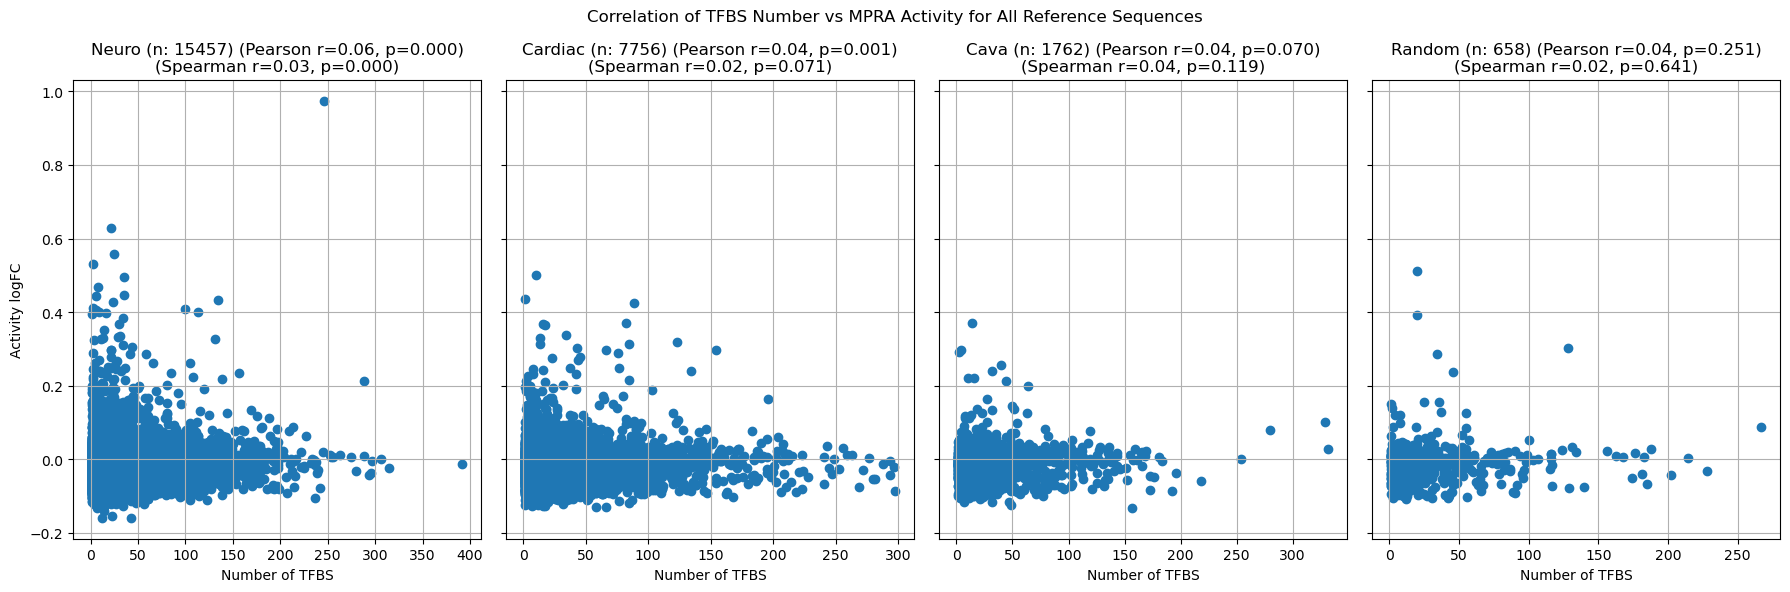

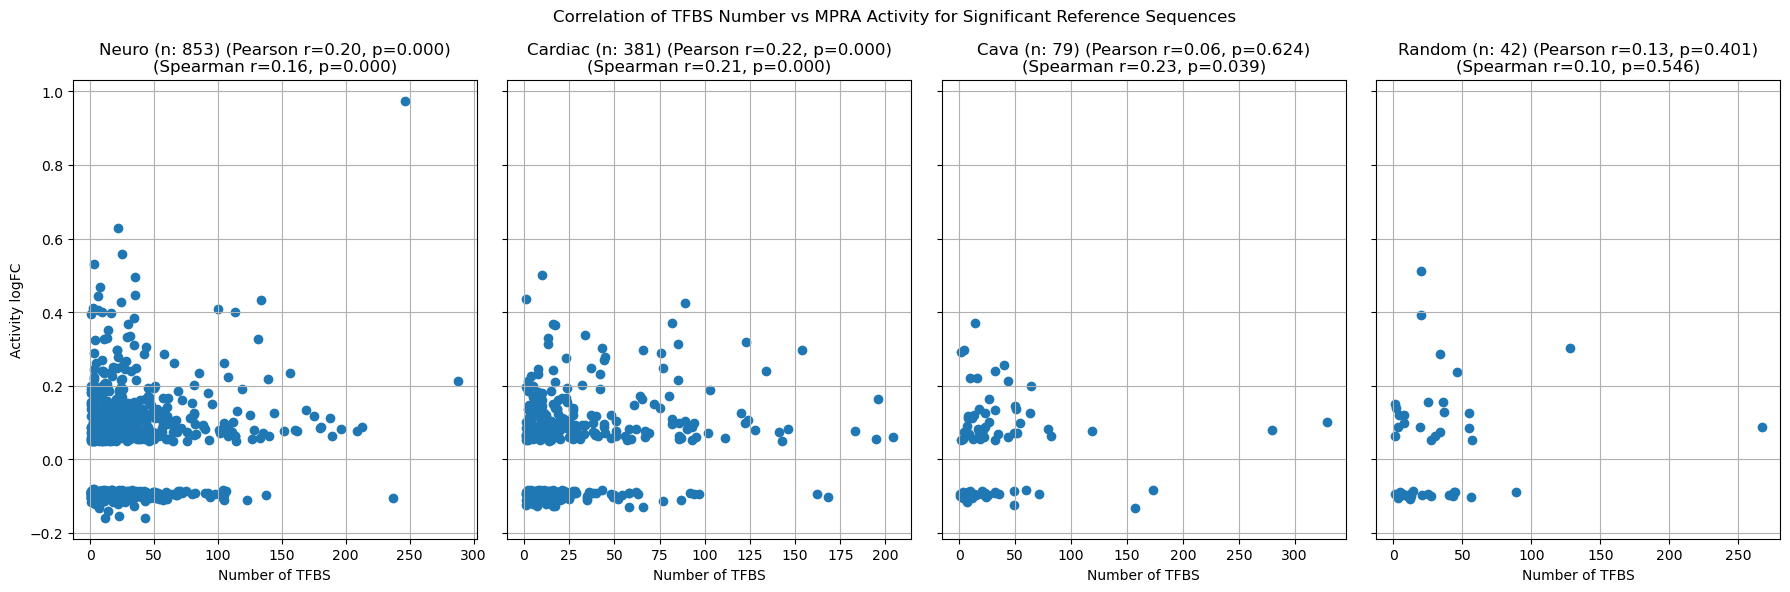

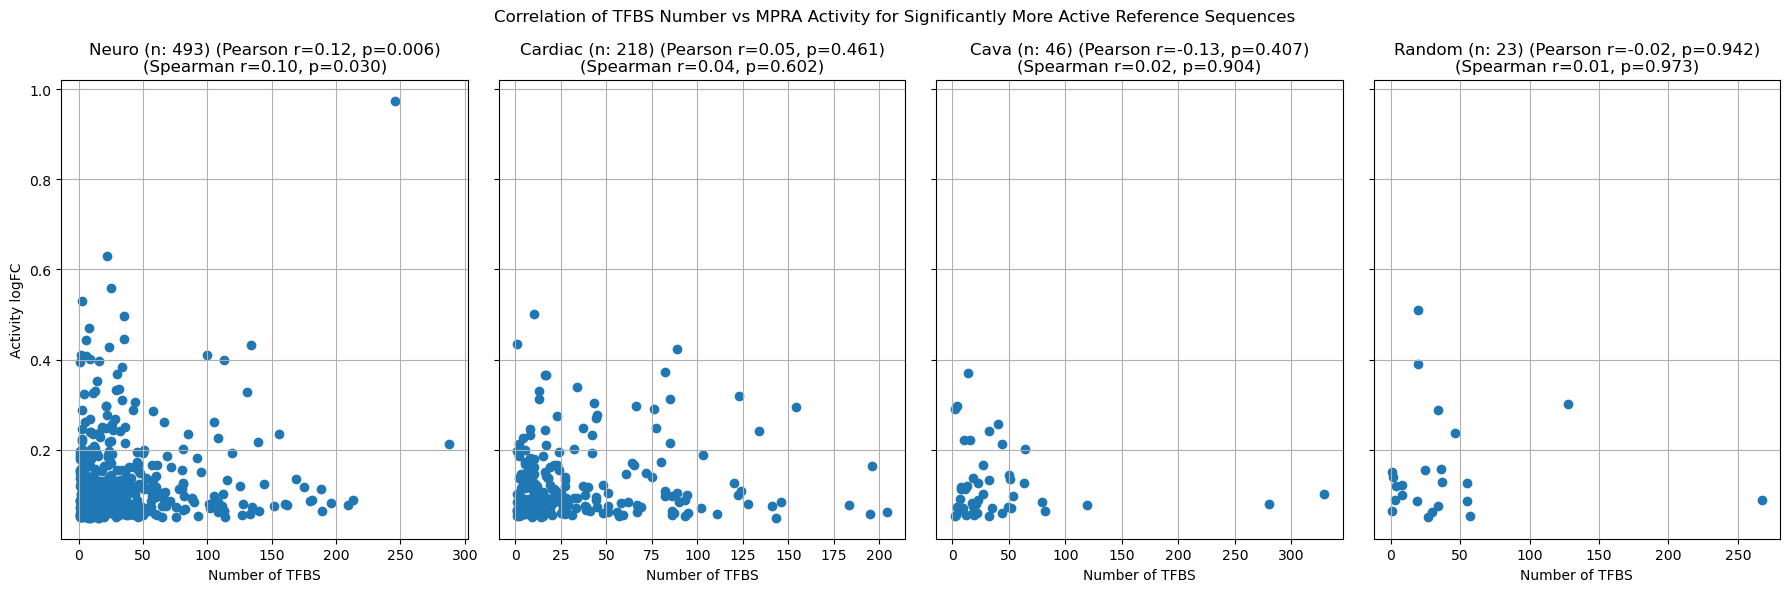

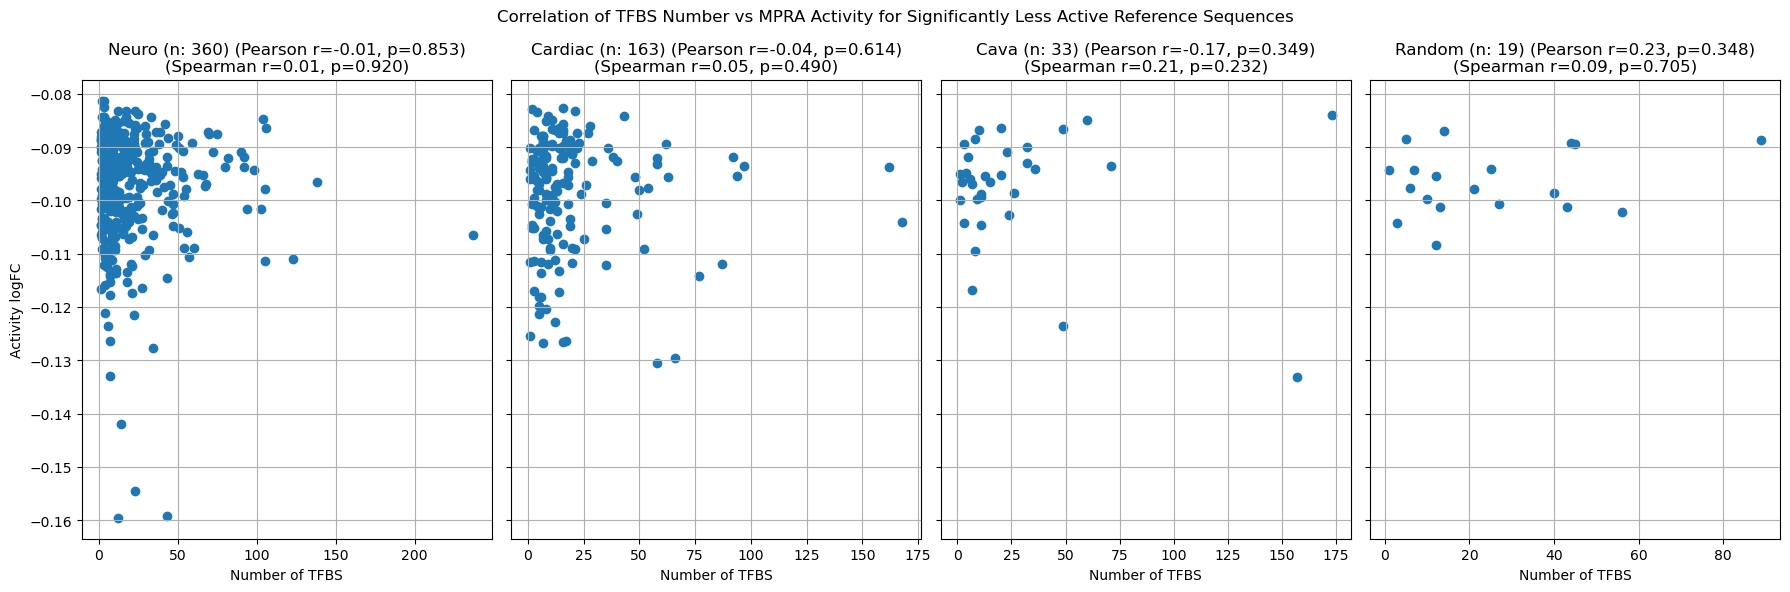

In [50]:
correlation_of_tfbs_number_vs_mpra_activity(REF_tested_cre_activity_remap_tfbs_occurences, title="Correlation of TFBS Number vs MPRA Activity for All Reference Sequences")
correlation_of_tfbs_number_vs_mpra_activity(REF_tested_cre_activity_remap_tfbs_occurences_significant, title="Correlation of TFBS Number vs MPRA Activity for Significant Reference Sequences")
correlation_of_tfbs_number_vs_mpra_activity(REF_tested_cre_activity_remap_tfbs_occurences_significant_more_active, title="Correlation of TFBS Number vs MPRA Activity for Significantly More Active Reference Sequences")
correlation_of_tfbs_number_vs_mpra_activity(REF_tested_cre_activity_remap_tfbs_occurences_significant_less_active, title="Correlation of TFBS Number vs MPRA Activity for Significantly Less Active Reference Sequences")

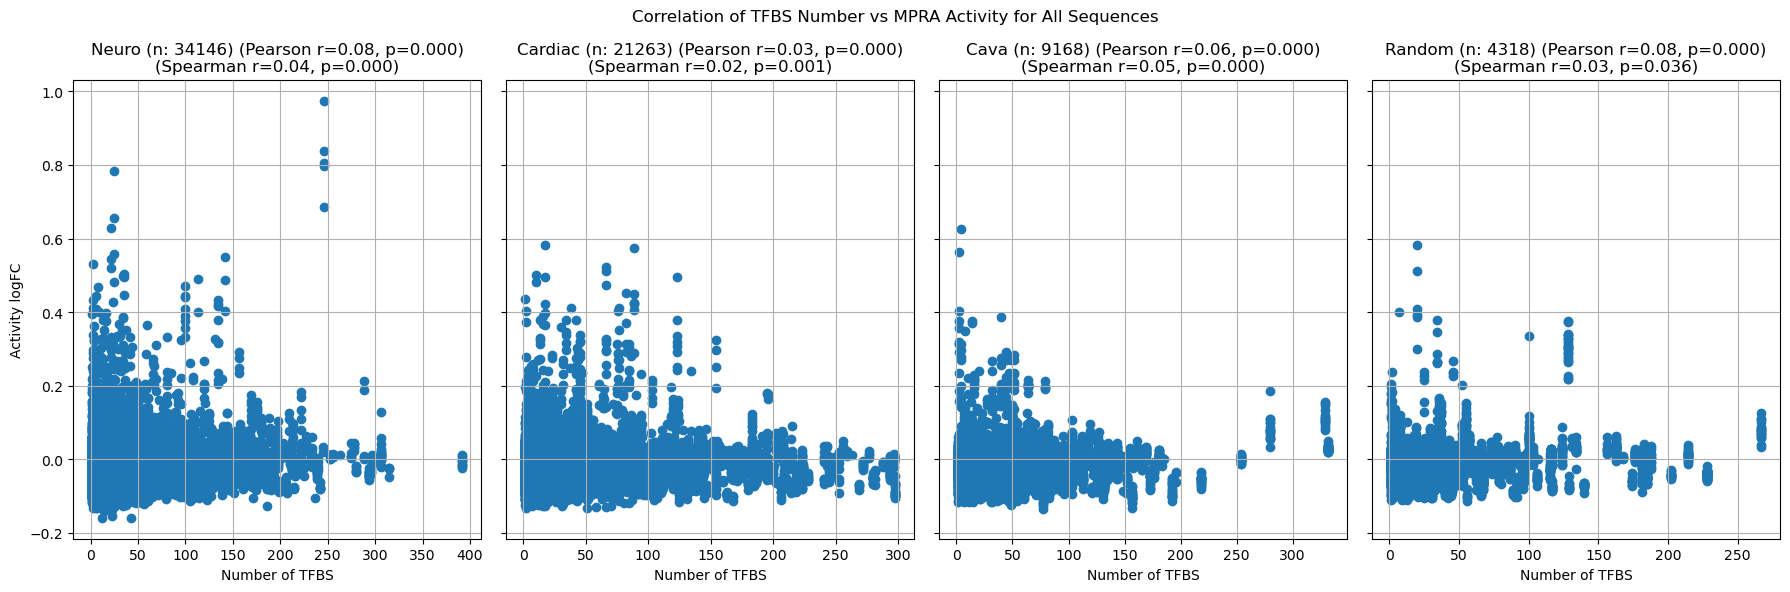

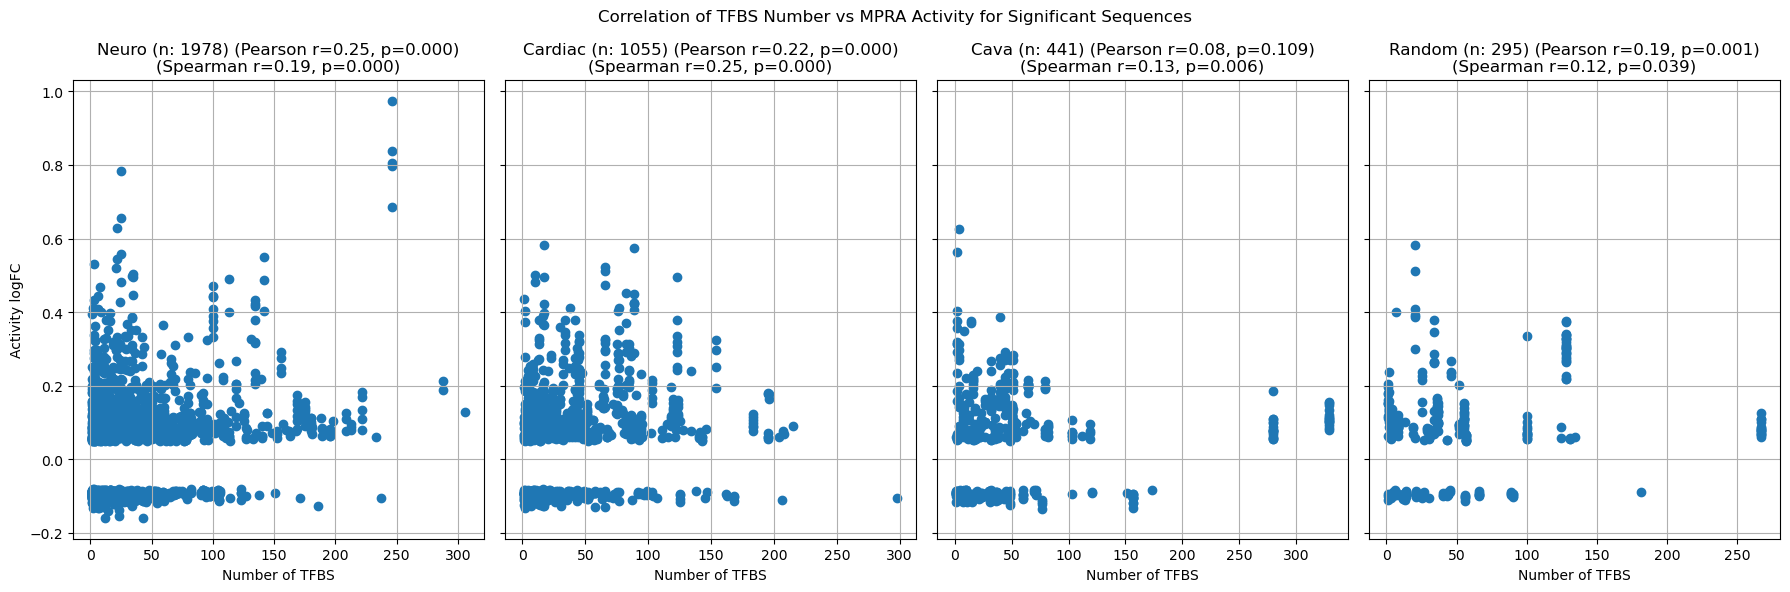

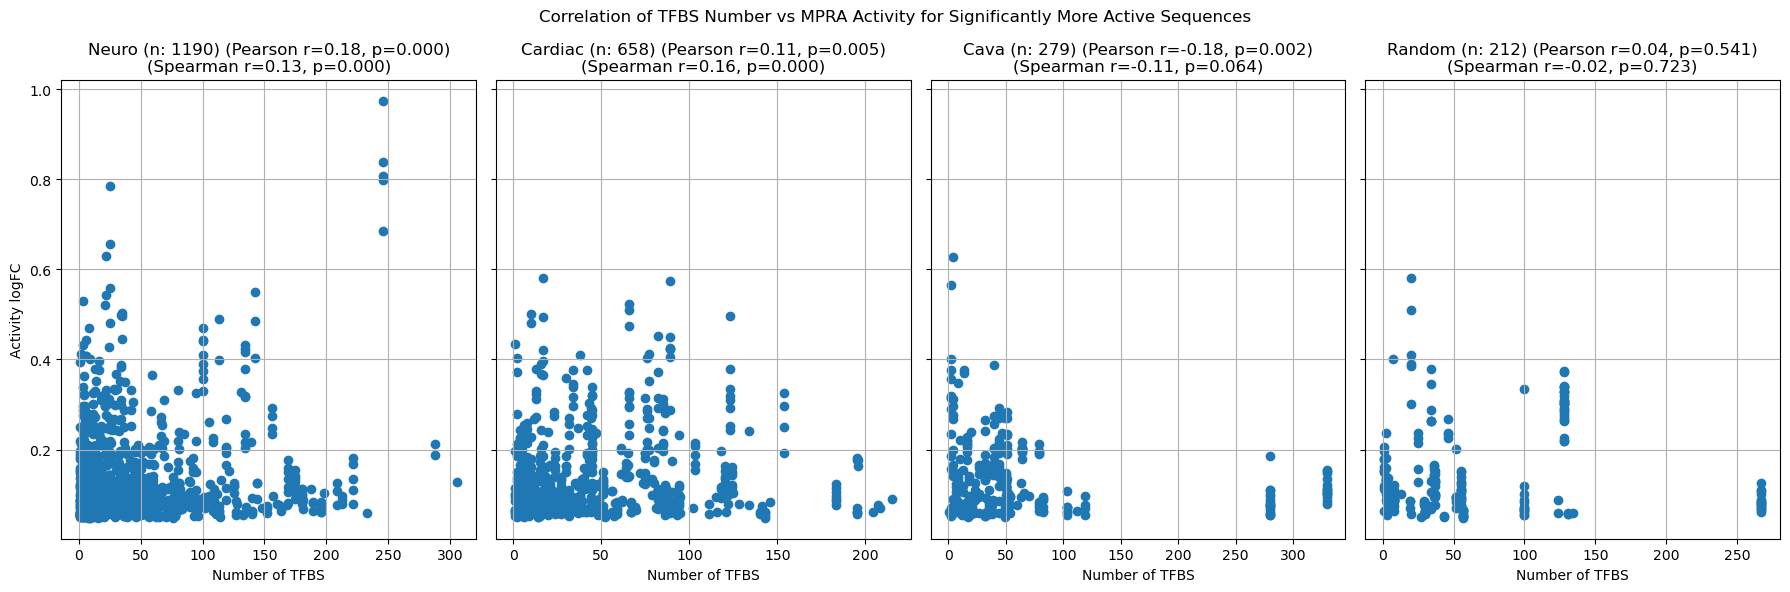

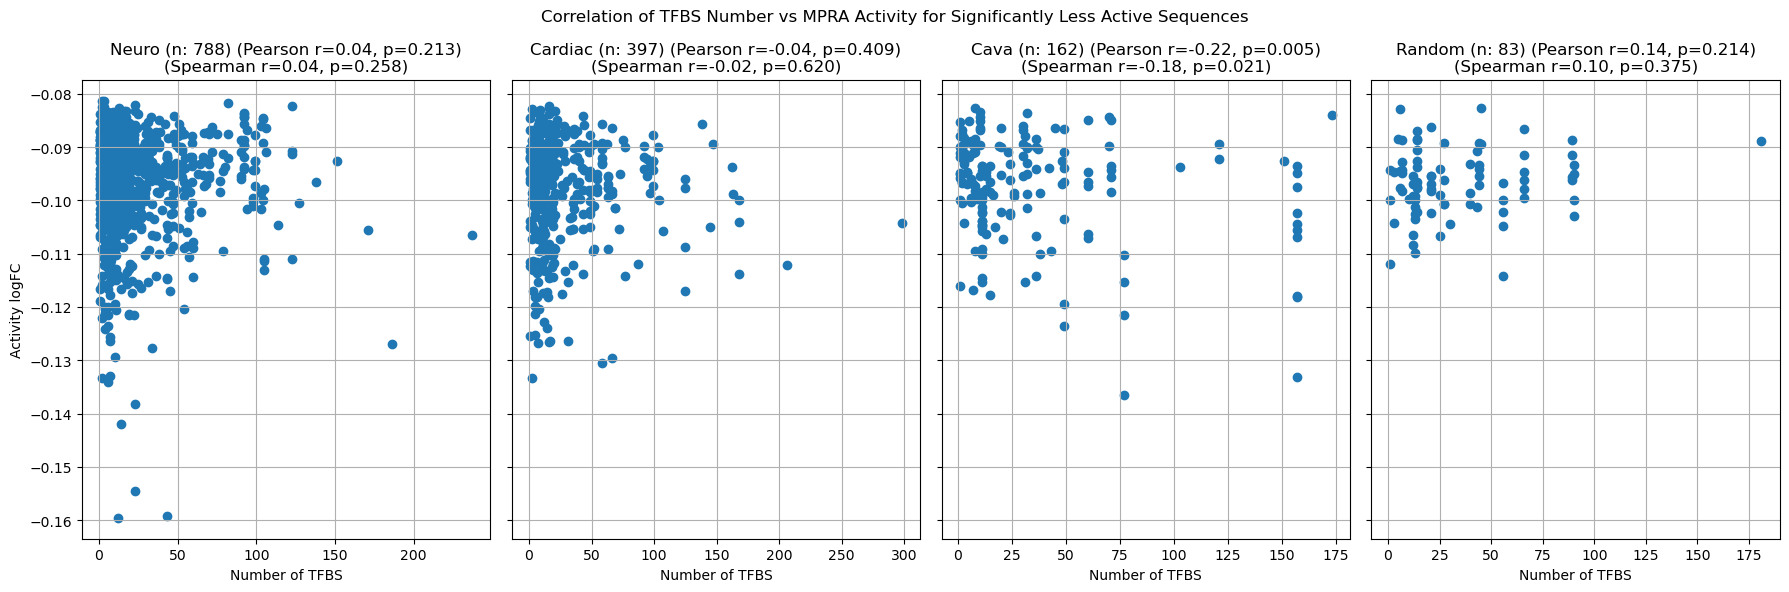

In [51]:
correlation_of_tfbs_number_vs_mpra_activity(tested_cre_activity_remap_tfbs_occurences, title="Correlation of TFBS Number vs MPRA Activity for All Sequences")
correlation_of_tfbs_number_vs_mpra_activity(tested_cre_activity_remap_tfbs_occurences_significant, title="Correlation of TFBS Number vs MPRA Activity for Significant Sequences")
correlation_of_tfbs_number_vs_mpra_activity(tested_cre_activity_remap_tfbs_occurences_significant_more_active, title="Correlation of TFBS Number vs MPRA Activity for Significantly More Active Sequences")
correlation_of_tfbs_number_vs_mpra_activity(tested_cre_activity_remap_tfbs_occurences_significant_less_active, title="Correlation of TFBS Number vs MPRA Activity for Significantly Less Active Sequences")

#### Plot the unique number of TFBS


In [52]:
tested_cre_activity_remap_tfbs_occurences.columns

Index(['chrom', 'start', 'end', 'name', 'strand', 'TFBS_list',
       'number_of_TFBS', 'n_unique_TFBS', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'gene_name',
       'gene_set', 'SCREEN_ID', 'is_NPC_SCREEN_cCRE', 'is_H9_SCREEN_cCRE',
       'is_H1_SCREEN_cCRE', 'is_neural_stem_SCREEN_cCRE',
       'is_excitatory_neuron_SCREEN_cCRE'],
      dtype='object')

##### Median

Summary Statistics with Group Sizes:
  Gene_Set   All  Significant  All_Count  Significant_Count
0    Neuro  13.0         15.0      15457                853
1  Cardiac  14.0         14.0       7756                381
2     Cava  15.0         19.0       1762                 79
3   Random  14.0         22.5        658                 42


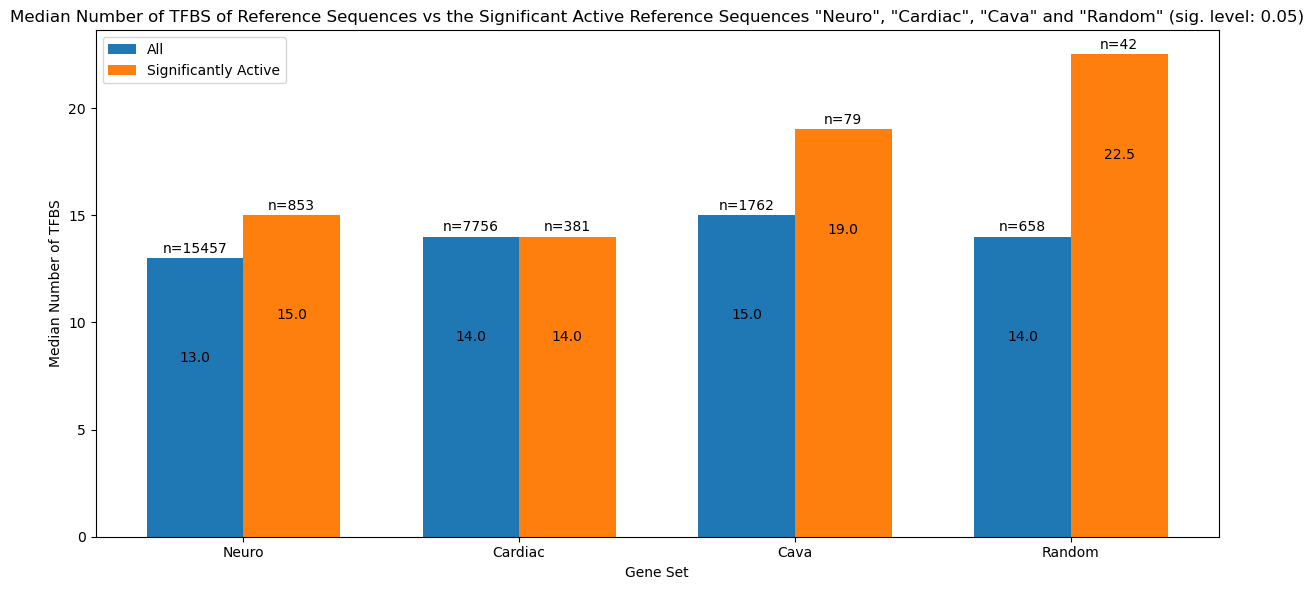

Summary Statistics with Group Sizes:
  Gene_Set   All  Significant  All_Count  Significant_Count
0    Neuro  15.0         17.0      34146               1978
1  Cardiac  18.0         20.0      21263               1055
2     Cava  22.0         32.0       9168                441
3   Random  22.0         35.0       4318                295


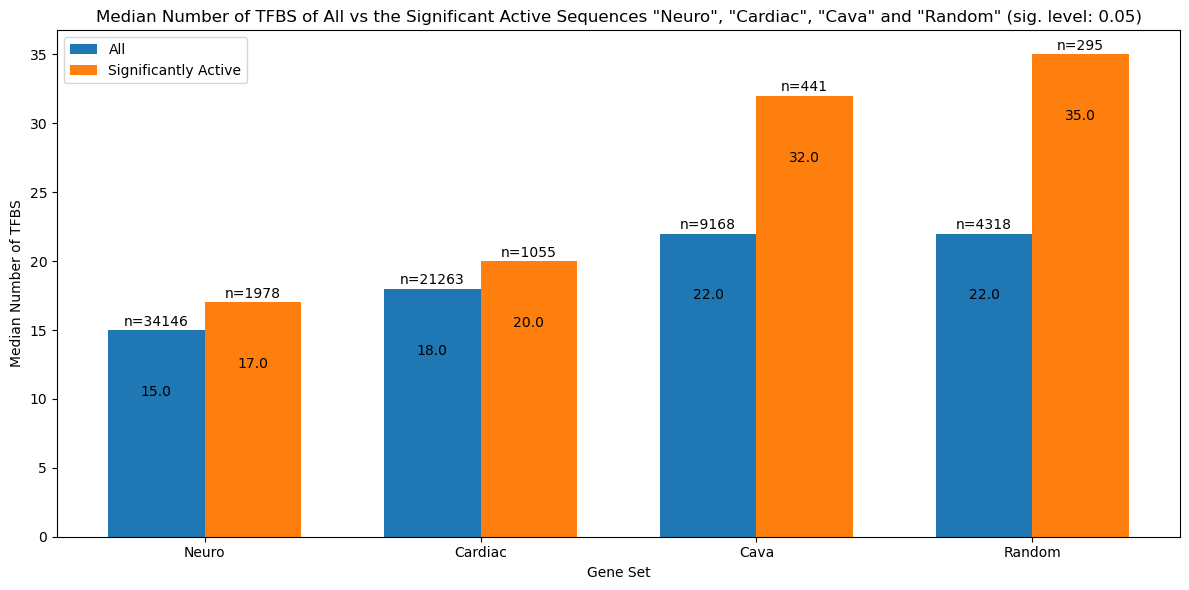

In [53]:
plot_gene_set_for_all_vs_significant(REF_tested_cre_activity_remap_tfbs_occurences, group_list=['Neuro', 'Cardiac', 'Cava', 'Random'], significant_column='bcalm_element_adjusted_p_value', significance_threshold=significance_threshold, column_to_plot='n_unique_TFBS', x_label='Gene Set', y_label='Median Number of TFBS', title='Median Number of TFBS of Reference Sequences vs the Significant Active Reference Sequences "Neuro", "Cardiac", "Cava" and "Random"', legend_location="upper left", use_median=True)
plot_gene_set_for_all_vs_significant(tested_cre_activity_remap_tfbs_occurences, group_list=['Neuro', 'Cardiac', 'Cava', 'Random'], significant_column='bcalm_element_adjusted_p_value', significance_threshold=significance_threshold, column_to_plot='n_unique_TFBS', x_label='Gene Set', y_label='Median Number of TFBS', title='Median Number of TFBS of All vs the Significant Active Sequences "Neuro", "Cardiac", "Cava" and "Random"', use_median=True)

##### Mean

Summary Statistics with Group Sizes:
  Gene_Set        All  Significant  All_Count  Significant_Count
0    Neuro  23.430485    27.540445      15457                853
1  Cardiac  25.464415    28.291339       7756                381
2     Cava  26.096481    35.164557       1762                 79
3   Random  25.972644    32.761905        658                 42


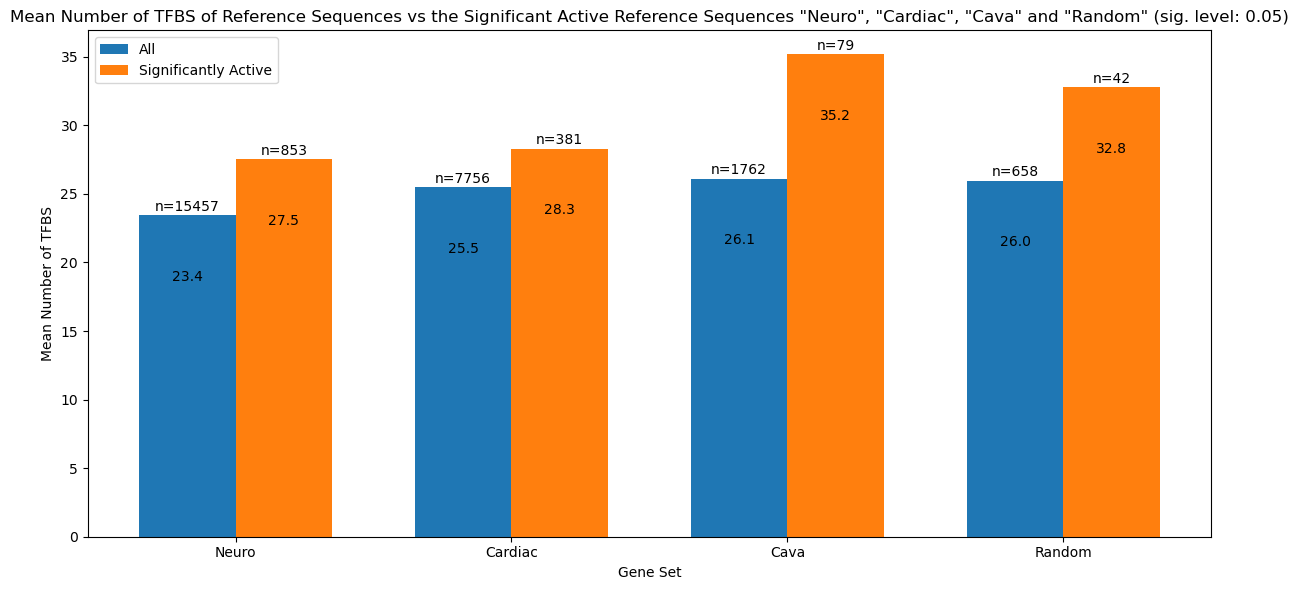

Summary Statistics with Group Sizes:
  Gene_Set        All  Significant  All_Count  Significant_Count
0    Neuro  29.021467    34.140040      34146               1978
1  Cardiac  33.889197    38.189573      21263               1055
2     Cava  39.302029    53.829932       9168                441
3   Random  41.354562    54.606780       4318                295


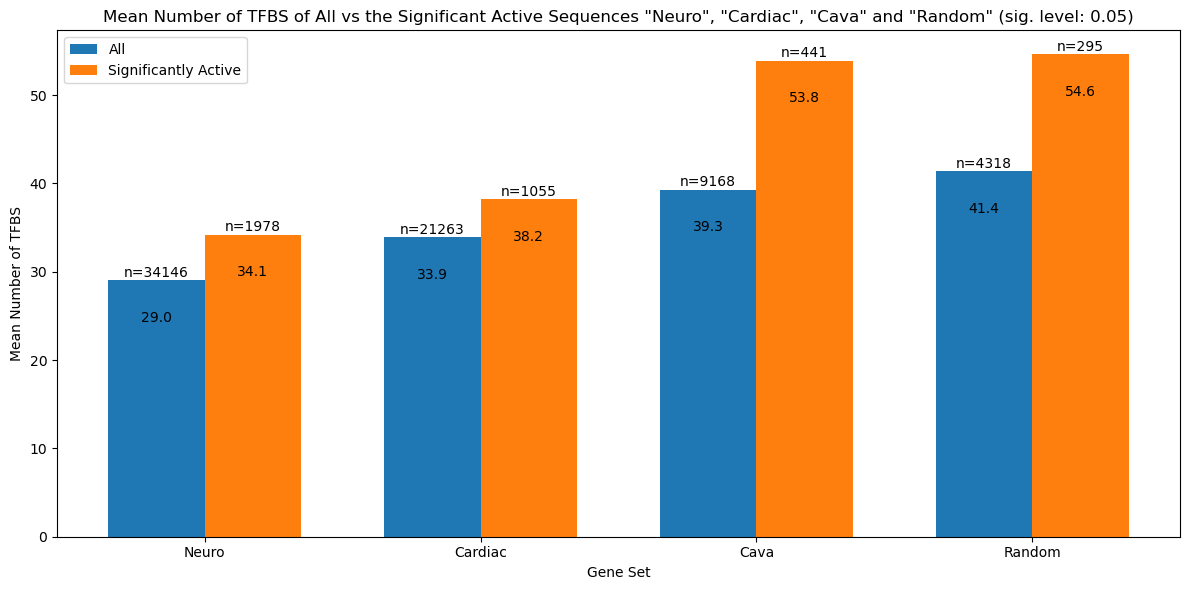

In [54]:
plot_gene_set_for_all_vs_significant(REF_tested_cre_activity_remap_tfbs_occurences, group_list=['Neuro', 'Cardiac', 'Cava', 'Random'], significant_column='bcalm_element_adjusted_p_value', significance_threshold=significance_threshold, column_to_plot='n_unique_TFBS', x_label='Gene Set', y_label='Mean Number of TFBS', title='Mean Number of TFBS of Reference Sequences vs the Significant Active Reference Sequences "Neuro", "Cardiac", "Cava" and "Random"', legend_location="upper left")
plot_gene_set_for_all_vs_significant(tested_cre_activity_remap_tfbs_occurences, group_list=['Neuro', 'Cardiac', 'Cava', 'Random'], significant_column='bcalm_element_adjusted_p_value', significance_threshold=significance_threshold, column_to_plot='n_unique_TFBS', x_label='Gene Set', y_label='Mean Number of TFBS', title='Mean Number of TFBS of All vs the Significant Active Sequences "Neuro", "Cardiac", "Cava" and "Random"')

In [118]:
# correctify the screen all CREs bed:
all_screen_cre_bed_path = "/home/kisa/coding/80K_MPRA/cCREs_overlap/GRCh38-cCREs.bed.gz"
all_screen_cre_bed = pd.read_csv(all_screen_cre_bed_path, sep="\t", header=None)
all_screen_cre_bed.columns = ['chrom', 'start', 'end', 'name', 'another_name', 'annotation']
all_screen_cre_bed

,chrom,start,end,name,another_name,annotation
0,chr1,10033,10250,EH38D4327497,EH38E2776516,pELS
1,chr1,10385,10713,EH38D4327498,EH38E2776517,pELS
2,chr1,16097,16381,EH38D6144701,EH38E3951272,CA-CTCF
3,chr1,17343,17642,EH38D6144702,EH38E3951273,CA-TF
4,chr1,29320,29517,EH38D6144703,EH38E3951274,CA
...,...,...,...,...,...,...
2348849,chrY,26670948,26671287,EH38D6144696,EH38E3951269,dELS
2348850,chrY,26671292,26671478,EH38D6144697,EH38E3951270,dELS
2348851,chrY,26671538,26671787,EH38D6473458,EH38E4535242,dELS
2348852,chrY,56684007,56684171,EH38D6144699,EH38E4535243,CA


In [120]:
all_screen_cre_bed['score'] = 0
all_screen_cre_bed['strand'] = '+'
output_path_all_screen_cre_bed = "/home/kisa/coding/80K_MPRA/cCREs_overlap/correctified_GRCh38-cCREs.bed.gz"
write_output=False
if write_output:
    all_screen_cre_bed[['chrom', 'start', 'end', 'name', 'score', 'strand']].to_csv(output_path_all_screen_cre_bed, sep="\t", header=False, index=False, compression='gzip')

# remove the chromosome prefix:
all_screen_cre_bed['chr'] = all_screen_cre_bed['chrom'].apply(lambda x: x.replace('chr', ''))
all_screen_cre_bed

output_path_all_screen_cre_bed_no_chr = "/home/kisa/coding/80K_MPRA/cCREs_overlap/all_SCREEN_GRCh38-cCREs_without_chr.bed.gz"
write_output=False
if write_output:
    all_screen_cre_bed[['chr', 'start', 'end', 'name', 'score', 'strand']].to_csv(output_path_all_screen_cre_bed_no_chr, sep="\t", header=False, index=False, compression='gzip')


In [116]:
all_screen_cre_bed.shape[0]

2348854

In [117]:
all_screen_cre_bed['name'].nunique()

2348854

### Species Constraint: PhastCons

#### For all SCREEN cCREs: 
```
scp kisa11_c@vpn-bihtransfer2:/data/cephfs-2/unmirrored/groups/kircher/users/kisa11_c/projects/phastCons_hg38_100way/all_SCREEN_CREs_phastCons100way.tab.gz /home/kisa/coding/80K_MPRA/remap_chipseq_pia/remap_cre_overlap/
```

´´´
zcat all_SCREE_CREs_remap2022_filtered_summit_overlap_no_border_overlap_min_10bp.bed.gz | 
    awk '{
        # Create a unique key from the first four columns
        key = $1 OFS $2 OFS $3 OFS $4;
        # Count the occurrences of each unique key
        count[key]++;
    }
    END {
        # Initialize a total count and a counter for unique groups
        total_rows = 0;
        unique_groups = 0;

        # Loop through the associative array
        for (key in count) {
            total_rows += count[key];
            unique_groups++;
        }
        
        # Check to prevent division by zero
        if (unique_groups > 0) {
            # Calculate and print the mean
            print total_rows / unique_groups;
        } else {
            print "No groups found to calculate the mean.";
        }
    }' 
```
- 23.4602

In [55]:
# Now read the phastCons score and correlate

In [56]:
phastCons_average_tab_path = "/home/kisa/coding/80K_MPRA/remap_chipseq_pia/remap_cre_overlap/all_tested_CRE_phastCons100way.tab.gz"
phastCons_tested_CRE_df = pd.read_csv(phastCons_average_tab_path, sep="\t", low_memory=False, header=None)
phastCons_tested_CRE_df.columns = ['name', 'seq_size', 'covered_size', 'sum', 'mean0', 'mean']
phastCons_tested_CRE_df

,name,seq_size,covered_size,sum,mean0,mean
0,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,270,270,2.747,0.010174,0.010174
1,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,270,270,2.747,0.010174,0.010174
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,270,270,2.745,0.010167,0.010167
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,270,270,36.192,0.134044,0.134044
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,270,270,90.157,0.333915,0.333915
...,...,...,...,...,...,...
68236,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,270,270,8.954,0.033163,0.033163
68237,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,270,270,47.159,0.174663,0.174663
68238,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,270,270,47.159,0.174663,0.174663
68239,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,270,270,47.159,0.174663,0.174663


In [136]:
print(f"Number of sequences which are not entirely covered: {(phastCons_tested_CRE_df['covered_size'] != 270).sum()}")
print(f"Proportion of sequences which are not entirely covered: {(phastCons_tested_CRE_df['covered_size'] != phastCons_tested_CRE_df['seq_size']).sum()/phastCons_tested_CRE_df.shape[0]}")



Number of sequences which are not entirely covered: 127
Proportion of sequences which are not entirely covered: 0.001861051274160695


In [58]:
not_entirely_covered_sequences = phastCons_tested_CRE_df.loc[phastCons_tested_CRE_df["covered_size"] != 270].copy()
not_entirely_covered_sequences

,name,seq_size,covered_size,sum,mean0,mean
2308,cardiac_neuro_cava_random:ALT_ECE1|ENSG0000011...,270,0,0.000,0.000000,0.000000
2309,cardiac_neuro_cava_random:REF_ECE1|ENSG0000011...,270,0,0.000,0.000000,0.000000
2310,cardiac_neuro_cava_random:ALT_ECE1|ENSG0000011...,270,0,0.000,0.000000,0.000000
2311,cardiac_neuro_cava_random:ALT_ECE1|ENSG0000011...,270,0,0.000,0.000000,0.000000
2312,cardiac_neuro_cava_random:ALT_ECE1|ENSG0000011...,270,0,0.000,0.000000,0.000000
...,...,...,...,...,...,...
64367,cardiac_neuro_cava_random:RTN4R|ENSG0000004060...,270,0,0.000,0.000000,0.000000
66056,cardiac_neuro_cava_random:ALT_NLGN4X|ENSG00000...,270,0,0.000,0.000000,0.000000
66057,cardiac_neuro_cava_random:REF_NLGN4X|ENSG00000...,270,0,0.000,0.000000,0.000000
66286,cardiac_neuro_cava_random:ALT_DMD|ENSG00000198...,270,253,40.035,0.148278,0.158241


In [59]:
not_entirely_covered_sequences['covered_size'].value_counts()

covered_size
0      114
225      3
264      2
214      2
253      2
58       2
71       1
265      1
Name: count, dtype: int64

In [60]:
phastCons_tested_CRE_df["seq_size"].value_counts()

seq_size
270    68241
Name: count, dtype: int64

In [61]:
phastCons_tested_CRE_df_fully_covered = phastCons_tested_CRE_df.loc[phastCons_tested_CRE_df["covered_size"] == 270].copy()
phastCons_tested_CRE_df_fully_covered

,name,seq_size,covered_size,sum,mean0,mean
0,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,270,270,2.747,0.010174,0.010174
1,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,270,270,2.747,0.010174,0.010174
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,270,270,2.745,0.010167,0.010167
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,270,270,36.192,0.134044,0.134044
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,270,270,90.157,0.333915,0.333915
...,...,...,...,...,...,...
68236,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,270,270,8.954,0.033163,0.033163
68237,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,270,270,47.159,0.174663,0.174663
68238,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,270,270,47.159,0.174663,0.174663
68239,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,270,270,47.159,0.174663,0.174663


In [62]:
phast_cons_columns = ['name', 'covered_size', 'sum', 'mean0', 'mean']
phastCons_tested_CRE_df_fully_covered.columns

Index(['name', 'seq_size', 'covered_size', 'sum', 'mean0', 'mean'], dtype='object')

In [63]:
phastCons_tested_CRE_df_fully_covered.shape[0]

68114

In [206]:
tested_cre_activity_remap_tfbs_occurences

,chrom,start,end,name,strand,TFBS_list,number_of_TFBS,n_unique_TFBS,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,bcalm_data_exists,gene_name,gene_set,SCREEN_ID,is_NPC_SCREEN_cCRE,is_H9_SCREEN_cCRE,is_H1_SCREEN_cCRE,is_neural_stem_SCREEN_cCRE,is_excitatory_neuron_SCREEN_cCRE
0,chr1,10588680,10588950,cardiac_neuro_cava_random:ALT_CASZ1|ENSG000001...,-,[MAFF],1,1,1.0,0.019942,True,CASZ1,[neuro],EH38E1318114,False,False,False,False,False
1,chr1,10588680,10588950,cardiac_neuro_cava_random:ALT_CASZ1|ENSG000001...,-,[MAFF],1,1,1.0,-0.016678,True,CASZ1,[neuro],EH38E1318114,False,False,False,False,False
2,chr1,10588680,10588950,cardiac_neuro_cava_random:REF_CASZ1|ENSG000001...,-,[MAFF],1,1,1.0,0.015284,True,CASZ1,[neuro],EH38E1318114,False,False,False,False,False
3,chr1,10594736,10595006,cardiac_neuro_cava_random:ALT_CASZ1|ENSG000001...,-,"[RBPJ, MEF2B, TFAP2C, SND1, ZNF263, POU5F1, SM...",24,24,1.0,0.023542,True,CASZ1,[neuro],EH38E1318122,False,True,False,False,False
4,chr1,10594736,10595006,cardiac_neuro_cava_random:REF_CASZ1|ENSG000001...,-,"[RBPJ, MEF2B, TFAP2C, SND1, ZNF263, POU5F1, SM...",24,24,1.0,0.018937,True,CASZ1,[neuro],EH38E1318122,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65560,chrX,77786807,77787077,cardiac_neuro_cava_random:ALT_ATRX|ENSG0000008...,-,"[ZSCAN4, FOXA1, RFX5, SPI1, ZBTB2, SPIB, KDM1A...",8,8,1.0,0.045921,True,ATRX,[neuro],EH38E2759274,False,False,False,False,False
65561,chrX,77786807,77787077,cardiac_neuro_cava_random:REF_ATRX|ENSG0000008...,-,"[ZSCAN4, FOXA1, RFX5, SPI1, ZBTB2, SPIB, KDM1A...",8,8,1.0,0.035090,True,ATRX,[neuro],EH38E2759274,False,False,False,False,False
65562,chrX,77787587,77787857,cardiac_neuro_cava_random:ATRX|ENSG00000085224...,-,"[BRD4, ZGPAT, HAND2, PHOX2B, ZBED4, TEAD4, SRE...",9,9,1.0,-0.010949,True,ATRX,[neuro],EH38E2759276,False,False,False,False,False
65563,chrX,77788137,77788407,cardiac_neuro_cava_random:ATRX|ENSG00000085224...,-,"[LIN54, SREBP2, MYBL2, FOXA2, ZNF24, KLF4, NFY...",45,45,1.0,-0.031196,True,ATRX,[neuro],EH38E3938017,False,False,False,False,False


In [64]:
# merge:
# tested_cre_activity_remap_tfbs_occurences_phastCons = tested_cre_activity_remap_tfbs_occurences.merge(phastCons_tested_CRE_df_fully_covered[phast_cons_columns], on="name", how="left")
tested_cre_activity_remap_tfbs_occurences_phastCons = tested_cre_activity_remap_tfbs_occurences.merge(phastCons_tested_CRE_df[phast_cons_columns], on="name", how="left")
if tested_cre_activity_remap_tfbs_occurences_phastCons.shape[0] != tested_cre_activity_remap_tfbs_occurences.shape[0]:
    raise ValueError("Merging did not result in the same number of rows as the original dataframe.")

REF_tested_cre_activity_remap_tfbs_occurences_phastCons = REF_tested_cre_activity_remap_tfbs_occurences.merge(phastCons_tested_CRE_df[phast_cons_columns], on="name", how="left")

if REF_tested_cre_activity_remap_tfbs_occurences_phastCons.shape[0] != REF_tested_cre_activity_remap_tfbs_occurences.shape[0]:
    raise ValueError("Merging did not result in the same number of rows as the original dataframe.")

In [65]:
tested_cre_activity_remap_tfbs_occurences_phastCons.columns

Index(['chrom', 'start', 'end', 'name', 'strand', 'TFBS_list',
       'number_of_TFBS', 'n_unique_TFBS', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'gene_name',
       'gene_set', 'SCREEN_ID', 'is_NPC_SCREEN_cCRE', 'is_H9_SCREEN_cCRE',
       'is_H1_SCREEN_cCRE', 'is_neural_stem_SCREEN_cCRE',
       'is_excitatory_neuron_SCREEN_cCRE', 'covered_size', 'sum', 'mean0',
       'mean'],
      dtype='object')

In [66]:
tested_cre_activity_remap_tfbs_occurences_phastCons['covered_size'].value_counts()


covered_size
270    65503
0         51
225        3
214        2
253        2
264        2
71         1
265        1
Name: count, dtype: int64

In [67]:
REF_tested_cre_activity_remap_tfbs_occurences_phastCons['covered_size'].value_counts()

covered_size
270    24569
0         13
214        1
265        1
264        1
253        1
Name: count, dtype: int64

In [68]:
tested_cre_activity_remap_tfbs_occurences_phastCons

,chrom,start,end,name,strand,TFBS_list,number_of_TFBS,n_unique_TFBS,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,...,SCREEN_ID,is_NPC_SCREEN_cCRE,is_H9_SCREEN_cCRE,is_H1_SCREEN_cCRE,is_neural_stem_SCREEN_cCRE,is_excitatory_neuron_SCREEN_cCRE,covered_size,sum,mean0,mean
0,chr1,10588680,10588950,cardiac_neuro_cava_random:ALT_CASZ1|ENSG000001...,-,[MAFF],1,1,1.0,0.019942,...,EH38E1318114,False,False,False,False,False,270,59.714,0.221163,0.221163
1,chr1,10588680,10588950,cardiac_neuro_cava_random:ALT_CASZ1|ENSG000001...,-,[MAFF],1,1,1.0,-0.016678,...,EH38E1318114,False,False,False,False,False,270,59.714,0.221163,0.221163
2,chr1,10588680,10588950,cardiac_neuro_cava_random:REF_CASZ1|ENSG000001...,-,[MAFF],1,1,1.0,0.015284,...,EH38E1318114,False,False,False,False,False,270,59.714,0.221163,0.221163
3,chr1,10594736,10595006,cardiac_neuro_cava_random:ALT_CASZ1|ENSG000001...,-,"[RBPJ, MEF2B, TFAP2C, SND1, ZNF263, POU5F1, SM...",24,24,1.0,0.023542,...,EH38E1318122,False,True,False,False,False,270,48.146,0.178319,0.178319
4,chr1,10594736,10595006,cardiac_neuro_cava_random:REF_CASZ1|ENSG000001...,-,"[RBPJ, MEF2B, TFAP2C, SND1, ZNF263, POU5F1, SM...",24,24,1.0,0.018937,...,EH38E1318122,False,True,False,False,False,270,48.146,0.178319,0.178319
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65560,chrX,77786807,77787077,cardiac_neuro_cava_random:ALT_ATRX|ENSG0000008...,-,"[ZSCAN4, FOXA1, RFX5, SPI1, ZBTB2, SPIB, KDM1A...",8,8,1.0,0.045921,...,EH38E2759274,False,False,False,False,False,270,23.489,0.086996,0.086996
65561,chrX,77786807,77787077,cardiac_neuro_cava_random:REF_ATRX|ENSG0000008...,-,"[ZSCAN4, FOXA1, RFX5, SPI1, ZBTB2, SPIB, KDM1A...",8,8,1.0,0.035090,...,EH38E2759274,False,False,False,False,False,270,23.489,0.086996,0.086996
65562,chrX,77787587,77787857,cardiac_neuro_cava_random:ATRX|ENSG00000085224...,-,"[BRD4, ZGPAT, HAND2, PHOX2B, ZBED4, TEAD4, SRE...",9,9,1.0,-0.010949,...,EH38E2759276,False,False,False,False,False,270,51.820,0.191926,0.191926
65563,chrX,77788137,77788407,cardiac_neuro_cava_random:ATRX|ENSG00000085224...,-,"[LIN54, SREBP2, MYBL2, FOXA2, ZNF24, KLF4, NFY...",45,45,1.0,-0.031196,...,EH38E3938017,False,False,False,False,False,270,45.817,0.169693,0.169693


##### Check the not entirely covered sequences and how many sequences or basepairs are actually covered
- Which groups are they in?
- Proportion of missing << 1%

In [69]:
not_entirely_covered_sequences = tested_cre_activity_remap_tfbs_occurences_phastCons.loc[tested_cre_activity_remap_tfbs_occurences_phastCons["covered_size"] != 270].copy()
not_entirely_covered_sequences['gene_set'].value_counts()

gene_set
[neuro]      27
[random]     16
[cava]       11
[cardiac]     8
Name: count, dtype: int64

In [70]:
not_entirely_covered_sequences

,chrom,start,end,name,strand,TFBS_list,number_of_TFBS,n_unique_TFBS,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,...,SCREEN_ID,is_NPC_SCREEN_cCRE,is_H9_SCREEN_cCRE,is_H1_SCREEN_cCRE,is_neural_stem_SCREEN_cCRE,is_excitatory_neuron_SCREEN_cCRE,covered_size,sum,mean0,mean
3739,chr1,21389846,21390116,cardiac_neuro_cava_random:ALT_ECE1|ENSG0000011...,-,"[RFX1, ZBTB40, ZNF384, E2F1, E4F1, PBX2, POU5F...",53,53,1.000000e+00,0.040688,...,EH38E2792868,False,False,False,False,False,0,0.000,0.000000,0.000000
3740,chr1,21389846,21390116,cardiac_neuro_cava_random:REF_ECE1|ENSG0000011...,-,"[RFX1, ZBTB40, ZNF384, E2F1, E4F1, PBX2, POU5F...",53,53,4.485912e-01,0.044220,...,EH38E2792868,False,False,False,False,False,0,0.000,0.000000,0.000000
3741,chr1,21392686,21392956,cardiac_neuro_cava_random:ALT_ECE1|ENSG0000011...,-,"[NBN, MTA3, RELA, L3MBTL2, CHD2, NR2F1, MGA, E...",33,33,1.000000e+00,0.007709,...,EH38E2792869,False,False,False,False,False,0,0.000,0.000000,0.000000
3742,chr1,21392686,21392956,cardiac_neuro_cava_random:ALT_ECE1|ENSG0000011...,-,"[NBN, MTA3, RELA, L3MBTL2, CHD2, NR2F1, MGA, E...",33,33,4.415924e-03,0.063612,...,EH38E2792869,False,False,False,False,False,0,0.000,0.000000,0.000000
3743,chr1,21392686,21392956,cardiac_neuro_cava_random:ALT_ECE1|ENSG0000011...,-,"[NBN, MTA3, RELA, L3MBTL2, CHD2, NR2F1, MGA, E...",33,33,1.564466e-13,0.087670,...,EH38E2792869,False,False,False,False,False,0,0.000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52439,chr6,24483000,24483270,cardiac_neuro_cava_random:ALT_ALDH5A1|ENSG0000...,+,"[MED1, IRF2]",2,2,1.000000e+00,-0.018556,...,EH38E2454529,False,False,False,False,False,225,2.138,0.007919,0.009502
52440,chr6,24483000,24483270,cardiac_neuro_cava_random:ALT_ALDH5A1|ENSG0000...,+,"[MED1, IRF2]",2,2,1.000000e+00,-0.038347,...,EH38E2454529,False,False,False,False,False,225,2.138,0.007919,0.009502
52441,chr6,24483000,24483270,cardiac_neuro_cava_random:ALT_ALDH5A1|ENSG0000...,+,"[MED1, IRF2]",2,2,1.000000e+00,-0.024958,...,EH38E2454529,False,False,False,False,False,225,2.138,0.007919,0.009502
64525,chrX,31227295,31227565,cardiac_neuro_cava_random:ALT_DMD|ENSG00000198...,-,"[GATA2, MED1, RCOR1, GATA4, HNF4A, GFI1, OTX2,...",16,16,1.000000e+00,-0.047890,...,EH38E3929585,False,False,False,False,False,253,40.035,0.148278,0.158241


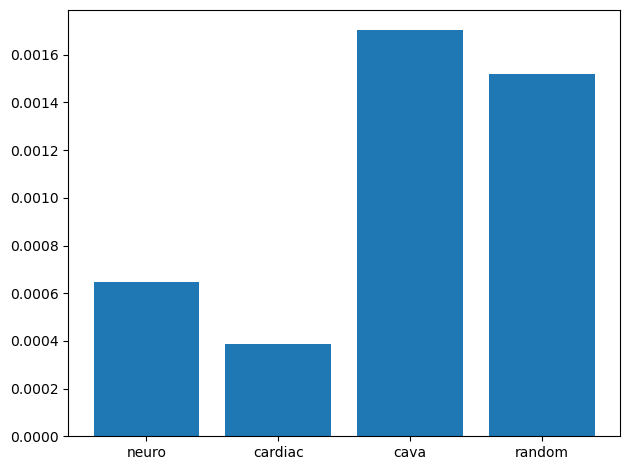

In [71]:
# plot the group differences: proportion of missing sequences for each group REFERENCE
group_list = ['neuro', 'cardiac', 'cava', 'random']
gene_set_column = "gene_set"
significant_column = "bcalm_element_adjusted_p_value"
column_to_plot = "covered_size"
sequence_size_threshold = 270
x_label = "Gene Sets"
y_label = "Proportion of Missing Sequences"
title = "Proportion of Reference Sequences with missing PhastCons100way scores"

ref_group_result = []
for group in group_list:
    # Filter sequences for each gene set
    group_sequences = REF_tested_cre_activity_remap_tfbs_occurences_phastCons[
        REF_tested_cre_activity_remap_tfbs_occurences_phastCons[gene_set_column].apply(lambda x: group.lower() in x)
    ].copy()

    significant_group_sequences = group_sequences[group_sequences[significant_column] < significance_threshold].copy()

    # Calculate mean, median, and count for all three groups
    total_count = group_sequences.shape[0]
    sig_count = significant_group_sequences.shape[0]
    all_n_missing = group_sequences.loc[group_sequences[column_to_plot] != sequence_size_threshold].shape[0]
    sig_n_missing = significant_group_sequences.loc[significant_group_sequences[column_to_plot] != sequence_size_threshold].shape[0]
    all_n_found = group_sequences.loc[group_sequences[column_to_plot] == sequence_size_threshold].shape[0]
    sig_n_found = significant_group_sequences.loc[significant_group_sequences[column_to_plot] == sequence_size_threshold].shape[0]

    ref_group_result.append({
        'Gene_Set': group,
        'All_n_missing': all_n_missing,
        'Significant_n_missing': sig_n_missing,
        'All_n_found': all_n_found,
        'Significant_n_found': sig_n_found,
        'All_Count': total_count,
        'Significant_Count': sig_count,
        'all_missing_proportion': all_n_missing / total_count if total_count > 0 else 0,
        'significant_missing_proportion': sig_n_missing / sig_count if sig_count > 0 else 0,
        'all_found_proportion': all_n_found / total_count if total_count > 0 else 0,
        'significant_found_proportion': sig_n_found / sig_count if sig_count > 0 else 0
    })

# Create a DataFrame for plotting
ref_plot_data = pd.DataFrame(ref_group_result)
plt.bar(ref_plot_data['Gene_Set'], ref_plot_data['all_missing_proportion'])

plt.tight_layout()
plt.show()

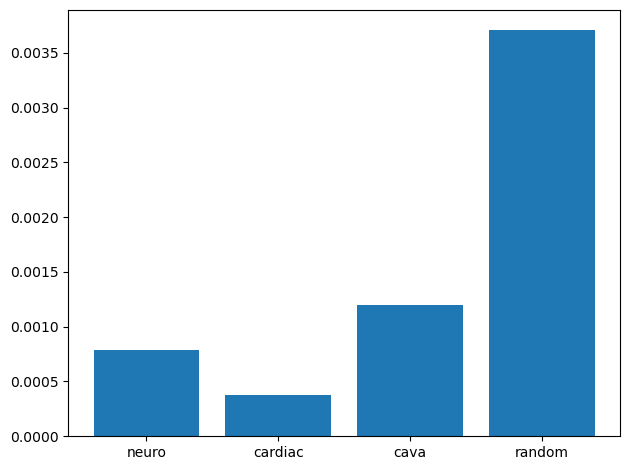

In [72]:
# plot the group differences: proportion of missing sequences for each group
group_list = ['neuro', 'cardiac', 'cava', 'random']
gene_set_column = "gene_set"
significant_column = "bcalm_element_adjusted_p_value"
column_to_plot = "covered_size"
sequence_size_threshold = 270
x_label = "Gene Sets"
y_label = "Proportion of Missing Sequences"
title = "Proportion of sequences with missing PhastCons100way scores"

group_result = []
for group in group_list:
    # Filter sequences for each gene set
    group_sequences = tested_cre_activity_remap_tfbs_occurences_phastCons[
        tested_cre_activity_remap_tfbs_occurences_phastCons[gene_set_column].apply(lambda x: group.lower() in x)
    ].copy()

    significant_group_sequences = group_sequences[group_sequences[significant_column] < significance_threshold].copy()

    # Calculate mean, median, and count for all three groups
    total_count = group_sequences.shape[0]
    sig_count = significant_group_sequences.shape[0]
    all_n_missing = group_sequences.loc[group_sequences[column_to_plot] != sequence_size_threshold].shape[0]
    sig_n_missing = significant_group_sequences.loc[significant_group_sequences[column_to_plot] != sequence_size_threshold].shape[0]
    all_n_found = group_sequences.loc[group_sequences[column_to_plot] == sequence_size_threshold].shape[0]
    sig_n_found = significant_group_sequences.loc[significant_group_sequences[column_to_plot] == sequence_size_threshold].shape[0]

    group_result.append({
        'Gene_Set': group,
        'All_n_missing': all_n_missing,
        'Significant_n_missing': sig_n_missing,
        'All_n_found': all_n_found,
        'Significant_n_found': sig_n_found,
        'All_Count': total_count,
        'Significant_Count': sig_count,
        'all_missing_proportion': all_n_missing / total_count if total_count > 0 else 0,
        'significant_missing_proportion': sig_n_missing / sig_count if sig_count > 0 else 0,
        'all_found_proportion': all_n_found / total_count if total_count > 0 else 0,
        'significant_found_proportion': sig_n_found / sig_count if sig_count > 0 else 0
    })

# Create a DataFrame for plotting
plot_data = pd.DataFrame(group_result)
plt.bar(plot_data['Gene_Set'], plot_data['all_missing_proportion'])

plt.tight_layout()
plt.show()


#### Plot the PhastCons scores for each gene group

In [153]:
group_list = ['neuro', 'cardiac', 'cava', 'random']
significant_column = "bcalm_element_adjusted_p_value"
gene_set_column = "gene_set"
column_to_plot = "sum"
x_label = "Gene Sets"
y_label = "Mean PhastCons100way Score"
title = "Mean PhastCons100way for All vs significantly active CREs"

def plot_phastCons_all_vs_significant_CREs(tested_cre_activity_remap_tfbs_occurences_phastCons,
                                           group_list=['neuro', 'cardiac', 'cava', 'random'],
                                           significant_column="bcalm_element_adjusted_p_value",
                                           gene_set_column="gene_set",
                                           column_to_plot="sum",
                                           significance_threshold=0.1,
                                           x_label='Gene Set',
                                           y_label='PhastCons Score',
                                           title='Mean PhastCons Score for All vs Significant Active CREs'):
    """
    Plots the mean PhastCons score for all CREs versus significantly active CREs for each gene set.
    """
    group_result = []
    for group in group_list:
        # Filter sequences for each gene set
        group_sequences = tested_cre_activity_remap_tfbs_occurences_phastCons[
            tested_cre_activity_remap_tfbs_occurences_phastCons[gene_set_column].apply(lambda x: group.lower() in x)
        ].copy()

        significant_group_sequences = group_sequences[group_sequences[significant_column] < significance_threshold].copy()

        # Calculate mean, median, and count for all three groups
        total_count = len(group_sequences)
        sig_count = len(significant_group_sequences)
        all_cre_mean = group_sequences[column_to_plot].sum() / total_count if total_count > 0 else 0
        sig_cre_mean = significant_group_sequences[column_to_plot].sum() / sig_count if sig_count > 0 else 0

        group_result.append({
            'Gene_Set': group,
            'All_CRE_mean': all_cre_mean,
            'Significant_CRE_mean': sig_cre_mean,
            'All_Count': total_count,
            'Significant_Count': sig_count
        })


    # Create a DataFrame for plotting
    plot_data = pd.DataFrame(group_result)

    # Plotting the data
    fig, ax = plt.subplots(figsize=(12, 6))

    bar_width = 0.35
    index = range(len(group_list))

    ax.bar(index, plot_data["All_CRE_mean"], bar_width, label='All CREs')
    ax.bar([i + bar_width for i in index], plot_data['Significant_CRE_mean'], bar_width, label='Significant')

    # Add group sizes as text labels
    for i, row in plot_data.iterrows():
        ax.text(index[i], row["All_CRE_mean"] + 0.1, f'n={row["All_Count"]}', ha='center', va='bottom', fontsize=10)
        ax.text(index[i], row["All_CRE_mean"] - 5, f'{round(row["All_CRE_mean"],1)}', ha='center', va='bottom', fontsize=10)
        ax.text(index[i] + bar_width, row["Significant_CRE_mean"] + 0.1, f'n={row["Significant_Count"]}', ha='center', va='bottom', fontsize=10)
        ax.text(index[i] + bar_width, row["Significant_CRE_mean"] - 5, f'{round(row["Significant_CRE_mean"],1)}', ha='center', va='bottom', fontsize=10)

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title + f" (sig. level: {significance_threshold})")
    ax.set_xticks([i + bar_width / 2 for i in index])
    ax.set_xticklabels(plot_data['Gene_Set'])
    # legend location bottom left
    ax.legend(loc='upper left')

    plt.tight_layout()
    plt.show()
    return group_result


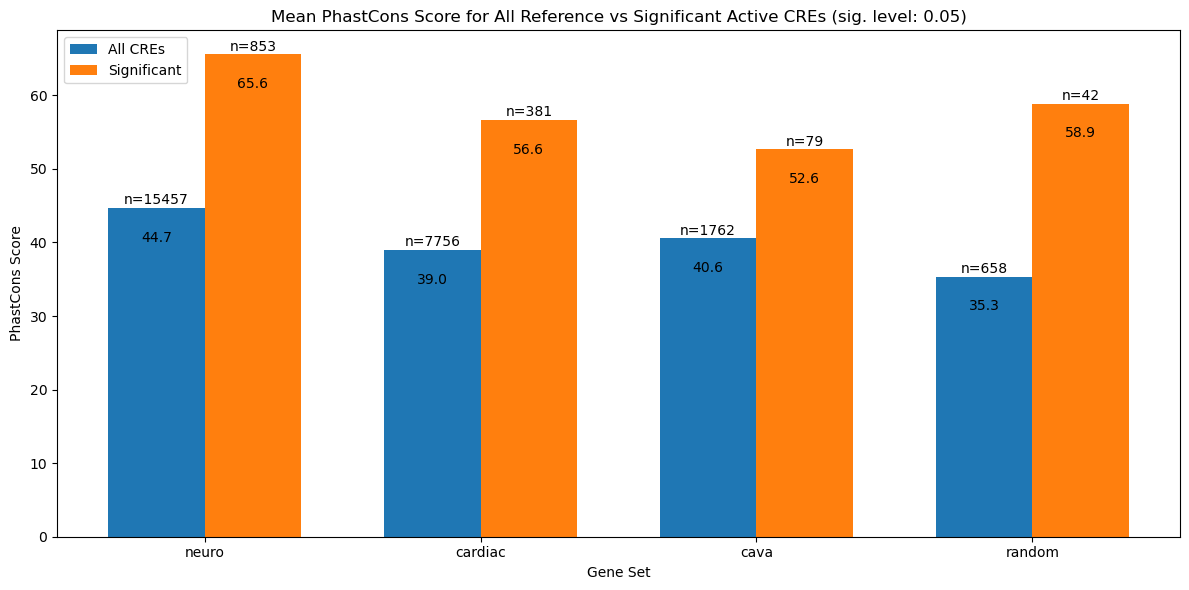

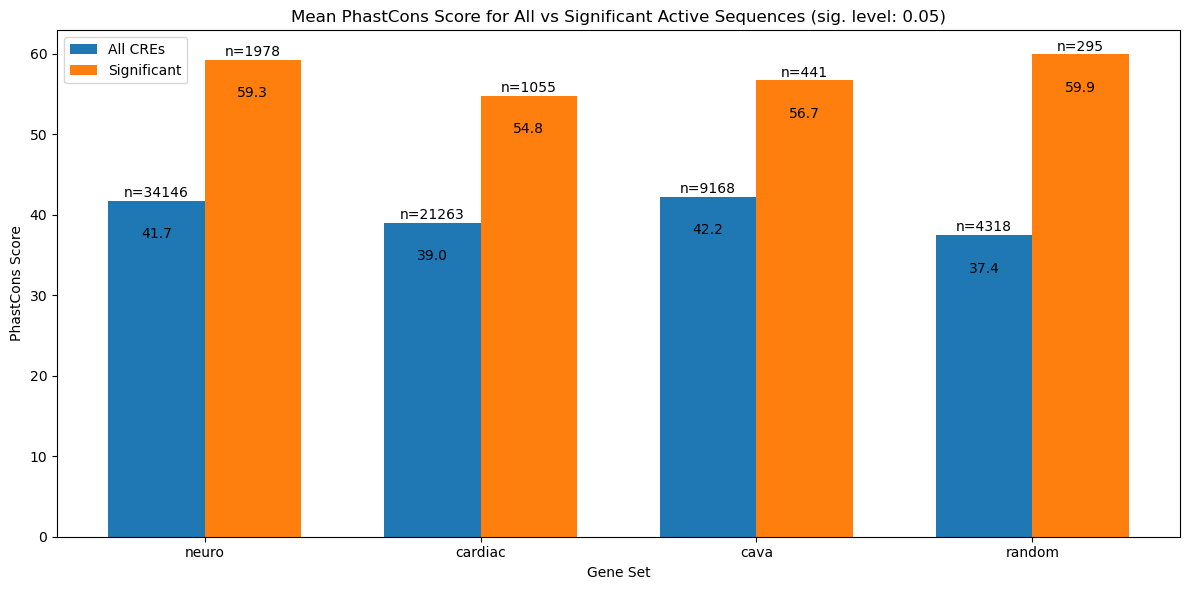

In [166]:
phast_cons_plot_data_all_ref_80k = plot_phastCons_all_vs_significant_CREs(REF_tested_cre_activity_remap_tfbs_occurences_phastCons,
                                       group_list=['neuro', 'cardiac', 'cava', 'random'],
                                       significant_column="bcalm_element_adjusted_p_value",
                                       gene_set_column="gene_set", column_to_plot="sum",
                                       significance_threshold=significance_threshold, x_label='Gene Set', y_label='PhastCons Score',
                                       title='Mean PhastCons Score for All Reference vs Significant Active CREs')
phast_cons_plot_data_all_seq_80k = plot_phastCons_all_vs_significant_CREs(tested_cre_activity_remap_tfbs_occurences_phastCons, group_list=['neuro', 'cardiac', 'cava', 'random'], significant_column="bcalm_element_adjusted_p_value", gene_set_column="gene_set", column_to_plot="sum", significance_threshold=significance_threshold, x_label='Gene Set', y_label='PhastCons Score', title='Mean PhastCons Score for All vs Significant Active Sequences')

In [ ]:
# from
REF_tested_cre_activity_remap_tfbs_occurences_phastCons

,chrom,start,end,name,strand,TFBS_list,number_of_TFBS,n_unique_TFBS,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,...,is_H9_SCREEN_cCRE,is_H1_SCREEN_cCRE,is_neural_stem_SCREEN_cCRE,is_excitatory_neuron_SCREEN_cCRE,covered_size,sum,mean0,mean,is_neuro_active_SCREEN,absolute_activity
0,chr1,10588680,10588950,cardiac_neuro_cava_random:REF_CASZ1|ENSG000001...,-,[MAFF],1,1,1.0,0.015284,...,False,False,False,False,270,59.714,0.221163,0.221163,False,0.015284
1,chr1,10594736,10595006,cardiac_neuro_cava_random:REF_CASZ1|ENSG000001...,-,"[RBPJ, MEF2B, TFAP2C, SND1, ZNF263, POU5F1, SM...",24,24,1.0,0.018937,...,True,False,False,False,270,48.146,0.178319,0.178319,False,0.018937
2,chr1,10597875,10598145,cardiac_neuro_cava_random:CASZ1|ENSG0000013094...,-,"[SMARCC1, KLF4, TFAP2C, EZH2, RBBP4, SS18, MYC...",13,13,1.0,-0.052969,...,False,False,False,False,270,131.888,0.488474,0.488474,False,0.052969
3,chr1,10599192,10599462,cardiac_neuro_cava_random:CASZ1|ENSG0000013094...,-,"[EGR1, CREBBP, ZNF44, HOXA3, ARID2, MED1, ZBTB...",133,130,1.0,-0.029333,...,False,False,False,False,270,136.565,0.505796,0.505796,False,0.029333
4,chr1,10601429,10601699,cardiac_neuro_cava_random:CASZ1|ENSG0000013094...,-,"[KMT2A, RAD21, ZNF3, NR3C1, ZNF550, MYCN, NKX2...",13,13,1.0,-0.070292,...,False,False,False,False,270,1.344,0.004978,0.004978,False,0.070292
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24581,chrX,77784045,77784315,cardiac_neuro_cava_random:ATRX|ENSG00000085224...,-,"[CRX, MEF2D, OTX2, SMARCA4, TBX21, RBFOX2, BCL...",9,9,1.0,-0.039769,...,False,False,False,False,270,31.674,0.117311,0.117311,False,0.039769
24582,chrX,77786807,77787077,cardiac_neuro_cava_random:REF_ATRX|ENSG0000008...,-,"[ZSCAN4, FOXA1, RFX5, SPI1, ZBTB2, SPIB, KDM1A...",8,8,1.0,0.035090,...,False,False,False,False,270,23.489,0.086996,0.086996,False,0.035090
24583,chrX,77787587,77787857,cardiac_neuro_cava_random:ATRX|ENSG00000085224...,-,"[BRD4, ZGPAT, HAND2, PHOX2B, ZBED4, TEAD4, SRE...",9,9,1.0,-0.010949,...,False,False,False,False,270,51.820,0.191926,0.191926,False,0.010949
24584,chrX,77788137,77788407,cardiac_neuro_cava_random:ATRX|ENSG00000085224...,-,"[LIN54, SREBP2, MYBL2, FOXA2, ZNF24, KLF4, NFY...",45,45,1.0,-0.031196,...,False,False,False,False,270,45.817,0.169693,0.169693,False,0.031196


In [193]:
REF_tested_cre_activity_remap_tfbs_occurences_phastCons['is_significant_element'] = REF_tested_cre_activity_remap_tfbs_occurences_phastCons["bcalm_element_adjusted_p_value"] < 0.05
REF_tested_cre_activity_remap_tfbs_occurences_phastCons

,chrom,start,end,name,strand,TFBS_list,number_of_TFBS,n_unique_TFBS,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,...,is_H1_SCREEN_cCRE,is_neural_stem_SCREEN_cCRE,is_excitatory_neuron_SCREEN_cCRE,covered_size,sum,mean0,mean,is_neuro_active_SCREEN,absolute_activity,is_significant_element
0,chr1,10588680,10588950,cardiac_neuro_cava_random:REF_CASZ1|ENSG000001...,-,[MAFF],1,1,1.0,0.015284,...,False,False,False,270,59.714,0.221163,0.221163,False,0.015284,False
1,chr1,10594736,10595006,cardiac_neuro_cava_random:REF_CASZ1|ENSG000001...,-,"[RBPJ, MEF2B, TFAP2C, SND1, ZNF263, POU5F1, SM...",24,24,1.0,0.018937,...,False,False,False,270,48.146,0.178319,0.178319,False,0.018937,False
2,chr1,10597875,10598145,cardiac_neuro_cava_random:CASZ1|ENSG0000013094...,-,"[SMARCC1, KLF4, TFAP2C, EZH2, RBBP4, SS18, MYC...",13,13,1.0,-0.052969,...,False,False,False,270,131.888,0.488474,0.488474,False,0.052969,False
3,chr1,10599192,10599462,cardiac_neuro_cava_random:CASZ1|ENSG0000013094...,-,"[EGR1, CREBBP, ZNF44, HOXA3, ARID2, MED1, ZBTB...",133,130,1.0,-0.029333,...,False,False,False,270,136.565,0.505796,0.505796,False,0.029333,False
4,chr1,10601429,10601699,cardiac_neuro_cava_random:CASZ1|ENSG0000013094...,-,"[KMT2A, RAD21, ZNF3, NR3C1, ZNF550, MYCN, NKX2...",13,13,1.0,-0.070292,...,False,False,False,270,1.344,0.004978,0.004978,False,0.070292,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24581,chrX,77784045,77784315,cardiac_neuro_cava_random:ATRX|ENSG00000085224...,-,"[CRX, MEF2D, OTX2, SMARCA4, TBX21, RBFOX2, BCL...",9,9,1.0,-0.039769,...,False,False,False,270,31.674,0.117311,0.117311,False,0.039769,False
24582,chrX,77786807,77787077,cardiac_neuro_cava_random:REF_ATRX|ENSG0000008...,-,"[ZSCAN4, FOXA1, RFX5, SPI1, ZBTB2, SPIB, KDM1A...",8,8,1.0,0.035090,...,False,False,False,270,23.489,0.086996,0.086996,False,0.035090,False
24583,chrX,77787587,77787857,cardiac_neuro_cava_random:ATRX|ENSG00000085224...,-,"[BRD4, ZGPAT, HAND2, PHOX2B, ZBED4, TEAD4, SRE...",9,9,1.0,-0.010949,...,False,False,False,270,51.820,0.191926,0.191926,False,0.010949,False
24584,chrX,77788137,77788407,cardiac_neuro_cava_random:ATRX|ENSG00000085224...,-,"[LIN54, SREBP2, MYBL2, FOXA2, ZNF24, KLF4, NFY...",45,45,1.0,-0.031196,...,False,False,False,270,45.817,0.169693,0.169693,False,0.031196,False


In [194]:
REF_tested_cre_activity_remap_tfbs_occurences_phastCons.columns

Index(['chrom', 'start', 'end', 'name', 'strand', 'TFBS_list',
       'number_of_TFBS', 'n_unique_TFBS', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'gene_name',
       'gene_set', 'SCREEN_ID', 'is_NPC_SCREEN_cCRE', 'is_H9_SCREEN_cCRE',
       'is_H1_SCREEN_cCRE', 'is_neural_stem_SCREEN_cCRE',
       'is_excitatory_neuron_SCREEN_cCRE', 'covered_size', 'sum', 'mean0',
       'mean', 'is_neuro_active_SCREEN', 'absolute_activity',
       'is_significant_element'],
      dtype='object')

In [196]:
import pandas as pd

# Assuming the 'gene_set' column is a string of comma-separated values, you'll split it.
df_long = (REF_tested_cre_activity_remap_tfbs_occurences_phastCons.assign(
    gene_set=REF_tested_cre_activity_remap_tfbs_occurences_phastCons['gene_set'].str.split(', ')
).explode('gene_set'))

df_long
# # Check the new structure
# print(df_long.head())

,chrom,start,end,name,strand,TFBS_list,number_of_TFBS,n_unique_TFBS,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,...,is_H1_SCREEN_cCRE,is_neural_stem_SCREEN_cCRE,is_excitatory_neuron_SCREEN_cCRE,covered_size,sum,mean0,mean,is_neuro_active_SCREEN,absolute_activity,is_significant_element
0,chr1,10588680,10588950,cardiac_neuro_cava_random:REF_CASZ1|ENSG000001...,-,[MAFF],1,1,1.0,0.015284,...,False,False,False,270,59.714,0.221163,0.221163,False,0.015284,False
1,chr1,10594736,10595006,cardiac_neuro_cava_random:REF_CASZ1|ENSG000001...,-,"[RBPJ, MEF2B, TFAP2C, SND1, ZNF263, POU5F1, SM...",24,24,1.0,0.018937,...,False,False,False,270,48.146,0.178319,0.178319,False,0.018937,False
2,chr1,10597875,10598145,cardiac_neuro_cava_random:CASZ1|ENSG0000013094...,-,"[SMARCC1, KLF4, TFAP2C, EZH2, RBBP4, SS18, MYC...",13,13,1.0,-0.052969,...,False,False,False,270,131.888,0.488474,0.488474,False,0.052969,False
3,chr1,10599192,10599462,cardiac_neuro_cava_random:CASZ1|ENSG0000013094...,-,"[EGR1, CREBBP, ZNF44, HOXA3, ARID2, MED1, ZBTB...",133,130,1.0,-0.029333,...,False,False,False,270,136.565,0.505796,0.505796,False,0.029333,False
4,chr1,10601429,10601699,cardiac_neuro_cava_random:CASZ1|ENSG0000013094...,-,"[KMT2A, RAD21, ZNF3, NR3C1, ZNF550, MYCN, NKX2...",13,13,1.0,-0.070292,...,False,False,False,270,1.344,0.004978,0.004978,False,0.070292,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24581,chrX,77784045,77784315,cardiac_neuro_cava_random:ATRX|ENSG00000085224...,-,"[CRX, MEF2D, OTX2, SMARCA4, TBX21, RBFOX2, BCL...",9,9,1.0,-0.039769,...,False,False,False,270,31.674,0.117311,0.117311,False,0.039769,False
24582,chrX,77786807,77787077,cardiac_neuro_cava_random:REF_ATRX|ENSG0000008...,-,"[ZSCAN4, FOXA1, RFX5, SPI1, ZBTB2, SPIB, KDM1A...",8,8,1.0,0.035090,...,False,False,False,270,23.489,0.086996,0.086996,False,0.035090,False
24583,chrX,77787587,77787857,cardiac_neuro_cava_random:ATRX|ENSG00000085224...,-,"[BRD4, ZGPAT, HAND2, PHOX2B, ZBED4, TEAD4, SRE...",9,9,1.0,-0.010949,...,False,False,False,270,51.820,0.191926,0.191926,False,0.010949,False
24584,chrX,77788137,77788407,cardiac_neuro_cava_random:ATRX|ENSG00000085224...,-,"[LIN54, SREBP2, MYBL2, FOXA2, ZNF24, KLF4, NFY...",45,45,1.0,-0.031196,...,False,False,False,270,45.817,0.169693,0.169693,False,0.031196,False


In [201]:
df_exploded = REF_tested_cre_activity_remap_tfbs_occurences_phastCons.explode('gene_set')

In [205]:
# df_exploded

In [ ]:
# Create a copy for the 'All' elements and assign the 'type'
df_all = df_exploded.copy()
df_all['type'] = 'All'
df_all
# Filter for significant elements and assign the 'type'
df_significant = df_exploded[df_exploded['is_significant_element'] == True].copy()
df_significant['type'] = 'Significant'

# Concatenate the two DataFrames to get the final long format
df_long_format = pd.concat([df_all, df_significant], ignore_index=True)

# Remove any redundant rows that might be created
df_long_format = df_long_format.drop_duplicates()

# Display the final result
print(df_long_format.head())

,chrom,start,end,name,strand,TFBS_list,number_of_TFBS,n_unique_TFBS,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,...,is_neural_stem_SCREEN_cCRE,is_excitatory_neuron_SCREEN_cCRE,covered_size,sum,mean0,mean,is_neuro_active_SCREEN,absolute_activity,is_significant_element,type
0,chr1,10588680,10588950,cardiac_neuro_cava_random:REF_CASZ1|ENSG000001...,-,[MAFF],1,1,1.0,0.015284,...,False,False,270,59.714,0.221163,0.221163,False,0.015284,False,All
1,chr1,10594736,10595006,cardiac_neuro_cava_random:REF_CASZ1|ENSG000001...,-,"[RBPJ, MEF2B, TFAP2C, SND1, ZNF263, POU5F1, SM...",24,24,1.0,0.018937,...,False,False,270,48.146,0.178319,0.178319,False,0.018937,False,All
2,chr1,10597875,10598145,cardiac_neuro_cava_random:CASZ1|ENSG0000013094...,-,"[SMARCC1, KLF4, TFAP2C, EZH2, RBBP4, SS18, MYC...",13,13,1.0,-0.052969,...,False,False,270,131.888,0.488474,0.488474,False,0.052969,False,All
3,chr1,10599192,10599462,cardiac_neuro_cava_random:CASZ1|ENSG0000013094...,-,"[EGR1, CREBBP, ZNF44, HOXA3, ARID2, MED1, ZBTB...",133,130,1.0,-0.029333,...,False,False,270,136.565,0.505796,0.505796,False,0.029333,False,All
4,chr1,10601429,10601699,cardiac_neuro_cava_random:CASZ1|ENSG0000013094...,-,"[KMT2A, RAD21, ZNF3, NR3C1, ZNF550, MYCN, NKX2...",13,13,1.0,-0.070292,...,False,False,270,1.344,0.004978,0.004978,False,0.070292,False,All
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24581,chrX,77784045,77784315,cardiac_neuro_cava_random:ATRX|ENSG00000085224...,-,"[CRX, MEF2D, OTX2, SMARCA4, TBX21, RBFOX2, BCL...",9,9,1.0,-0.039769,...,False,False,270,31.674,0.117311,0.117311,False,0.039769,False,All
24582,chrX,77786807,77787077,cardiac_neuro_cava_random:REF_ATRX|ENSG0000008...,-,"[ZSCAN4, FOXA1, RFX5, SPI1, ZBTB2, SPIB, KDM1A...",8,8,1.0,0.035090,...,False,False,270,23.489,0.086996,0.086996,False,0.035090,False,All
24583,chrX,77787587,77787857,cardiac_neuro_cava_random:ATRX|ENSG00000085224...,-,"[BRD4, ZGPAT, HAND2, PHOX2B, ZBED4, TEAD4, SRE...",9,9,1.0,-0.010949,...,False,False,270,51.820,0.191926,0.191926,False,0.010949,False,All
24584,chrX,77788137,77788407,cardiac_neuro_cava_random:ATRX|ENSG00000085224...,-,"[LIN54, SREBP2, MYBL2, FOXA2, ZNF24, KLF4, NFY...",45,45,1.0,-0.031196,...,False,False,270,45.817,0.169693,0.169693,False,0.031196,False,All


In [167]:
phast_cons_plot_data_all_ref_80k

[{'Gene_Set': 'neuro',
  'All_CRE_mean': 44.655330141683386,
  'Significant_CRE_mean': 65.55262602579133,
  'All_Count': 15457,
  'Significant_Count': 853},
 {'Gene_Set': 'cardiac',
  'All_CRE_mean': 38.95446222279526,
  'Significant_CRE_mean': 56.63899737532808,
  'All_Count': 7756,
  'Significant_Count': 381},
 {'Gene_Set': 'cava',
  'All_CRE_mean': 40.56679909194097,
  'Significant_CRE_mean': 52.64265822784808,
  'All_Count': 1762,
  'Significant_Count': 79},
 {'Gene_Set': 'random',
  'All_CRE_mean': 35.342360182370825,
  'Significant_CRE_mean': 58.86290476190476,
  'All_Count': 658,
  'Significant_Count': 42}]

#### Using all CREs from SCREEN for a background distribution
- read in 
- make the conservation score per 270bp CRE 
- plot the distribution
- computed mean sum for 270bp over all CREs: 33.9

In [133]:
phastCons_average_tab_path = "/home/kisa/coding/80K_MPRA/remap_chipseq_pia/remap_cre_overlap/all_SCREEN_CREs_phastCons100way.tab.gz"
phastCons_all_SCREEN_CRE_df = pd.read_csv(phastCons_average_tab_path, sep="\t", low_memory=False, header=None)
phastCons_all_SCREEN_CRE_df.columns = ['name', 'seq_size', 'covered_size', 'sum', 'mean0', 'mean']
phastCons_all_SCREEN_CRE_df

,name,seq_size,covered_size,sum,mean0,mean
0,EH38D4327497,217,0,0.000,0.000000,0.000000
1,EH38D4327498,328,0,0.000,0.000000,0.000000
2,EH38D6144701,284,284,1.109,0.003905,0.003905
3,EH38D6144702,299,299,67.246,0.224903,0.224903
4,EH38D6144703,197,197,0.223,0.001132,0.001132
...,...,...,...,...,...,...
2348849,EH38D6144696,339,0,0.000,0.000000,0.000000
2348850,EH38D6144697,186,0,0.000,0.000000,0.000000
2348851,EH38D6473458,249,0,0.000,0.000000,0.000000
2348852,EH38D6144699,164,0,0.000,0.000000,0.000000


In [ ]:
print(f"Number of sequences which are not entirely covered: {(phastCons_all_SCREEN_CRE_df['covered_size'] != phastCons_all_SCREEN_CRE_df['seq_size']).sum()}")
print(f"Proportion of sequences which are not entirely covered: {(phastCons_all_SCREEN_CRE_df['covered_size'] != phastCons_all_SCREEN_CRE_df['seq_size']).sum()/phastCons_all_SCREEN_CRE_df.shape[0]}")

Number of sequences which are not entirely covered: 9976
Proportion of sequences which are not entirely covered: 0.0042471775597802165


In [141]:
phastCons_all_SCREEN_CRE_df_fully_covered = phastCons_all_SCREEN_CRE_df.loc[phastCons_all_SCREEN_CRE_df['covered_size'] == phastCons_all_SCREEN_CRE_df['seq_size']].copy()
phastCons_all_SCREEN_CRE_df_fully_covered

,name,seq_size,covered_size,sum,mean0,mean
2,EH38D6144701,284,284,1.109,0.003905,0.003905
3,EH38D6144702,299,299,67.246,0.224903,0.224903
4,EH38D6144703,197,197,0.223,0.001132,0.001132
5,EH38D4327503,159,159,38.379,0.241377,0.241377
6,EH38D4327504,248,248,45.745,0.184456,0.184456
...,...,...,...,...,...,...
2348834,EH38D4327396,204,204,43.605,0.213750,0.213750
2348835,EH38D4327397,238,238,26.492,0.111311,0.111311
2348836,EH38D4327398,230,230,5.651,0.024570,0.024570
2348837,EH38D6144680,271,271,203.968,0.752649,0.752649


In [145]:
# normalize the score to 270bp
phastCons_all_SCREEN_CRE_df_fully_covered['sum_270'] = phastCons_all_SCREEN_CRE_df_fully_covered['sum'] / phastCons_all_SCREEN_CRE_df_fully_covered['seq_size'] * 270
phastCons_all_SCREEN_CRE_df_fully_covered['sum_270'].describe()

count    2.338878e+06
mean     3.394451e+01
std      5.271037e+01
min      1.304348e-03
25%      2.693250e+00
50%      1.068743e+01
75%      3.879864e+01
max      2.700000e+02
Name: sum_270, dtype: float64

In [168]:
# generate new entry:
all_SCREEN_CREs = {'Gene_Set': 'all SCREEN CREs', 'All_CRE_mean': phastCons_all_SCREEN_CRE_df_fully_covered['sum_270'].mean(), 'Significant_CRE_mean': 0, 'All_Count': phastCons_all_SCREEN_CRE_df_fully_covered.shape[0], 'Significant_Count': 0}

In [169]:
phast_cons_plot_data_all_ref_80k.append(all_SCREEN_CREs)
# phast_cons_plot_data_all_ref_80k_with_all_SCREEN = phast_cons_plot_data_all_ref_80k + all_SCREEN_CREs
# phast_cons_plot_data_all_ref_80k_with_all_SCREEN

In [170]:
phast_cons_plot_data_all_ref_80k

[{'Gene_Set': 'neuro',
  'All_CRE_mean': 44.655330141683386,
  'Significant_CRE_mean': 65.55262602579133,
  'All_Count': 15457,
  'Significant_Count': 853},
 {'Gene_Set': 'cardiac',
  'All_CRE_mean': 38.95446222279526,
  'Significant_CRE_mean': 56.63899737532808,
  'All_Count': 7756,
  'Significant_Count': 381},
 {'Gene_Set': 'cava',
  'All_CRE_mean': 40.56679909194097,
  'Significant_CRE_mean': 52.64265822784808,
  'All_Count': 1762,
  'Significant_Count': 79},
 {'Gene_Set': 'random',
  'All_CRE_mean': 35.342360182370825,
  'Significant_CRE_mean': 58.86290476190476,
  'All_Count': 658,
  'Significant_Count': 42},
 {'Gene_Set': 'all SCREEN CREs',
  'All_CRE_mean': 33.94450634606966,
  'Significant_CRE_mean': 0,
  'All_Count': 2338878,
  'Significant_Count': 0}]

In [172]:
plot_data

,Gene_Set,All_CRE_mean,Significant_CRE_mean,All_Count,Significant_Count
0,neuro,44.655330,65.552626,15457,853
1,cardiac,38.954462,56.638997,7756,381
2,cava,40.566799,52.642658,1762,79
3,random,35.342360,58.862905,658,42
4,all SCREEN CREs,33.944506,0.000000,2338878,0


In [ ]:
plot_data

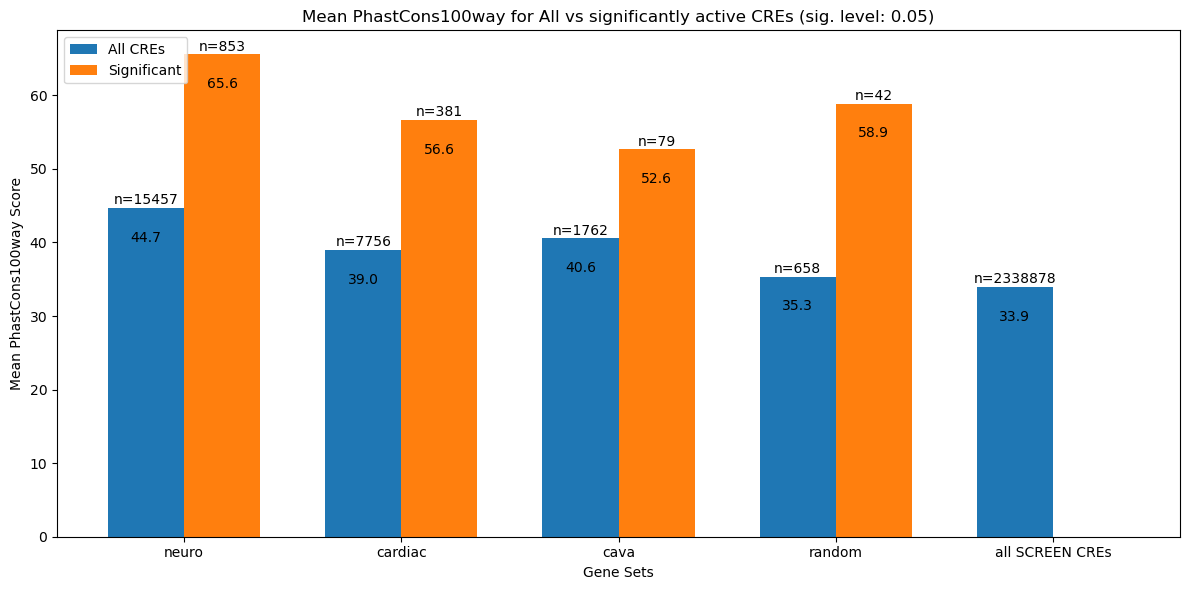

In [174]:
# Create a DataFrame for plotting
plot_data = pd.DataFrame(phast_cons_plot_data_all_ref_80k)

# Plotting the data
fig, ax = plt.subplots(figsize=(12, 6))

bar_width = 0.35
index = range(len(plot_data['Gene_Set'].to_list()))

ax.bar(index, plot_data["All_CRE_mean"], bar_width, label='All CREs')
ax.bar([i + bar_width for i in index], plot_data['Significant_CRE_mean'], bar_width, label='Significant')

# Add group sizes as text labels
for i, row in plot_data.iterrows():
    ax.text(index[i], row["All_CRE_mean"] + 0.1, f'n={row["All_Count"]}', ha='center', va='bottom', fontsize=10)
    ax.text(index[i], row["All_CRE_mean"] - 5, f'{round(row["All_CRE_mean"],1)}', ha='center', va='bottom', fontsize=10)
    if row["Significant_Count"] > 0:
        ax.text(index[i] + bar_width, row["Significant_CRE_mean"] + 0.1, f'n={row["Significant_Count"]}', ha='center', va='bottom', fontsize=10)
        ax.text(index[i] + bar_width, row["Significant_CRE_mean"] - 5, f'{round(row["Significant_CRE_mean"],1)}', ha='center', va='bottom', fontsize=10)

ax.set_xlabel(x_label)
ax.set_ylabel(y_label)
ax.set_title(title + f" (sig. level: {significance_threshold})")
ax.set_xticks([i + bar_width / 2 for i in index])
ax.set_xticklabels(plot_data['Gene_Set'])
# legend location bottom left
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [178]:
print(plot_data)

          Gene_Set  All_CRE_mean  Significant_CRE_mean  All_Count  \
0            neuro     44.655330             65.552626      15457   
1          cardiac     38.954462             56.638997       7756   
2             cava     40.566799             52.642658       1762   
3           random     35.342360             58.862905        658   
4  all SCREEN CREs     33.944506              0.000000    2338878   

   Significant_Count  
0                853  
1                381  
2                 79  
3                 42  
4                  0  


In [ ]:
plot_data

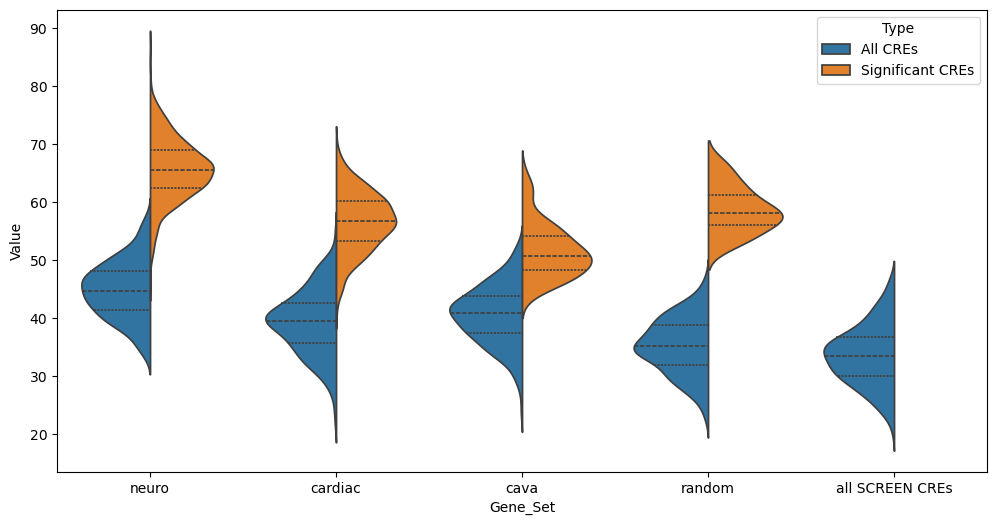

In [181]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.violinplot(
    x='Gene_Set',
    y='Value',
    hue='Type',
    data=final_plot_data,
    split=True,
    inner="quart"
)

plt.show()

In [190]:
REF_tested_cre_activity_remap_tfbs_occurences_phastCons

,chrom,start,end,name,strand,TFBS_list,number_of_TFBS,n_unique_TFBS,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,...,is_H9_SCREEN_cCRE,is_H1_SCREEN_cCRE,is_neural_stem_SCREEN_cCRE,is_excitatory_neuron_SCREEN_cCRE,covered_size,sum,mean0,mean,is_neuro_active_SCREEN,absolute_activity
0,chr1,10588680,10588950,cardiac_neuro_cava_random:REF_CASZ1|ENSG000001...,-,[MAFF],1,1,1.0,0.015284,...,False,False,False,False,270,59.714,0.221163,0.221163,False,0.015284
1,chr1,10594736,10595006,cardiac_neuro_cava_random:REF_CASZ1|ENSG000001...,-,"[RBPJ, MEF2B, TFAP2C, SND1, ZNF263, POU5F1, SM...",24,24,1.0,0.018937,...,True,False,False,False,270,48.146,0.178319,0.178319,False,0.018937
2,chr1,10597875,10598145,cardiac_neuro_cava_random:CASZ1|ENSG0000013094...,-,"[SMARCC1, KLF4, TFAP2C, EZH2, RBBP4, SS18, MYC...",13,13,1.0,-0.052969,...,False,False,False,False,270,131.888,0.488474,0.488474,False,0.052969
3,chr1,10599192,10599462,cardiac_neuro_cava_random:CASZ1|ENSG0000013094...,-,"[EGR1, CREBBP, ZNF44, HOXA3, ARID2, MED1, ZBTB...",133,130,1.0,-0.029333,...,False,False,False,False,270,136.565,0.505796,0.505796,False,0.029333
4,chr1,10601429,10601699,cardiac_neuro_cava_random:CASZ1|ENSG0000013094...,-,"[KMT2A, RAD21, ZNF3, NR3C1, ZNF550, MYCN, NKX2...",13,13,1.0,-0.070292,...,False,False,False,False,270,1.344,0.004978,0.004978,False,0.070292
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24581,chrX,77784045,77784315,cardiac_neuro_cava_random:ATRX|ENSG00000085224...,-,"[CRX, MEF2D, OTX2, SMARCA4, TBX21, RBFOX2, BCL...",9,9,1.0,-0.039769,...,False,False,False,False,270,31.674,0.117311,0.117311,False,0.039769
24582,chrX,77786807,77787077,cardiac_neuro_cava_random:REF_ATRX|ENSG0000008...,-,"[ZSCAN4, FOXA1, RFX5, SPI1, ZBTB2, SPIB, KDM1A...",8,8,1.0,0.035090,...,False,False,False,False,270,23.489,0.086996,0.086996,False,0.035090
24583,chrX,77787587,77787857,cardiac_neuro_cava_random:ATRX|ENSG00000085224...,-,"[BRD4, ZGPAT, HAND2, PHOX2B, ZBED4, TEAD4, SRE...",9,9,1.0,-0.010949,...,False,False,False,False,270,51.820,0.191926,0.191926,False,0.010949
24584,chrX,77788137,77788407,cardiac_neuro_cava_random:ATRX|ENSG00000085224...,-,"[LIN54, SREBP2, MYBL2, FOXA2, ZNF24, KLF4, NFY...",45,45,1.0,-0.031196,...,False,False,False,False,270,45.817,0.169693,0.169693,False,0.031196


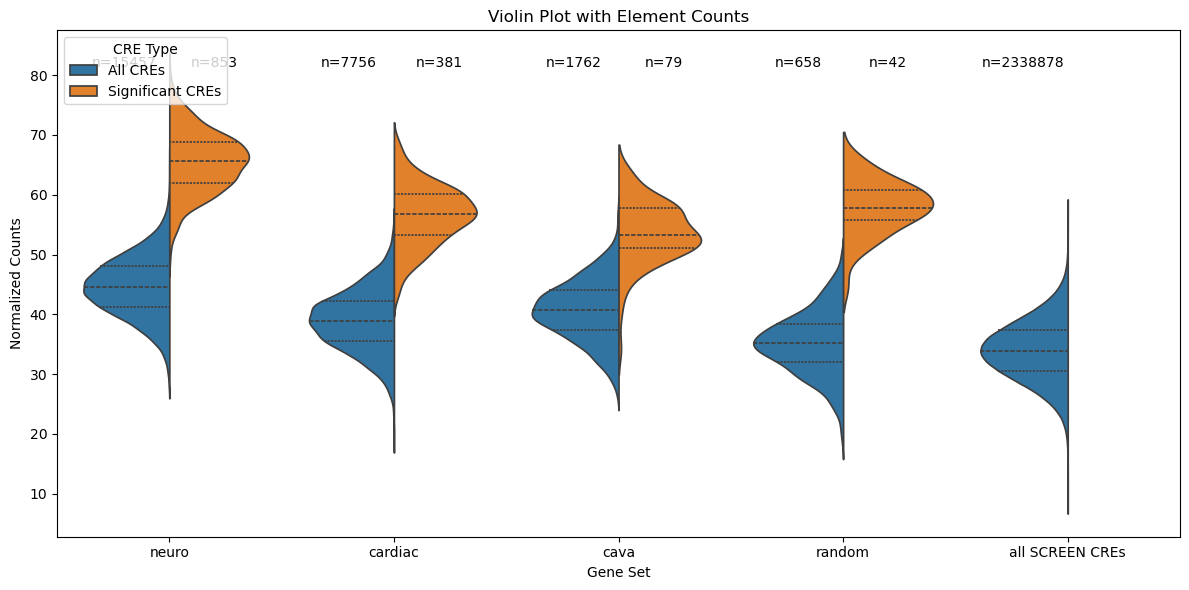

In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dummy Data (You will replace this with your actual data)
summary_data = pd.DataFrame({
    'Gene_Set': ['neuro', 'cardiac', 'cava', 'random', 'all SCREEN CREs'],
    'All_CRE_mean': [44.65, 38.95, 40.56, 35.34, 33.94],
    'Significant_CRE_mean': [65.55, 56.63, 52.64, 58.86, 0.00],
    'All_Count': [15457, 7756, 1762, 658, 2338878],
    'Significant_Count': [853, 381, 79, 42, 0]
})

raw_data = []
for _, row in summary_data.iterrows():
    # All CREs data
    raw_data.append(pd.DataFrame({
        'Gene_Set': row['Gene_Set'],
        'Type': 'All CREs',
        'Value': np.random.normal(row['All_CRE_mean'], 5, row['All_Count']) # Using actual count
    }))
    # Significant CREs data (only if count > 0)
    if row['Significant_Count'] > 0:
        raw_data.append(pd.DataFrame({
            'Gene_Set': row['Gene_Set'],
            'Type': 'Significant CREs',
            'Value': np.random.normal(row['Significant_CRE_mean'], 5, row['Significant_Count']) # Using actual count
        }))

raw_data_df = pd.concat(raw_data).reset_index(drop=True)

# Function to filter data (from previous response)
def prepare_raw_data_for_violin_plot(raw_data_df, summary_data_df):
    no_sig_sets = summary_data_df[summary_data_df['Significant_Count'] == 0]['Gene_Set'].tolist()
    filtered_data = raw_data_df[
        ~((raw_data_df['Type'].str.contains('Significant', case=False)) &
          (raw_data_df['Gene_Set'].isin(no_sig_sets)))
    ].copy()
    return filtered_data

final_plot_data = prepare_raw_data_for_violin_plot(raw_data_df, summary_data)

# --- Start of new/updated plotting section ---
fig, ax = plt.subplots(figsize=(12, 6))

# Use violinplot to create the plot on the specified axes
sns.violinplot(
    x='Gene_Set',
    y='Value',
    hue='Type',
    data=final_plot_data,
    split=True,
    inner="quart",
    ax=ax
)

# Annotate with the counts
x_positions = [0, 1, 2, 3, 4] # Corresponds to the order of Gene_Sets
bar_width = 0.4 # Adjust this value if the violins are too wide or narrow

for i, gene_set in enumerate(summary_data['Gene_Set'].to_list()):
    all_count = summary_data.loc[summary_data['Gene_Set'] == gene_set, 'All_Count'].iloc[0]
    sig_count = summary_data.loc[summary_data['Gene_Set'] == gene_set, 'Significant_Count'].iloc[0]

    # Position for 'All CREs' violin
    all_pos = x_positions[i] - bar_width / 2.0
    ax.text(all_pos, ax.get_ylim()[1] * 0.95, f'n={all_count}',
            ha='center', va='top', fontsize=10, color='black')

    # Position for 'Significant CREs' violin (if it exists)
    if sig_count > 0:
        sig_pos = x_positions[i] + bar_width / 2.0
        ax.text(sig_pos, ax.get_ylim()[1] * 0.95, f'n={sig_count}',
                ha='center', va='top', fontsize=10, color='black')

# Final plot adjustments
ax.set_xlabel('Gene Set')
ax.set_ylabel('Normalized Counts')
ax.set_title('Violin Plot with Element Counts')
ax.legend(title='CRE Type', loc='upper left')

plt.tight_layout()
plt.show()

In [187]:
df_long = pd.melt(
    plot_data,
    id_vars=['Gene_Set'],           # Columns to keep as identifiers
    value_vars=['All_CRE_mean', 'Significant_CRE_mean'], # Columns to "melt"
    var_name='Type',               # Name of the new variable column
    value_name='Value'                # Name of the new value column
)

print("\nLong Format DataFrame:")
print(df_long)


Long Format DataFrame:
          Gene_Set                  Type      Value
0            neuro          All_CRE_mean  44.655330
1          cardiac          All_CRE_mean  38.954462
2             cava          All_CRE_mean  40.566799
3           random          All_CRE_mean  35.342360
4  all SCREEN CREs          All_CRE_mean  33.944506
5            neuro  Significant_CRE_mean  65.552626
6          cardiac  Significant_CRE_mean  56.638997
7             cava  Significant_CRE_mean  52.642658
8           random  Significant_CRE_mean  58.862905
9  all SCREEN CREs  Significant_CRE_mean   0.000000


In [189]:
df_long

,Gene_Set,Type,Value
0,neuro,All_CRE_mean,44.655330
1,cardiac,All_CRE_mean,38.954462
2,cava,All_CRE_mean,40.566799
3,random,All_CRE_mean,35.342360
4,all SCREEN CREs,All_CRE_mean,33.944506
5,neuro,Significant_CRE_mean,65.552626
6,cardiac,Significant_CRE_mean,56.638997
7,cava,Significant_CRE_mean,52.642658
8,random,Significant_CRE_mean,58.862905
9,all SCREEN CREs,Significant_CRE_mean,0.000000


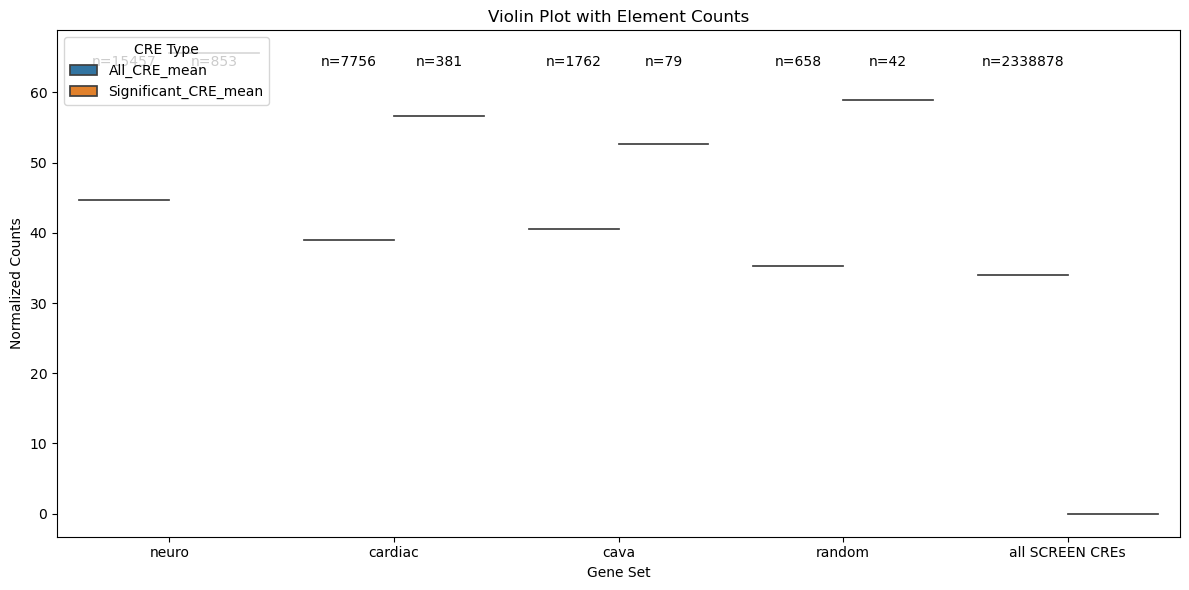

In [188]:

# --- Start of new/updated plotting section ---
fig, ax = plt.subplots(figsize=(12, 6))

# Use violinplot to create the plot on the specified axes
sns.violinplot(
    x='Gene_Set',
    y='Value',
    hue='Type',
    data=df_long,
    split=True,
    inner="quart",
    ax=ax
)

# Annotate with the counts
x_positions = [0, 1, 2, 3, 4] # Corresponds to the order of Gene_Sets
bar_width = 0.4 # Adjust this value if the violins are too wide or narrow

for i, gene_set in enumerate(summary_data['Gene_Set'].to_list()):
    all_count = summary_data.loc[summary_data['Gene_Set'] == gene_set, 'All_Count'].iloc[0]
    sig_count = summary_data.loc[summary_data['Gene_Set'] == gene_set, 'Significant_Count'].iloc[0]

    # Position for 'All CREs' violin
    all_pos = x_positions[i] - bar_width / 2.0
    ax.text(all_pos, ax.get_ylim()[1] * 0.95, f'n={all_count}',
            ha='center', va='top', fontsize=10, color='black')

    # Position for 'Significant CREs' violin (if it exists)
    if sig_count > 0:
        sig_pos = x_positions[i] + bar_width / 2.0
        ax.text(sig_pos, ax.get_ylim()[1] * 0.95, f'n={sig_count}',
                ha='center', va='top', fontsize=10, color='black')

# Final plot adjustments
ax.set_xlabel('Gene Set')
ax.set_ylabel('Normalized Counts')
ax.set_title('Violin Plot with Element Counts')
ax.legend(title='CRE Type', loc='upper left')

plt.tight_layout()
plt.show()

##### Tried different ways of plotting this information:
- without using the split between significant and not significant

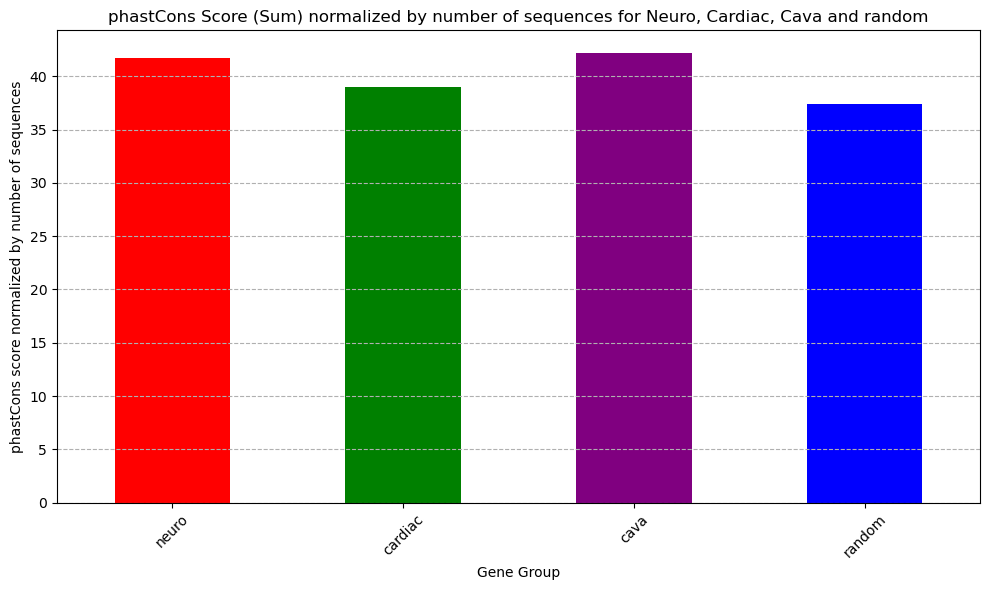

In [75]:
# Define the groups we are interested in.
groups = ['neuro', 'cardiac', 'cava', 'random']

group_sums = {}
for group in groups:
    filtered_df = tested_cre_activity_remap_tfbs_occurences_phastCons[tested_cre_activity_remap_tfbs_occurences_phastCons['gene_set'].apply(lambda x: group in x)]
    group_sums[group] = filtered_df['sum'].sum() / filtered_df.shape[0]

# Convert the dictionary to a Series for easy plotting.
plot_data = pd.Series(group_sums)

# Create a bar plot.
plt.figure(figsize=(10, 6))
plot_data.plot(kind='bar', color=['red', 'green', 'purple', 'blue'])
plt.title('phastCons Score (Sum) normalized by number of sequences for Neuro, Cardiac, Cava and random')
plt.xlabel('Gene Group')
plt.ylabel('phastCons score normalized by number of sequences')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()


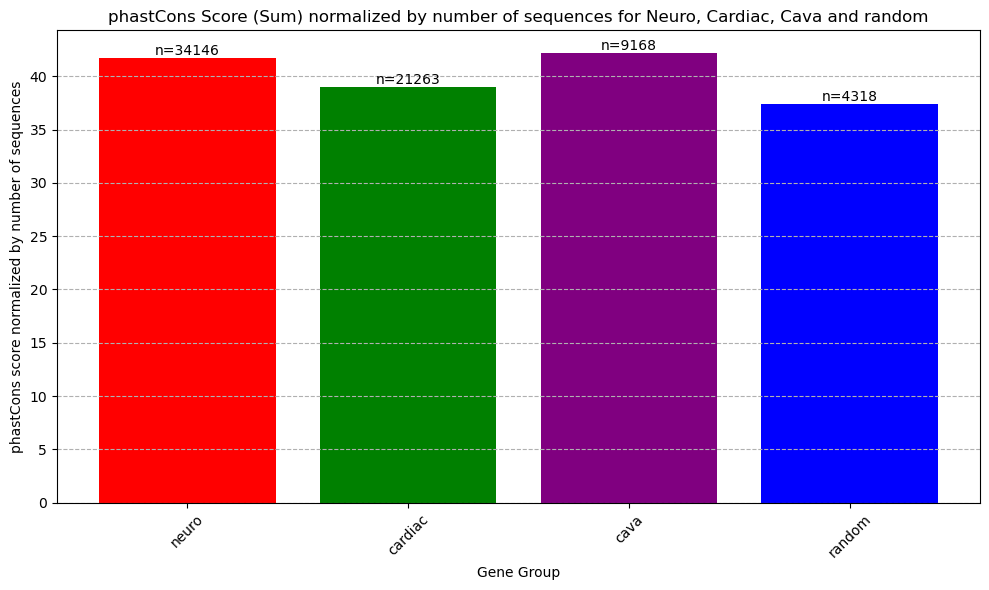

In [76]:
group_sums = {}
group_counts = {}

# Calculate the sum and count for each group using the .apply() method.
for group in groups:
    # Filter the DataFrame for the current group
    filtered_df = tested_cre_activity_remap_tfbs_occurences_phastCons[
        tested_cre_activity_remap_tfbs_occurences_phastCons['gene_set'].apply(lambda x: group in x)
    ]
    # Store the sum and count
    group_sums[group] = filtered_df['sum'].sum() / filtered_df.shape[0]
    group_counts[group] = len(filtered_df)

# Create a DataFrame for plotting, making it easier to manage both sum and count
plot_data = pd.DataFrame({
    'Gene_Set': groups,
    'Sum_phastCons': [group_sums[g] for g in groups],
    'Count': [group_counts[g] for g in groups]
})

# Create the bar plot.
fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ['red', 'green', 'purple', 'blue']
bars = ax.bar(plot_data['Gene_Set'], plot_data['Sum_phastCons'], color=bar_colors)

# Add group sizes as text labels on top of each bar
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height,
            f'n={plot_data["Count"].iloc[i]}',
            ha='center', va='bottom')

plt.title('phastCons Score (Sum) normalized by number of sequences for Neuro, Cardiac, Cava and random')
plt.xlabel('Gene Group')
plt.ylabel('phastCons score normalized by number of sequences')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()

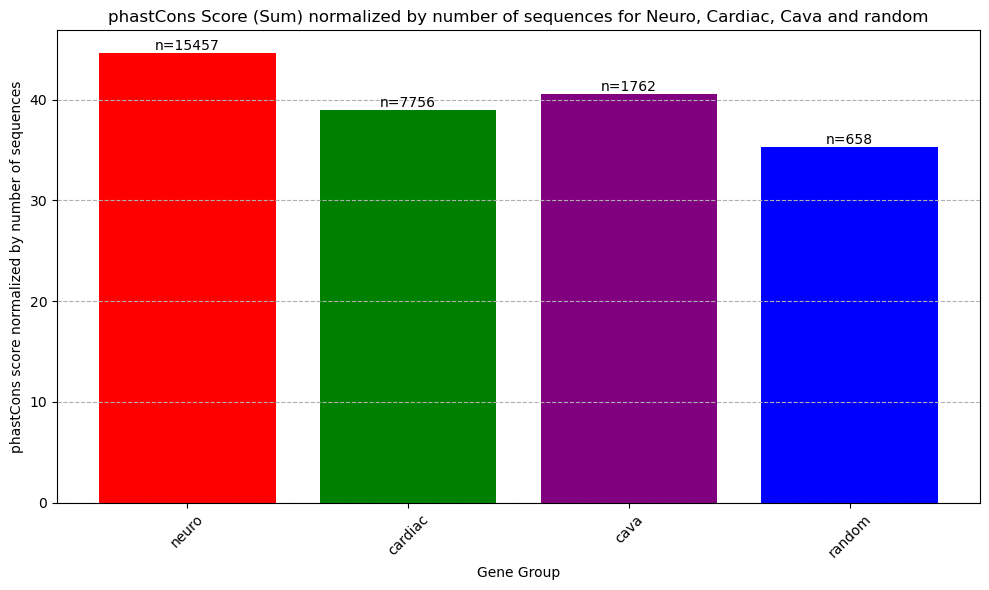

In [77]:
group_sums = {}
group_counts = {}

# Calculate the sum and count for each group using the .apply() method.
for group in groups:
    # Filter the DataFrame for the current group
    filtered_df = REF_tested_cre_activity_remap_tfbs_occurences_phastCons[
        REF_tested_cre_activity_remap_tfbs_occurences_phastCons['gene_set'].apply(lambda x: group in x)
    ]
    # Store the sum and count
    group_sums[group] = filtered_df['sum'].sum() / filtered_df.shape[0]
    group_counts[group] = len(filtered_df)

# Create a DataFrame for plotting, making it easier to manage both sum and count
plot_data = pd.DataFrame({
    'Gene_Set': groups,
    'Sum_phastCons': [group_sums[g] for g in groups],
    'Count': [group_counts[g] for g in groups]
})

# Create the bar plot.
fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ['red', 'green', 'purple', 'blue']
bars = ax.bar(plot_data['Gene_Set'], plot_data['Sum_phastCons'], color=bar_colors)

# Add group sizes as text labels on top of each bar
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height,
            f'n={plot_data["Count"].iloc[i]}',
            ha='center', va='bottom')

plt.title('phastCons Score (Sum) normalized by number of sequences for Neuro, Cardiac, Cava and random')
plt.xlabel('Gene Group')
plt.ylabel('phastCons score normalized by number of sequences')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()

In [78]:
tested_cre_activity_remap_tfbs_occurences_phastCons.columns

Index(['chrom', 'start', 'end', 'name', 'strand', 'TFBS_list',
       'number_of_TFBS', 'n_unique_TFBS', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'gene_name',
       'gene_set', 'SCREEN_ID', 'is_NPC_SCREEN_cCRE', 'is_H9_SCREEN_cCRE',
       'is_H1_SCREEN_cCRE', 'is_neural_stem_SCREEN_cCRE',
       'is_excitatory_neuron_SCREEN_cCRE', 'covered_size', 'sum', 'mean0',
       'mean'],
      dtype='object')

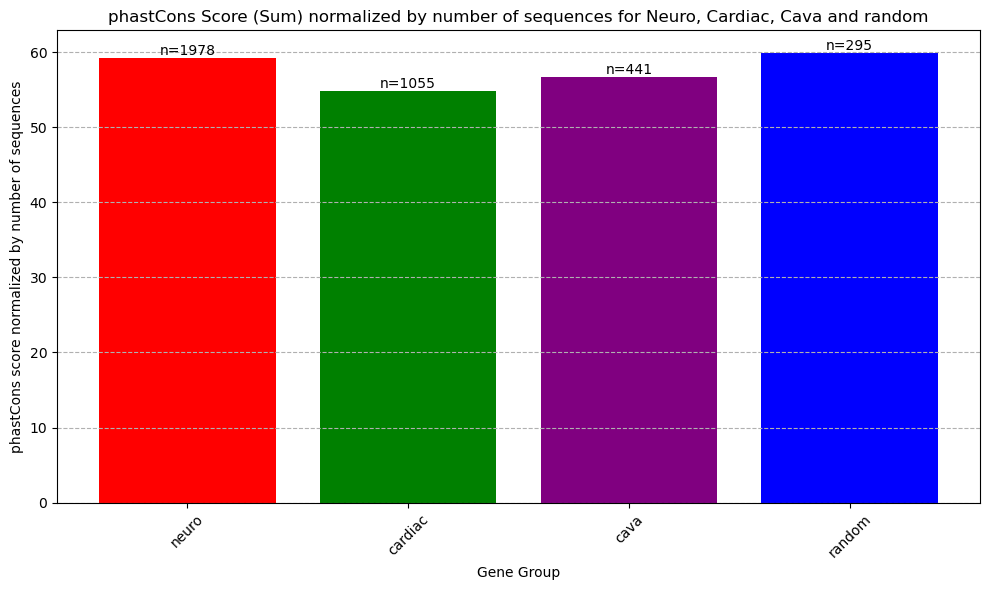

In [79]:
##### Check for significant CREs
tested_cre_activity_remap_tfbs_occurences_phastCons_significant_active = tested_cre_activity_remap_tfbs_occurences_phastCons[
    tested_cre_activity_remap_tfbs_occurences_phastCons['bcalm_element_adjusted_p_value'] < significance_threshold
]

group_sums = {}
group_counts = {}

# Calculate the sum and count for each group using the .apply() method.
for group in groups:
    # Filter the DataFrame for the current group
    filtered_df = tested_cre_activity_remap_tfbs_occurences_phastCons_significant_active[
        tested_cre_activity_remap_tfbs_occurences_phastCons_significant_active['gene_set'].apply(lambda x: group in x)
    ]
    # Store the sum and count
    group_sums[group] = filtered_df['sum'].sum() / filtered_df.shape[0]
    group_counts[group] = len(filtered_df)

# Create a DataFrame for plotting, making it easier to manage both sum and count
plot_data = pd.DataFrame({
    'Gene_Set': groups,
    'Sum_phastCons': [group_sums[g] for g in groups],
    'Count': [group_counts[g] for g in groups]
})

# Create the bar plot.
fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ['red', 'green', 'purple', 'blue']
bars = ax.bar(plot_data['Gene_Set'], plot_data['Sum_phastCons'], color=bar_colors)

# Add group sizes as text labels on top of each bar
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height,
            f'n={plot_data["Count"].iloc[i]}',
            ha='center', va='bottom')

plt.title('phastCons Score (Sum) normalized by number of sequences for Neuro, Cardiac, Cava and random')
plt.xlabel('Gene Group')
plt.ylabel('phastCons score normalized by number of sequences')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()

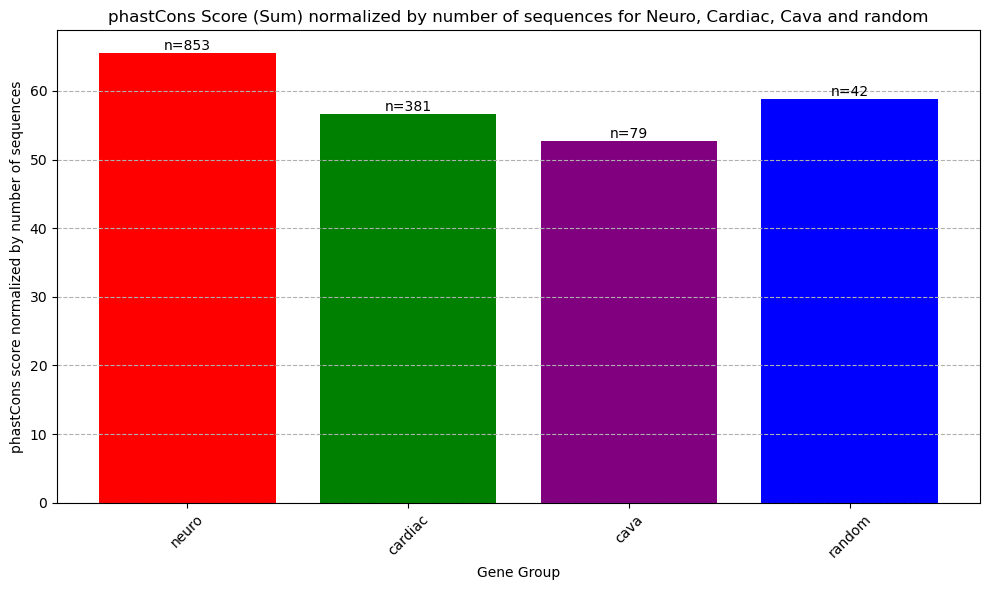

In [80]:
REF_tested_cre_activity_remap_tfbs_occurences_phastCons

##### Check for significant CREs
REF_tested_cre_activity_remap_tfbs_occurences_phastCons_significant_active = REF_tested_cre_activity_remap_tfbs_occurences_phastCons[
    REF_tested_cre_activity_remap_tfbs_occurences_phastCons['bcalm_element_adjusted_p_value'] < significance_threshold
]

group_sums = {}
group_counts = {}

# Calculate the sum and count for each group using the .apply() method.
for group in groups:
    # Filter the DataFrame for the current group
    filtered_df = REF_tested_cre_activity_remap_tfbs_occurences_phastCons_significant_active[
        REF_tested_cre_activity_remap_tfbs_occurences_phastCons_significant_active['gene_set'].apply(lambda x: group in x)
    ]
    # Store the sum and count
    group_sums[group] = filtered_df['sum'].sum() / filtered_df.shape[0]
    group_counts[group] = len(filtered_df)

# Create a DataFrame for plotting, making it easier to manage both sum and count
plot_data = pd.DataFrame({
    'Gene_Set': groups,
    'Sum_phastCons': [group_sums[g] for g in groups],
    'Count': [group_counts[g] for g in groups]
})

# Create the bar plot.
fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ['red', 'green', 'purple', 'blue']
bars = ax.bar(plot_data['Gene_Set'], plot_data['Sum_phastCons'], color=bar_colors)

# Add group sizes as text labels on top of each bar
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height,
            f'n={plot_data["Count"].iloc[i]}',
            ha='center', va='bottom')

plt.title('phastCons Score (Sum) normalized by number of sequences for Neuro, Cardiac, Cava and random')
plt.xlabel('Gene Group')
plt.ylabel('phastCons score normalized by number of sequences')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()

In [81]:
significant_sequences = tested_cre_activity_remap_tfbs_occurences_phastCons[
    tested_cre_activity_remap_tfbs_occurences_phastCons['bcalm_element_adjusted_p_value'] < significance_threshold
]

,Gene_Set,n_significant,n_total,Proportion_Significant
0,neuro,1978,34146,0.057928
1,cardiac,1055,21263,0.049617
2,cava,441,9168,0.048102
3,random,295,4318,0.068319


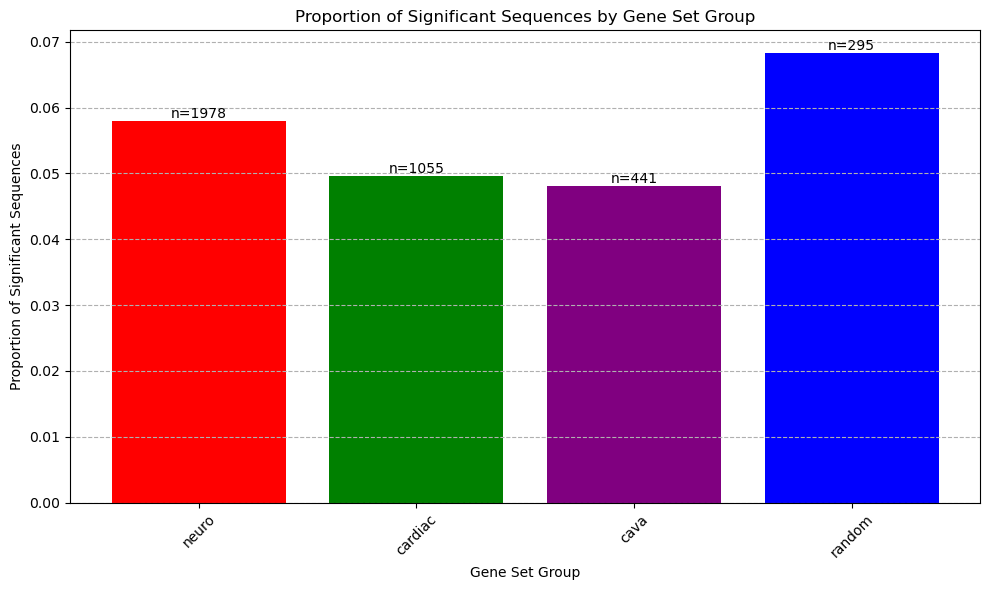

In [82]:
groups = ['neuro', 'cardiac', 'cava', 'random']

# Calculate the proportion of significant sequences for each group
proportions = {}
significant_counts = {}
total_counts = {}
for group in groups:
    total_count = len(tested_cre_activity_remap_tfbs_occurences_phastCons[
        tested_cre_activity_remap_tfbs_occurences_phastCons['gene_set'].apply(lambda x: group in x)
    ])
    significant_count = len(tested_cre_activity_remap_tfbs_occurences_phastCons_significant_active[
        tested_cre_activity_remap_tfbs_occurences_phastCons_significant_active['gene_set'].apply(lambda x: group in x)
    ])
    if total_count > 0:
        significant_counts[group] = significant_count
        total_counts[group] = total_count
        proportions[group] = significant_count / total_count
    else:
        proportions[group] = 0

# Create a DataFrame for the new plot
plot_data_proportions = pd.DataFrame({
    'Gene_Set': groups,
    'n_significant': [significant_counts[g] for g in groups],
    'n_total': [total_counts[g] for g in groups],
    'Proportion_Significant': [proportions[g] for g in groups]
})

# Create the bar plot for proportions
fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ['red', 'green', 'purple', 'blue']
bars = ax.bar(plot_data_proportions['Gene_Set'], plot_data_proportions['Proportion_Significant'], color=bar_colors)

# Add group counts as text labels on top of each bar
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height,
            f'n={significant_counts[plot_data_proportions["Gene_Set"].iloc[i]]}',
            ha='center', va='bottom')

ax.set_title('Proportion of Significant Sequences by Gene Set Group')
ax.set_xlabel('Gene Set Group')
ax.set_ylabel('Proportion of Significant Sequences')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plot_data_proportions

In [83]:
correlation = tested_cre_activity_remap_tfbs_occurences_phastCons['bcalm_element_log_ratio_activity'].corr(
    tested_cre_activity_remap_tfbs_occurences_phastCons['mean']
)
print(f"The Pearson correlation coefficient between element activity and phastCons mean score is: {correlation}")


The Pearson correlation coefficient between element activity and phastCons mean score is: 0.02278895002115022


In [84]:
correlation = tested_cre_activity_remap_tfbs_occurences_phastCons_significant_active['bcalm_element_log_ratio_activity'].corr(
    tested_cre_activity_remap_tfbs_occurences_phastCons_significant_active['mean']
)
print(f"The Pearson correlation coefficient between element activity and phastCons mean score is: {correlation}")


The Pearson correlation coefficient between element activity and phastCons mean score is: 0.023709941087317152


In [85]:
REF_tested_cre_activity_remap_tfbs_occurences_phastCons["gene_set"].value_counts()

gene_set
[neuro]                   14521
[cardiac]                  6873
[cava]                     1501
[neuro, cardiac]            772
[random]                    658
[neuro, cava]               150
[cava, cardiac]              97
[neuro, cava, cardiac]       14
Name: count, dtype: int64

In [86]:
groups

['neuro', 'cardiac', 'cava', 'random']

In [87]:
group_counts

{'neuro': 853, 'cardiac': 381, 'cava': 79, 'random': 42}

,Gene_Set,n_significant,n_total,Proportion_Significant
0,neuro,853,15457,0.055185
1,cardiac,381,7756,0.049123
2,cava,79,1762,0.044835
3,random,42,658,0.063830


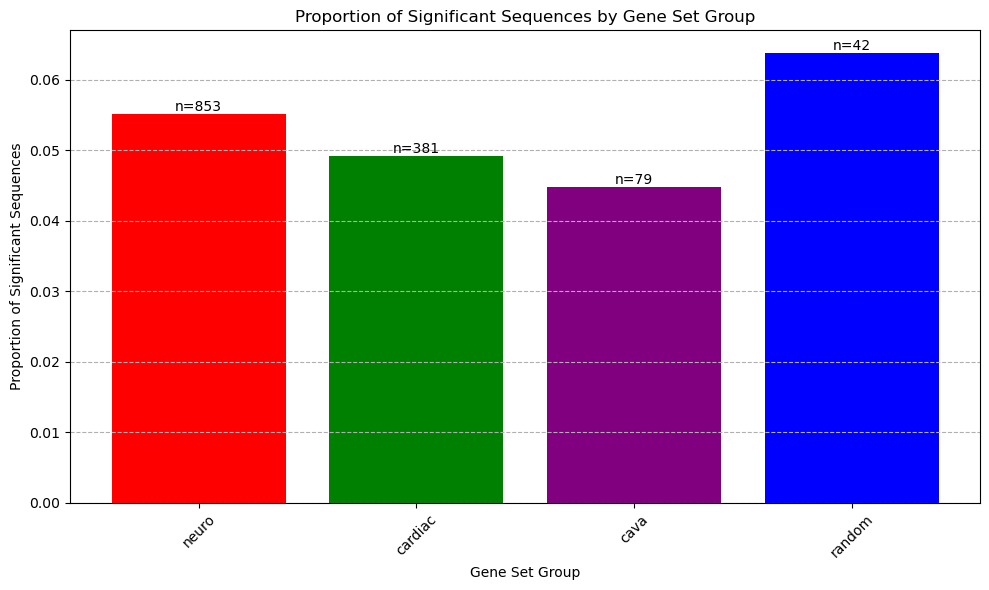

In [88]:
groups = ['neuro', 'cardiac', 'cava', 'random']

##### Check for significant CREs
REF_tested_cre_activity_remap_tfbs_occurences_phastCons_significant_active = REF_tested_cre_activity_remap_tfbs_occurences_phastCons[
    REF_tested_cre_activity_remap_tfbs_occurences_phastCons['bcalm_element_adjusted_p_value'] < significance_threshold
]

# Calculate the proportion of significant sequences for each group
proportions = {}
significant_counts = {}
total_counts = {}
for group in groups:
    total_count = len(REF_tested_cre_activity_remap_tfbs_occurences_phastCons[
        REF_tested_cre_activity_remap_tfbs_occurences_phastCons['gene_set'].apply(lambda x: group in x)
    ])
    significant_count = len(REF_tested_cre_activity_remap_tfbs_occurences_phastCons_significant_active[
        REF_tested_cre_activity_remap_tfbs_occurences_phastCons_significant_active['gene_set'].apply(lambda x: group in x)
    ])
    if total_count > 0:
        significant_counts[group] = significant_count
        total_counts[group] = total_count
        proportions[group] = significant_count / total_count
    else:
        proportions[group] = 0

# Create a DataFrame for the new plot
plot_data_proportions = pd.DataFrame({
    'Gene_Set': groups,
    'n_significant': [significant_counts[g] for g in groups],
    'n_total': [total_counts[g] for g in groups],
    'Proportion_Significant': [proportions[g] for g in groups]
})

# Create the bar plot for proportions
fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ['red', 'green', 'purple', 'blue']
bars = ax.bar(plot_data_proportions['Gene_Set'], plot_data_proportions['Proportion_Significant'], color=bar_colors)

# Add group counts as text labels on top of each bar
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height,
            f'n={significant_counts[plot_data_proportions["Gene_Set"].iloc[i]]}',
            ha='center', va='bottom')

ax.set_title('Proportion of Significant Sequences by Gene Set Group')
ax.set_xlabel('Gene Set Group')
ax.set_ylabel('Proportion of Significant Sequences')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plot_data_proportions

In [89]:
REF_tested_cre_activity_remap_tfbs_occurences_phastCons_significant_active

,chrom,start,end,name,strand,TFBS_list,number_of_TFBS,n_unique_TFBS,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,...,SCREEN_ID,is_NPC_SCREEN_cCRE,is_H9_SCREEN_cCRE,is_H1_SCREEN_cCRE,is_neural_stem_SCREEN_cCRE,is_excitatory_neuron_SCREEN_cCRE,covered_size,sum,mean0,mean
56,chr1,10731538,10731808,cardiac_neuro_cava_random:REF_CASZ1|ENSG000001...,-,"[KMT2B-D, TCF7L2, PHIP, SMARCC1, FOS, ZBTB42, ...",9,9,6.906070e-03,-0.086371,...,EH38E2785771,False,False,False,False,False,270,17.616,0.065244,0.065244
78,chr1,10766124,10766394,cardiac_neuro_cava_random:REF_CASZ1|ENSG000001...,-,"[CREB1, SMC3, BAF155, ZEB2, ZNF398, MYCN, ASH2...",66,64,1.684775e-03,-0.095320,...,EH38E2785823,False,False,False,False,False,270,13.665,0.050611,0.050611
100,chr1,10831012,10831282,cardiac_neuro_cava_random:REF_CASZ1|ENSG000001...,-,"[CUX1, KLF3, PARP1, KLF17, KMT2B, BRD2, CREBBP...",105,104,1.371433e-02,-0.111296,...,EH38E1318419,False,False,False,False,False,270,111.396,0.412578,0.412578
110,chr1,110593905,110594175,cardiac_neuro_cava_random:REF_KCNA2|ENSG000001...,-,"[EBF1, EP300, ZNF300, RFX1, BRD4, MYBL2, MYCN,...",13,13,1.273833e-03,0.100690,...,EH38E1375827,False,False,False,False,False,270,255.370,0.945815,0.945815
126,chr1,110643954,110644224,cardiac_neuro_cava_random:REF_KCNA2|ENSG000001...,-,"[EP300, IKZF1, IKZF2, NFATC3, CTCF, JMJD1C, CA...",43,43,1.405912e-08,0.104314,...,EH38E2830583,False,False,False,False,False,270,79.364,0.293941,0.293941
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24489,chrX,5856413,5856683,cardiac_neuro_cava_random:REF_NLGN4X|ENSG00000...,-,"[PGR, CEBPA, FOXA1, CEBPA]",4,3,2.776444e-04,0.082066,...,EH38E3923778,False,False,False,False,False,270,1.134,0.004200,0.004200
24498,chrX,6005146,6005416,cardiac_neuro_cava_random:NLGN4X|ENSG000001469...,-,[NOTCH1],1,1,2.188866e-07,-0.095807,...,EH38E3923797,False,False,False,False,False,270,0.494,0.001830,0.001830
24536,chrX,71119705,71119975,cardiac_neuro_cava_random:REF_NLGN3|ENSG000001...,+,"[BRD4, RAD21, ZNF3, ARNTL]",4,4,6.853798e-03,-0.094856,...,EH38E3937029,False,False,False,False,False,270,175.739,0.650885,0.650885
24554,chrX,71177363,71177633,cardiac_neuro_cava_random:NLGN3|ENSG0000019633...,+,"[PHOX2B, MEIS2, PBX2, SMARCA4, FOS, SMARCE1, K...",41,41,8.231748e-03,0.078647,...,EH38E2758028,False,False,False,False,False,270,136.060,0.503926,0.503926


In [90]:
REF_tested_cre_activity_remap_tfbs_occurences_phastCons["is_neuro_active_SCREEN"] = REF_tested_cre_activity_remap_tfbs_occurences_phastCons["is_excitatory_neuron_SCREEN_cCRE"] | REF_tested_cre_activity_remap_tfbs_occurences_phastCons["is_NPC_SCREEN_cCRE"]
# REF_tested_cre_activity_remap_tfbs_occurences_phastCons["is_neuro_active_SCREEN"] = REF_tested_cre_activity_remap_tfbs_occurences_phastCons["is_excitatory_neuron_SCREEN_cCRE"]
# REF_tested_cre_activity_remap_tfbs_occurences_phastCons["is_neuro_active_SCREEN"] = REF_tested_cre_activity_remap_tfbs_occurences_phastCons["is_NPC_SCREEN_cCRE"]
REF_tested_cre_activity_remap_tfbs_occurences_phastCons["is_neuro_active_SCREEN"].sum()

1410

,Gene_Set,n_neuro_active_SCREEN,n_total,Proportion_neuro_active_SCREEN
0,neuro,853,15457,0.054344
1,cardiac,381,7756,0.069624
2,cava,79,1762,0.049376
3,random,42,658,0.042553


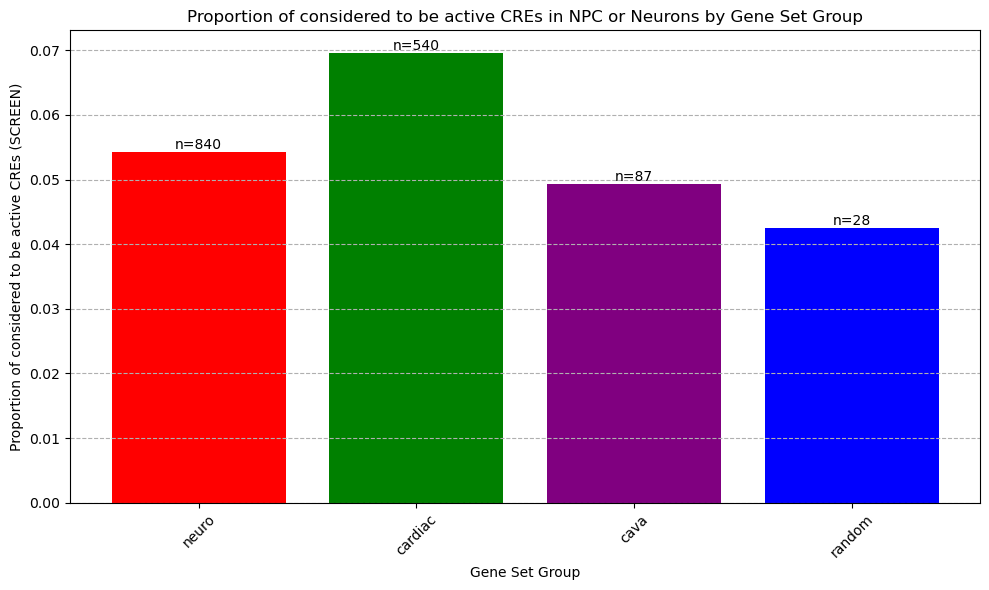

In [91]:
# proprotion of overlapping with CREs in cell-type of interest
groups = ['neuro', 'cardiac', 'cava', 'random']

##### Check for neuro_active_SCREEN CREs
REF_tested_cre_activity_remap_tfbs_occurences_phastCons_neuro_active_SCREEN = REF_tested_cre_activity_remap_tfbs_occurences_phastCons.loc[
    REF_tested_cre_activity_remap_tfbs_occurences_phastCons["is_neuro_active_SCREEN"] == True
].copy()

# Calculate the proportion of neuro_active_SCREEN sequences for each group
proportions = {}
neuro_active_SCREEN_counts = {}
total_counts = {}
for group in groups:
    total_count = len(REF_tested_cre_activity_remap_tfbs_occurences_phastCons[
        REF_tested_cre_activity_remap_tfbs_occurences_phastCons['gene_set'].apply(lambda x: group in x)
    ])
    neuro_active_SCREEN_count = len(REF_tested_cre_activity_remap_tfbs_occurences_phastCons_neuro_active_SCREEN[
        REF_tested_cre_activity_remap_tfbs_occurences_phastCons_neuro_active_SCREEN['gene_set'].apply(lambda x: group in x)
    ])
    if total_count > 0:
        neuro_active_SCREEN_counts[group] = neuro_active_SCREEN_count
        total_counts[group] = total_count
        proportions[group] = neuro_active_SCREEN_count / total_count
    else:
        proportions[group] = 0

# Create a DataFrame for the new plot
plot_data_proportions = pd.DataFrame({
    'Gene_Set': groups,
    'n_neuro_active_SCREEN': [significant_counts[g] for g in groups],
    'n_total': [total_counts[g] for g in groups],
    'Proportion_neuro_active_SCREEN': [proportions[g] for g in groups]
})

# Create the bar plot for proportions
fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ['red', 'green', 'purple', 'blue']
bars = ax.bar(plot_data_proportions['Gene_Set'], plot_data_proportions['Proportion_neuro_active_SCREEN'], color=bar_colors)

# Add group counts as text labels on top of each bar
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height,
            f'n={neuro_active_SCREEN_counts[plot_data_proportions["Gene_Set"].iloc[i]]}',
            ha='center', va='bottom')

ax.set_title('Proportion of considered to be active CREs in NPC or Neurons by Gene Set Group')
ax.set_xlabel('Gene Set Group')
ax.set_ylabel('Proportion of considered to be active CREs (SCREEN)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plot_data_proportions

#### Investigate the correlation of phastCons and the MPRA activity

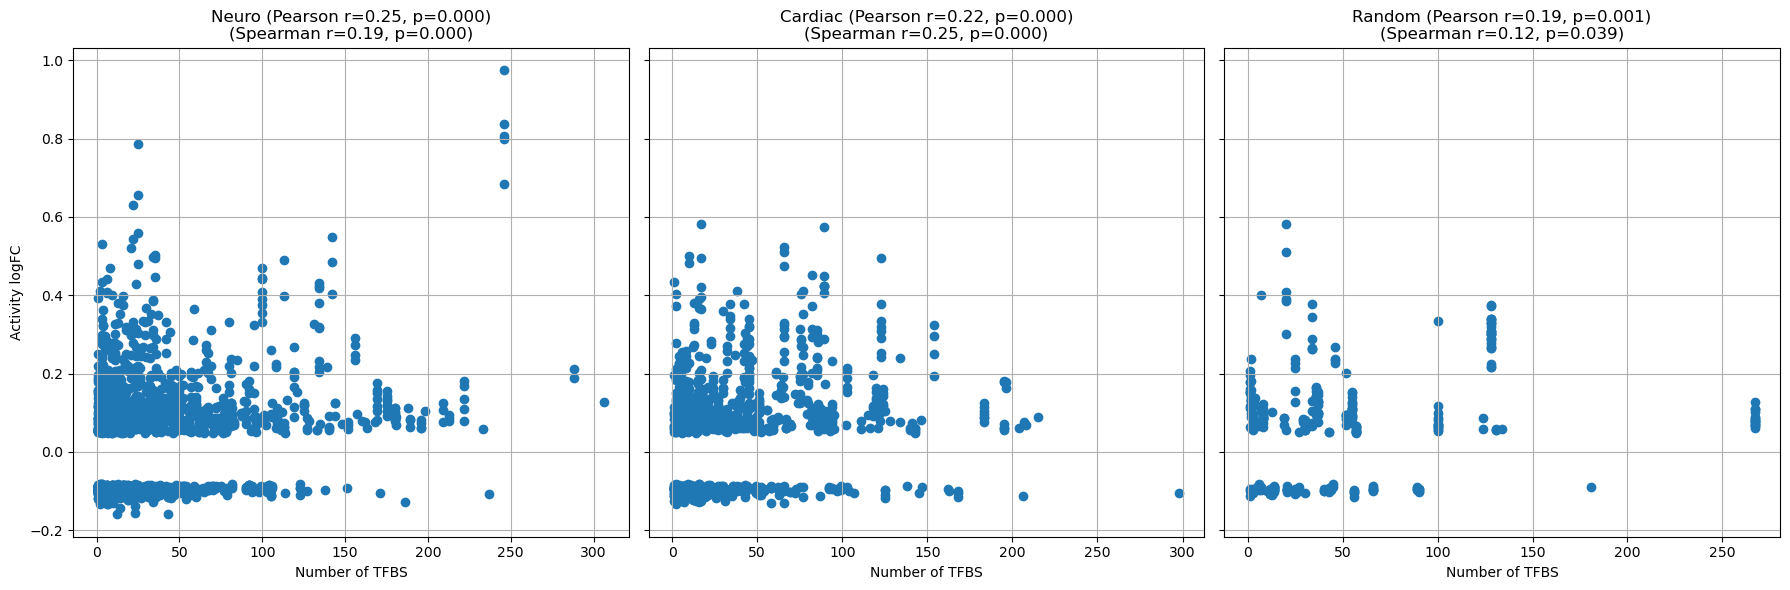

In [92]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# Define the groups to analyze
groups = ['neuro', 'cardiac', 'random']
fig, axes = plt.subplots(1, len(groups), figsize=(18, 6), sharey=True)

for i, group in enumerate(groups):
    # Filter the dataframe for the current group and where activity data exists
    df_group = tested_cre_activity_remap_tfbs_occurences_phastCons_significant_active[
        tested_cre_activity_remap_tfbs_occurences_phastCons_significant_active['gene_set'].apply(lambda x: group in x) &
        (tested_cre_activity_remap_tfbs_occurences_phastCons_significant_active['bcalm_data_exists'] == True)
    ]

    ax = axes[i]

    if len(df_group) < 2:
        ax.set_title(f"Not enough data for '{group.capitalize()}'")
        ax.set_xlabel('Number of TFBS')
        ax.set_ylabel('Activity logFC')
        continue

    # Calculate both Pearson and Spearman correlation coefficients
    pearson_corr, pearson_p = pearsonr(df_group['number_of_TFBS'], df_group['bcalm_element_log_ratio_activity'])
    spearman_corr, spearman_p = spearmanr(df_group['number_of_TFBS'], df_group['bcalm_element_log_ratio_activity'])

    # Create a scatter plot
    ax.scatter(df_group['number_of_TFBS'], df_group['bcalm_element_log_ratio_activity'])

    ax.set_xlabel('Number of TFBS')
    ax.set_title(
        f'{group.capitalize()} (Pearson r={pearson_corr:.2f}, p={pearson_p:.3f})\n'
        f'(Spearman r={spearman_corr:.2f}, p={spearman_p:.3f})'
    )
    ax.grid(True)

# Set a common y-axis label for the entire figure
axes[0].set_ylabel('Activity logFC')

plt.tight_layout()
plt.show()

### Correlation Conservation and MPRA activity: 


In [93]:
REF_tested_cre_activity_remap_tfbs_occurences_phastCons.columns

Index(['chrom', 'start', 'end', 'name', 'strand', 'TFBS_list',
       'number_of_TFBS', 'n_unique_TFBS', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'gene_name',
       'gene_set', 'SCREEN_ID', 'is_NPC_SCREEN_cCRE', 'is_H9_SCREEN_cCRE',
       'is_H1_SCREEN_cCRE', 'is_neural_stem_SCREEN_cCRE',
       'is_excitatory_neuron_SCREEN_cCRE', 'covered_size', 'sum', 'mean0',
       'mean', 'is_neuro_active_SCREEN'],
      dtype='object')

In [94]:
REF_tested_cre_activity_remap_tfbs_occurences_phastCons_exists = REF_tested_cre_activity_remap_tfbs_occurences_phastCons.loc[REF_tested_cre_activity_remap_tfbs_occurences_phastCons["covered_size"] > 200].copy()
REF_tested_cre_activity_remap_tfbs_occurences_phastCons_exists

,chrom,start,end,name,strand,TFBS_list,number_of_TFBS,n_unique_TFBS,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,...,is_NPC_SCREEN_cCRE,is_H9_SCREEN_cCRE,is_H1_SCREEN_cCRE,is_neural_stem_SCREEN_cCRE,is_excitatory_neuron_SCREEN_cCRE,covered_size,sum,mean0,mean,is_neuro_active_SCREEN
0,chr1,10588680,10588950,cardiac_neuro_cava_random:REF_CASZ1|ENSG000001...,-,[MAFF],1,1,1.0,0.015284,...,False,False,False,False,False,270,59.714,0.221163,0.221163,False
1,chr1,10594736,10595006,cardiac_neuro_cava_random:REF_CASZ1|ENSG000001...,-,"[RBPJ, MEF2B, TFAP2C, SND1, ZNF263, POU5F1, SM...",24,24,1.0,0.018937,...,False,True,False,False,False,270,48.146,0.178319,0.178319,False
2,chr1,10597875,10598145,cardiac_neuro_cava_random:CASZ1|ENSG0000013094...,-,"[SMARCC1, KLF4, TFAP2C, EZH2, RBBP4, SS18, MYC...",13,13,1.0,-0.052969,...,False,False,False,False,False,270,131.888,0.488474,0.488474,False
3,chr1,10599192,10599462,cardiac_neuro_cava_random:CASZ1|ENSG0000013094...,-,"[EGR1, CREBBP, ZNF44, HOXA3, ARID2, MED1, ZBTB...",133,130,1.0,-0.029333,...,False,False,False,False,False,270,136.565,0.505796,0.505796,False
4,chr1,10601429,10601699,cardiac_neuro_cava_random:CASZ1|ENSG0000013094...,-,"[KMT2A, RAD21, ZNF3, NR3C1, ZNF550, MYCN, NKX2...",13,13,1.0,-0.070292,...,False,False,False,False,False,270,1.344,0.004978,0.004978,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24581,chrX,77784045,77784315,cardiac_neuro_cava_random:ATRX|ENSG00000085224...,-,"[CRX, MEF2D, OTX2, SMARCA4, TBX21, RBFOX2, BCL...",9,9,1.0,-0.039769,...,False,False,False,False,False,270,31.674,0.117311,0.117311,False
24582,chrX,77786807,77787077,cardiac_neuro_cava_random:REF_ATRX|ENSG0000008...,-,"[ZSCAN4, FOXA1, RFX5, SPI1, ZBTB2, SPIB, KDM1A...",8,8,1.0,0.035090,...,False,False,False,False,False,270,23.489,0.086996,0.086996,False
24583,chrX,77787587,77787857,cardiac_neuro_cava_random:ATRX|ENSG00000085224...,-,"[BRD4, ZGPAT, HAND2, PHOX2B, ZBED4, TEAD4, SRE...",9,9,1.0,-0.010949,...,False,False,False,False,False,270,51.820,0.191926,0.191926,False
24584,chrX,77788137,77788407,cardiac_neuro_cava_random:ATRX|ENSG00000085224...,-,"[LIN54, SREBP2, MYBL2, FOXA2, ZNF24, KLF4, NFY...",45,45,1.0,-0.031196,...,False,False,False,False,False,270,45.817,0.169693,0.169693,False


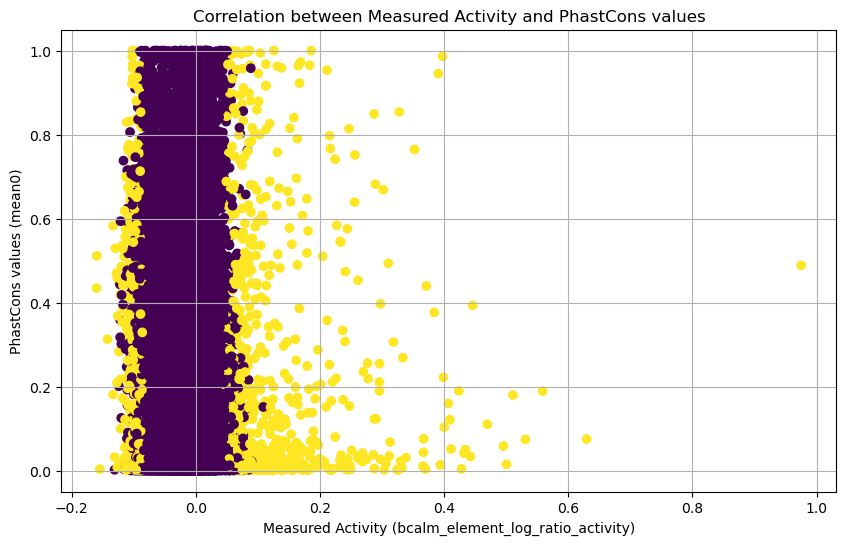

In [95]:
# Create a new column to label sequences as 'significant' or 'not significant'
REF_tested_cre_activity_remap_tfbs_occurences_phastCons_exists['significant'] = REF_tested_cre_activity_remap_tfbs_occurences_phastCons_exists['bcalm_element_adjusted_p_value'] <= significance_threshold

# Generate the scatter plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    x=REF_tested_cre_activity_remap_tfbs_occurences_phastCons_exists['bcalm_element_log_ratio_activity'],
    y=REF_tested_cre_activity_remap_tfbs_occurences_phastCons_exists['mean0'],
    c=REF_tested_cre_activity_remap_tfbs_occurences_phastCons_exists['significant'],
    cmap='viridis'
)

plt.xlabel('Measured Activity (bcalm_element_log_ratio_activity)')
plt.ylabel('PhastCons values (mean0)')
plt.title('Correlation between Measured Activity and PhastCons values')
plt.grid(True)



In [96]:
REF_tested_cre_activity_remap_tfbs_occurences_phastCons['mean0'].describe()

count    24586.000000
mean         0.158692
std          0.230490
min          0.000000
25%          0.011974
50%          0.048396
75%          0.202643
max          1.000000
Name: mean0, dtype: float64

Pearson Correlation Coefficient: 0.0038
Pearson P-value: 0.5503
Spearman Correlation Coefficient: 0.0198
Spearman P-value: 0.0020


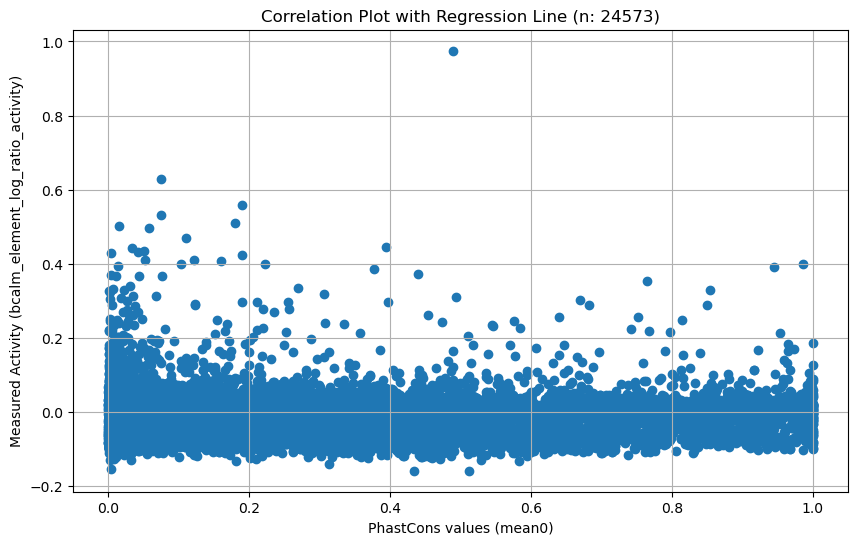

In [97]:
from scipy import stats
# activity threshold:
activity_threshold = 0.14
activity_threshold =  REF_tested_cre_activity_remap_tfbs_occurences_phastCons['bcalm_element_log_ratio_activity'].min()
REF_tested_cre_activity_remap_tfbs_occurences_phastCons_active = REF_tested_cre_activity_remap_tfbs_occurences_phastCons.loc[
    REF_tested_cre_activity_remap_tfbs_occurences_phastCons['bcalm_element_log_ratio_activity'] > activity_threshold
]
conservation_threshold = 0.2
conservation_threshold = REF_tested_cre_activity_remap_tfbs_occurences_phastCons['mean0'].min()
REF_tested_cre_activity_remap_tfbs_occurences_phastCons_active = REF_tested_cre_activity_remap_tfbs_occurences_phastCons.loc[
    REF_tested_cre_activity_remap_tfbs_occurences_phastCons['mean0'] > conservation_threshold
]

# Extract the data for plotting
x = REF_tested_cre_activity_remap_tfbs_occurences_phastCons_active['mean0']
y = REF_tested_cre_activity_remap_tfbs_occurences_phastCons_active['bcalm_element_log_ratio_activity']

# Calculate the Pearson correlation coefficient and p-value
pearson_corr, pearson_p_value = stats.pearsonr(x,y)

# Calculate the Spearman correlation coefficient and p-value
spearman_corr, spearman_p_value = stats.spearmanr(x,y)

print(f"Pearson Correlation Coefficient: {pearson_corr:.4f}")
print(f"Pearson P-value: {pearson_p_value:.4f}")
print(f"Spearman Correlation Coefficient: {spearman_corr:.4f}")
print(f"Spearman P-value: {spearman_p_value:.4f}")

# Calculate linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

# Create the plot
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label='Data Points')

# Plot the regression line
# plt.plot(x, intercept + slope * x, 'r', label=f'Linear Fit: $r={r_value:.2f}$')

# Add labels and title
plt.xlabel('PhastCons values (mean0)')
plt.ylabel('Measured Activity (bcalm_element_log_ratio_activity)')
plt.title(f'Correlation Plot with Regression Line (n: {REF_tested_cre_activity_remap_tfbs_occurences_phastCons_active.shape[0]})')
# plt.legend()
plt.grid(True)

In [98]:
def correlation_of_phastCons_vs_mpra_activity(cre_activity_tfbs_df,
                                                groups_to_plot=['neuro', 'cardiac', 'cava', 'random'],
                                                title="",
                                                column_to_plot_x="mean0",
                                                column_to_plot_y="bcalm_element_log_ratio_activity",
                                                column_name_x="PhastCons Score",
                                                column_name_y="Activity logFC",
                                                activity_filter_column="bcalm_element_log_ratio_activity",
                                                conservation_filter_column="mean0",
                                                activity_threshold=None,
                                                conservation_threshold=None,
                                                use_significant_only=None):
    # Define the groups to analyze
    fig, axes = plt.subplots(1, len(groups_to_plot), figsize=(18, 6), sharey=True)

    for i, group in enumerate(groups_to_plot):
        # Filter the dataframe for the current group and where activity data exists
        df_group = cre_activity_tfbs_df[
            cre_activity_tfbs_df['gene_set'].apply(lambda x: group in x) &
            (cre_activity_tfbs_df['bcalm_data_exists'] == True)
        ].copy()

        if use_significant_only:
            df_group = df_group.loc[df_group['bcalm_element_adjusted_p_value'] < significance_threshold].copy()

        # optional: additional filtering options
        activity_thres = df_group[activity_filter_column].min()
        conservation_thres = df_group[conservation_filter_column].min()
        if activity_threshold:
            activity_thres = activity_threshold
        if conservation_threshold:
            conservation_thres = conservation_threshold
        df_group = df_group[
            (df_group[conservation_filter_column] > conservation_thres) &
            (df_group[activity_filter_column] > activity_thres)
        ]

        ax = axes[i]

        if len(df_group) < 2:
            ax.set_title(f"Not enough data for '{group.capitalize()}'")
            ax.set_xlabel(column_name_x)
            ax.set_ylabel(column_name_y)
            continue

        # Calculate both Pearson and Spearman correlation coefficients
        pearson_corr, pearson_p = pearsonr(df_group[column_to_plot_x], df_group[column_to_plot_y])
        spearman_corr, spearman_p = spearmanr(df_group[column_to_plot_x], df_group[column_to_plot_y])

        # Create a scatter plot
        ax.scatter(df_group[column_to_plot_x], df_group[column_to_plot_y])

        ax.set_title(
            f'{group.capitalize()} (n: {len(df_group)}) (Pearson r={round(pearson_corr, 3)}, p={round(pearson_p, 5)})\n'
            f'(Spearman r={round(spearman_corr, 3)}, p={round(spearman_p, 5)})'
        )
        ax.grid(True)

    # Set a common y-axis label for the entire figure
    axes[0].set_ylabel(column_name_y)
    # figure title:
    fig.suptitle(title)

    plt.tight_layout()
    plt.show()

In [99]:
REF_tested_cre_activity_remap_tfbs_occurences_phastCons['absolute_activity'] = REF_tested_cre_activity_remap_tfbs_occurences_phastCons['bcalm_element_log_ratio_activity'].abs()

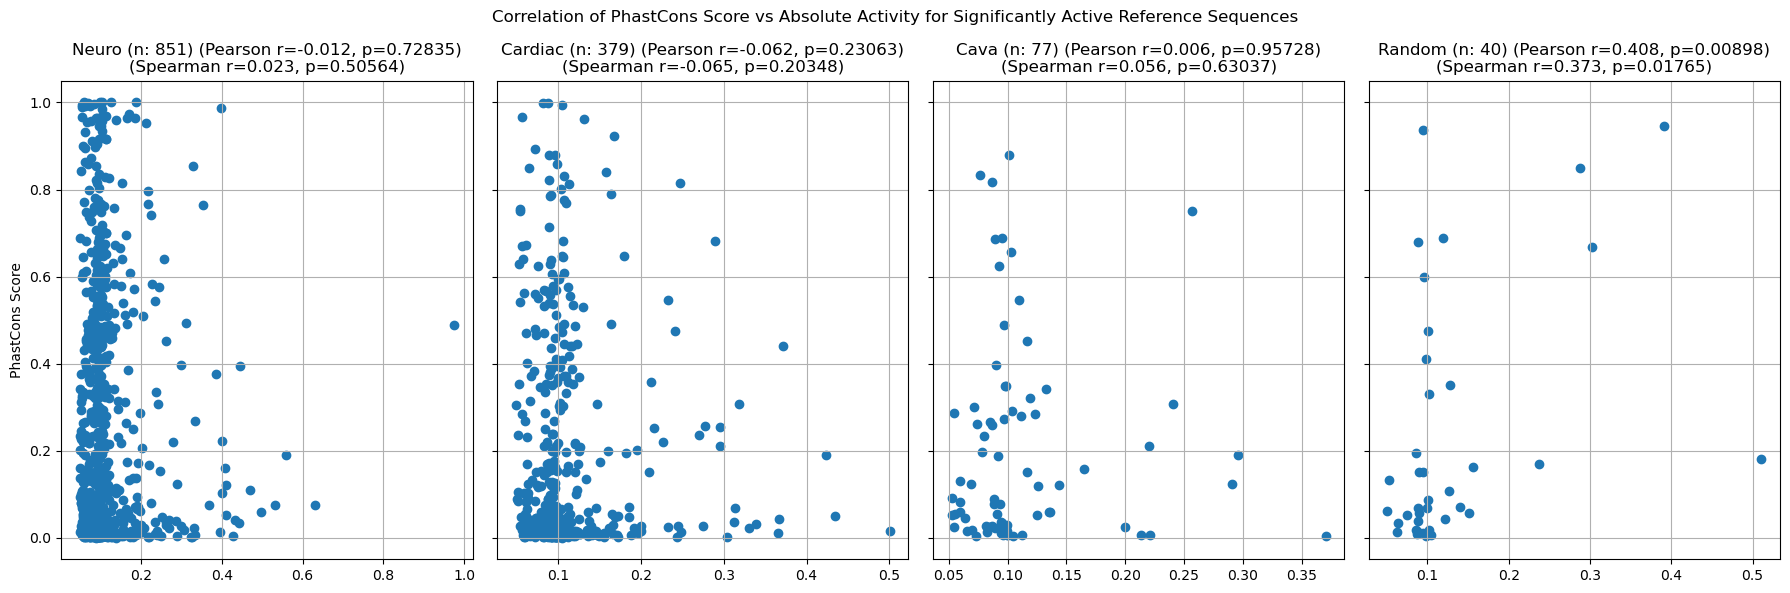

In [100]:
correlation_of_phastCons_vs_mpra_activity(REF_tested_cre_activity_remap_tfbs_occurences_phastCons,
                                            column_to_plot_x="absolute_activity",
                                            column_name_x="Absolute Activity",
                                            column_to_plot_y="mean0",
                                            column_name_y="PhastCons Score",
                                            activity_threshold=None,
                                            conservation_threshold=None,
                                            title="Correlation of PhastCons Score vs Absolute Activity for Significantly Active Reference Sequences",
                                            use_significant_only=True)

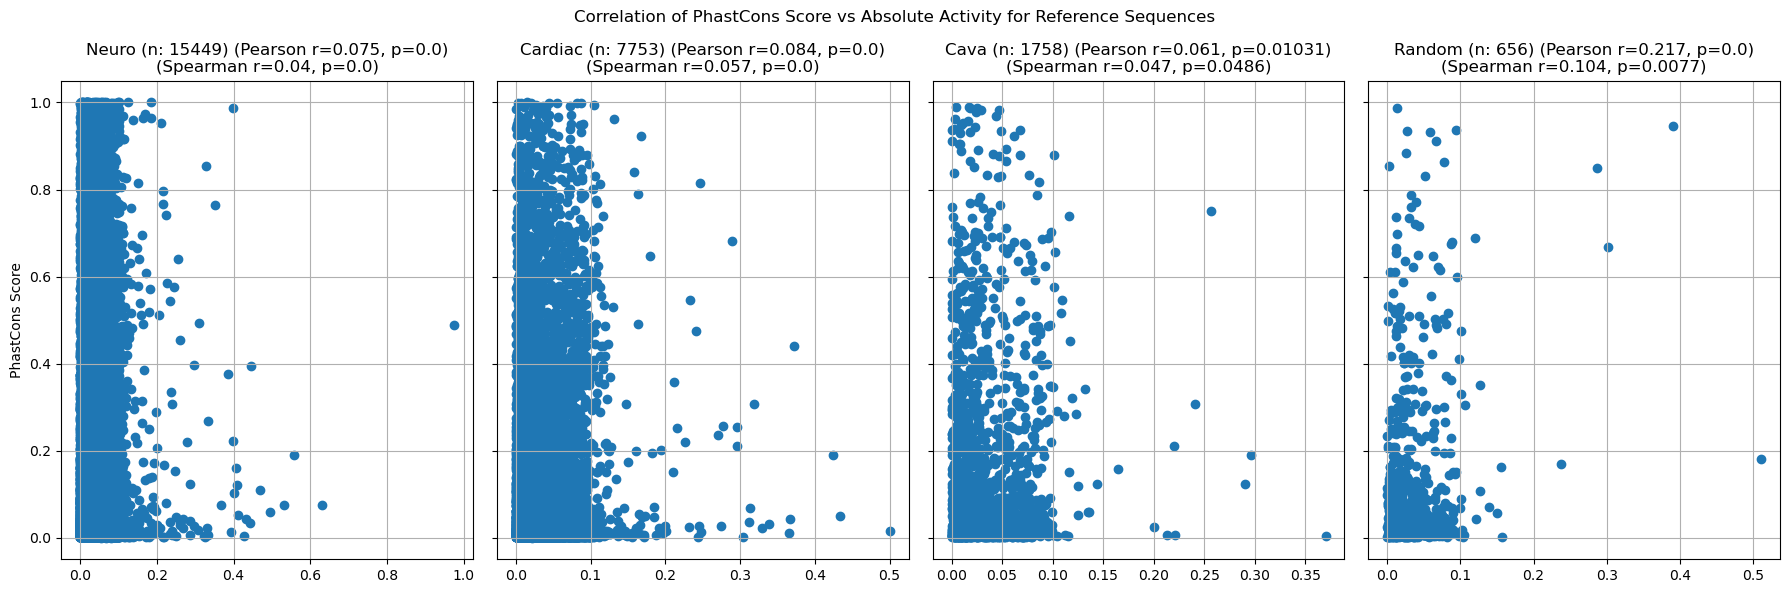

In [101]:
correlation_of_phastCons_vs_mpra_activity(REF_tested_cre_activity_remap_tfbs_occurences_phastCons,
                                            column_to_plot_x="absolute_activity",
                                            column_name_x="Absolute Activity",
                                            column_to_plot_y="mean0",
                                            column_name_y="PhastCons Score",
                                            activity_threshold=None,
                                            conservation_threshold=None,
                                            title="Correlation of PhastCons Score vs Absolute Activity for Reference Sequences",
                                            use_significant_only=None)

### Which Random sequences are so high in activity: Which gene are they associated to: 
- top 42 absolute effect sizes: 

In [102]:
random_cres = REF_tested_cre_activity_remap_tfbs_occurences.loc[REF_tested_cre_activity_remap_tfbs_occurences['gene_set'].apply(lambda x: 'random' in x)].copy()
random_cres
top42_abs_effects = random_cres.loc[random_cres['bcalm_element_log_ratio_activity'].abs().sort_values(ascending=False).head(42).index].copy()
top42_abs_effects

,chrom,start,end,name,strand,TFBS_list,number_of_TFBS,n_unique_TFBS,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,bcalm_data_exists,gene_name,gene_set,SCREEN_ID,is_NPC_SCREEN_cCRE,is_H9_SCREEN_cCRE,is_H1_SCREEN_cCRE,is_neural_stem_SCREEN_cCRE,is_excitatory_neuron_SCREEN_cCRE
18693,chr5,54344722,54344992,cardiac_neuro_cava_random:REF_LINC01033|ENSG00...,+,"[PBX2, GATA4, ONECUT1, FOXA1, MEIS2, TBX5, PKN...",20,20,1.858756e-70,0.510818,True,LINC01033,[random],EH38E2371971,False,False,False,False,False
4876,chr11,6476603,6476873,cardiac_neuro_cava_random:REF_TIMM10B|ENSG0000...,+,"[GATA1, SP2, HNRNPK, MED1, NFYC, ZNF263, ARID1...",20,20,3.667487e-17,0.390697,True,TIMM10B,[random],EH38E2942294,False,False,False,False,False
4844,chr11,6469134,6469404,cardiac_neuro_cava_random:REF_TIMM10B|ENSG0000...,+,"[ZXDB, PITX3, IKZF1, PTBP1, GLIS1, SP3, HMGB2,...",128,126,2.172696e-14,0.301973,True,TIMM10B,[random],EH38E1517444,True,True,True,True,True
13785,chr2,74426467,74426737,cardiac_neuro_cava_random:REF_MOGS|ENSG0000011...,-,"[PCBP1, HNRNPL, ZNF366, GLIS2, KLF17, NCAPH2, ...",34,34,5.677657e-10,0.287133,True,MOGS,[random],EH38E2010389,False,False,False,False,False
14175,chr20,44319907,44320177,cardiac_neuro_cava_random:REF_R3HDML|ENSG00000...,+,"[PGR, FOXA2, CBX8, STAT1, SREBP2, SMARCB1, EBF...",46,45,1.007253e-27,0.237463,True,R3HDML,[random],EH38E2114680,False,False,False,False,False
19576,chr6,26223330,26223600,cardiac_neuro_cava_random:REF_H1-3|ENSG0000012...,-,"[NUTM1, POU2F1, ZNF341, MEN1, ATRX, CREB1, NAN...",36,35,1.127782e-18,0.156703,True,H1-3,[random],EH38E3697677,True,False,False,True,False
12902,chr2,210620571,210620841,cardiac_neuro_cava_random:REF_CPS1|ENSG0000002...,+,"[GLYR1, RBBP5, TRIM28, YY1, JUN, POU5F1, CREB1...",25,25,4.056469e-09,0.155681,True,CPS1,[random],EH38E3397530,False,True,True,False,False
14944,chr22,22651653,22651923,cardiac_neuro_cava_random:REF_IGLV3-25|ENSG000...,+,[MYOD1],1,1,1.504818e-08,0.150636,True,IGLV3-25,[random],EH38E3470178,False,False,False,False,True
17232,chr4,107987976,107988246,cardiac_neuro_cava_random:REF_HADH|ENSG0000013...,+,"[ELF3, PGR]",2,2,3.584516e-37,0.139715,True,HADH,[random],EH38E2318598,False,False,False,False,False
12951,chr2,219219391,219219661,cardiac_neuro_cava_random:REF_ANKZF1|ENSG00000...,+,"[POU5F1, ATF2, SOX8, SRSF3, HDGF, SIN3A, TEAD1...",37,37,1.033140e-06,0.127397,True,ANKZF1,[random],EH38E3401197,True,True,True,True,False


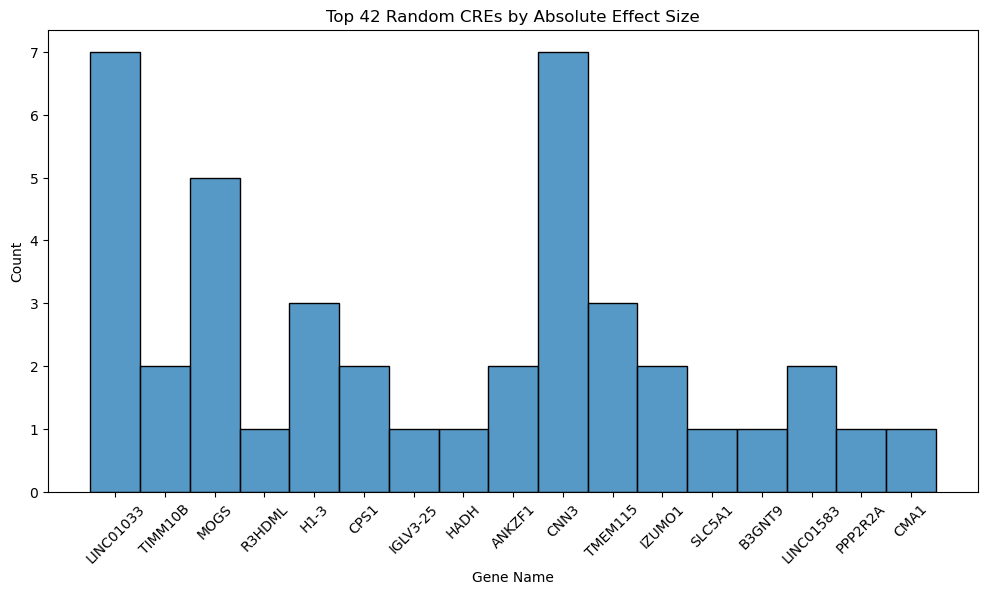

In [103]:
# plot the gene names histogram using seaborn with rotated x ticks labels
plt.figure(figsize=(12, 6))
sns.histplot(top42_abs_effects['gene_name'], bins=len(top42_abs_effects), kde=False)
plt.xticks(rotation=45)
plt.xlabel('Gene Name')
plt.ylabel('Count')
plt.title('Top 42 Random CREs by Absolute Effect Size')
plt.show()

In [104]:
asdf

NameError: name 'asdf' is not defined

### Population constraint: gnomAD singleton number per CRE
- Download gnomAD for the population constraint analysis of the sequence groups

- `/data/cephfs-1/scratch/groups/kircher/MPRA/IGVF_Y1_design/projects/80K_MPRA/singleton_frequency`
##### Only for tested CREs:
```
bedtools intersect -a sorted_tested_genomic_SCREEN_regions_without_chr.bed -b sorted_singleton_variants.bed -c > CRE_singleton_overlaps_with_counts.bed
```

##### For all Sequences: 
- upload and processing: 
```
scp all_SCREEN_GRCh38-cCREs_without_chr.bed.gz kisa11_c@vpn-bihtransfer2:/data/cephfs-1/scratch/groups/kircher/MPRA/IGVF_Y1_design/projects/80K_MPRA/singleton_frequency

coa mobil

bedtools intersect -a all_SCREEN_GRCh38-cCREs_without_chr.bed.gz -b sorted_singleton_variants.bed -c > all_CRE_singleton_overlaps_with_counts.bed

scp kisa11_c@vpn-bihtransfer2:/data/cephfs-1/scratch/groups/kircher/MPRA/IGVF_Y1_design/projects/80K_MPRA/singleton_frequency/all_CRE_singleton_overlaps_with_counts.bed.gz /home/kisa/coding/80K_MPRA/singleton_frequency_per_element/

=> /home/kisa/coding/80K_MPRA/singleton_frequency_per_element/all_CRE_singleton_overlaps_with_counts.bed.gz
```

In [ ]:
from gnomad_db.database import gnomAD_DB
download_link = " https://zenodo.org/records/11077663/files/gnomad_db.sqlite3.gz?download=1"
output_dir = "/data/cephfs-2/unmirrored/groups/kircher/users/kisa11_c/projects/population_constraint_gnomad_singlton" # database_location
gnomAD_DB.download_and_unzip(download_link, output_dir)

ModuleNotFoundError: No module named 'gnomad_db'

In [ ]:
# extract all singleton variants:
import sqlite3
import pandas as pd

# Define the path to your gnomAD SQLite database file
db_path = 'gnomad_db.sqlite3'

# The table and column names based on your schema
table_name = 'gnomad_db'
allele_count_column = 'AC'

try:
    # Connect to the database
    with sqlite3.connect(db_path) as conn:
        # Define the SQL query to select all variants where the Allele Count (AC) is 1.0.
        # Use 1.0 because the AC column type is REAL (a floating-point number).
        query = f"SELECT * FROM {table_name} WHERE {allele_count_column} = 1.0;"

        # Use pandas to read the query results directly into a DataFrame
        print("Querying the database for singleton variants...")
        singleton_variants_df = pd.read_sql_query(query, conn)
        print("Query complete.")

    # Display the results
    print(f"\nFound {len(singleton_variants_df)} singleton variants.")
    print("\nFirst 5 singleton variants:")
    print(singleton_variants_df.head())

    # Optionally, save the results to a CSV file for easy access
    output_filename = 'singleton_variants.csv.gz'
    singleton_variants_df.to_csv(output_filename, index=False)
    print(f"\nSingleton variants saved to {output_filename}")

except sqlite3.OperationalError as e:
    print(f"Error: {e}")
    print("Please ensure the database file path is correct.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

In [ ]:
# download all the singleton variant list
singleton_CRE_overlap_number_bed = "/home/kisa/coding/80K_MPRA/singleton_frequency_per_element/CRE_singleton_overlaps_with_counts.bed"
singleton_CRE_ovelap_number = pd.read_csv(singleton_CRE_overlap_number_bed, sep="\t", header=None)
singleton_CRE_ovelap_number.columns = ['chrom_no_chr', 'start', 'end', 'SCREEN_ID', 'singleton_overlap_count']
singleton_CRE_ovelap_number

,chrom_no_chr,start,end,SCREEN_ID,singleton_overlap_count
0,1,2179507,2179777,EH38E2778471,36
1,1,2181843,2182113,EH38E2778476,37
2,1,2182439,2182709,EH38E2778477,31
3,1,2182830,2183100,EH38E2778478,31
4,1,2185027,2185297,EH38E2778480,39
...,...,...,...,...,...
27278,X,154531979,154532249,EH38E3949715,24
27279,X,154539055,154539325,EH38E3949725,19
27280,X,154545000,154545270,EH38E3949733,24
27281,X,154549802,154550072,EH38E2774396,23


In [ ]:
NGN2_element_activity_tested['start'] = NGN2_element_activity_tested['start'].astype(int)
NGN2_element_activity_tested['end'] = NGN2_element_activity_tested['end'].astype(int)
NGN2_element_activity_tested['chrom_no_chr'] = NGN2_element_activity_tested['chr'].str.replace('chr', '')
NGN2_element_activity_tested

,name,sequence,category,class,source,ref,chr,start,end,strand,...,bcalm_element_log_ratio_activity,bcalm_data_exists,label,not_shifted_bcalm_element_log_ratio_activity,bcalm_element_log_ratio_activity_z_score_neg_ctrl,bcalm_element_log_ratio_activity_z_score_scrambled_ctrl,SCREEN_ID,gene_name,gene_set,chrom_no_chr
2287,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843,2182113,+,...,-0.074506,True,cardiac_neuro_cava_random,-0.074506,0.255056,-1.534950,EH38E2778476,SKI,[neuro],1
2288,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439,2182709,+,...,0.024747,True,cardiac_neuro_cava_random,0.024747,3.065142,1.031757,EH38E2778477,SKI,[neuro],1
2289,cardiac_neuro_cava_random:SKI|ENSG00000157933....,ACGAGCAAGGGAATGAGAGAGAGTGGGTTAGAGAGTGAGTGAGCCA...,element,test,NaN,GRCh38,chr1,2182830,2183100,+,...,0.058800,True,cardiac_neuro_cava_random,0.058800,4.029274,1.912386,EH38E2778478,SKI,[neuro],1
2290,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CGTGGACACGCGTGATTGACCCTTTAACTGTATCCTTAACCACCGC...,element,test,NaN,GRCh38,chr1,2185027,2185297,+,...,-0.071544,True,cardiac_neuro_cava_random,-0.071544,0.338923,-1.458346,EH38E2778480,SKI,[neuro],1
2291,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389,2188659,+,...,-0.044408,True,cardiac_neuro_cava_random,-0.044408,1.107215,-0.756596,EH38E2778484,SKI,[neuro],1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76222,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,variant,test,NaN,GRCh38,chrX,154545000,154545270,-,...,0.065547,True,cardiac_neuro_cava_random,0.065547,4.220287,2.086855,EH38E3949733,G6PD,[cava],X
76223,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,variant,test,NaN,GRCh38,chrX,154549802,154550072,-,...,-0.090558,True,cardiac_neuro_cava_random,-0.090558,-0.199415,-1.950059,EH38E2774396,G6PD,[cava],X
76224,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,variant,test,NaN,GRCh38,chrX,154552145,154552415,-,...,0.052674,True,cardiac_neuro_cava_random,0.052674,3.855845,1.753977,EH38E3949745,G6PD,[cava],X
76225,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCTC...,variant,test,NaN,GRCh38,chrX,154552145,154552415,-,...,0.016824,True,cardiac_neuro_cava_random,0.016824,2.840822,0.826865,EH38E3949745,G6PD,[cava],X


In [ ]:
NGN2_element_activity_tested_singleton_overlap = NGN2_element_activity_tested.merge(singleton_CRE_ovelap_number[['chrom_no_chr', 'start', 'end', 'singleton_overlap_count']], on=['chrom_no_chr', 'start', 'end'], how='left')

# drop chrom_no_chr
NGN2_element_activity_tested_singleton_overlap.drop(columns=['chrom_no_chr'], inplace=True)
NGN2_element_activity_tested_singleton_overlap
# Consider only Reference sequences:
NGN2_natural_CREs_activity_tested_singleton_overlap = NGN2_element_activity_tested_singleton_overlap.loc[~NGN2_element_activity_tested_singleton_overlap['name'].str.contains("ALT_")]
NGN2_natural_CREs_activity_tested_singleton_overlap

,name,sequence,category,class,source,ref,chr,start,end,strand,...,bcalm_element_log_ratio_activity,bcalm_data_exists,label,not_shifted_bcalm_element_log_ratio_activity,bcalm_element_log_ratio_activity_z_score_neg_ctrl,bcalm_element_log_ratio_activity_z_score_scrambled_ctrl,SCREEN_ID,gene_name,gene_set,singleton_overlap_count
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843,2182113,+,...,-0.074506,True,cardiac_neuro_cava_random,-0.074506,0.255056,-1.534950,EH38E2778476,SKI,[neuro],37
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439,2182709,+,...,0.024747,True,cardiac_neuro_cava_random,0.024747,3.065142,1.031757,EH38E2778477,SKI,[neuro],31
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,ACGAGCAAGGGAATGAGAGAGAGTGGGTTAGAGAGTGAGTGAGCCA...,element,test,NaN,GRCh38,chr1,2182830,2183100,+,...,0.058800,True,cardiac_neuro_cava_random,0.058800,4.029274,1.912386,EH38E2778478,SKI,[neuro],31
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CGTGGACACGCGTGATTGACCCTTTAACTGTATCCTTAACCACCGC...,element,test,NaN,GRCh38,chr1,2185027,2185297,+,...,-0.071544,True,cardiac_neuro_cava_random,-0.071544,0.338923,-1.458346,EH38E2778480,SKI,[neuro],39
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389,2188659,+,...,-0.044408,True,cardiac_neuro_cava_random,-0.044408,1.107215,-0.756596,EH38E2778484,SKI,[neuro],34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25645,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,ACCCCACTGCTGCACCAGATTGAGCTGGAGAAGCCCAAGCCCATCC...,variant,test,NaN,GRCh38,chrX,154531979,154532249,-,...,-0.087741,True,cardiac_neuro_cava_random,-0.087741,-0.119654,-1.877206,EH38E3949715,G6PD,[cava],24
25646,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,TTGCTGAGTAGTATCCGTTGTATGAATGCACAGTTTGCCGGGTCAC...,variant,test,NaN,GRCh38,chrX,154539055,154539325,-,...,0.025920,True,cardiac_neuro_cava_random,0.025920,3.098377,1.062113,EH38E3949725,G6PD,[cava],19
25647,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,variant,test,NaN,GRCh38,chrX,154545000,154545270,-,...,0.100370,True,cardiac_neuro_cava_random,0.100370,5.206220,2.987397,EH38E3949733,G6PD,[cava],24
25648,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,variant,test,NaN,GRCh38,chrX,154549802,154550072,-,...,-0.080632,True,cardiac_neuro_cava_random,-0.080632,0.081627,-1.693358,EH38E2774396,G6PD,[cava],23


Summary Statistics with Group Sizes:
  Gene_Set        All  Significant  All_Count  Significant_Count
0    neuro  31.308385    31.312711      16113                889
1  cardiac  30.374798    30.779188       8039                394
2     cava  30.674176    31.625000       1820                 80
3   random  30.714912    31.952381        684                 42


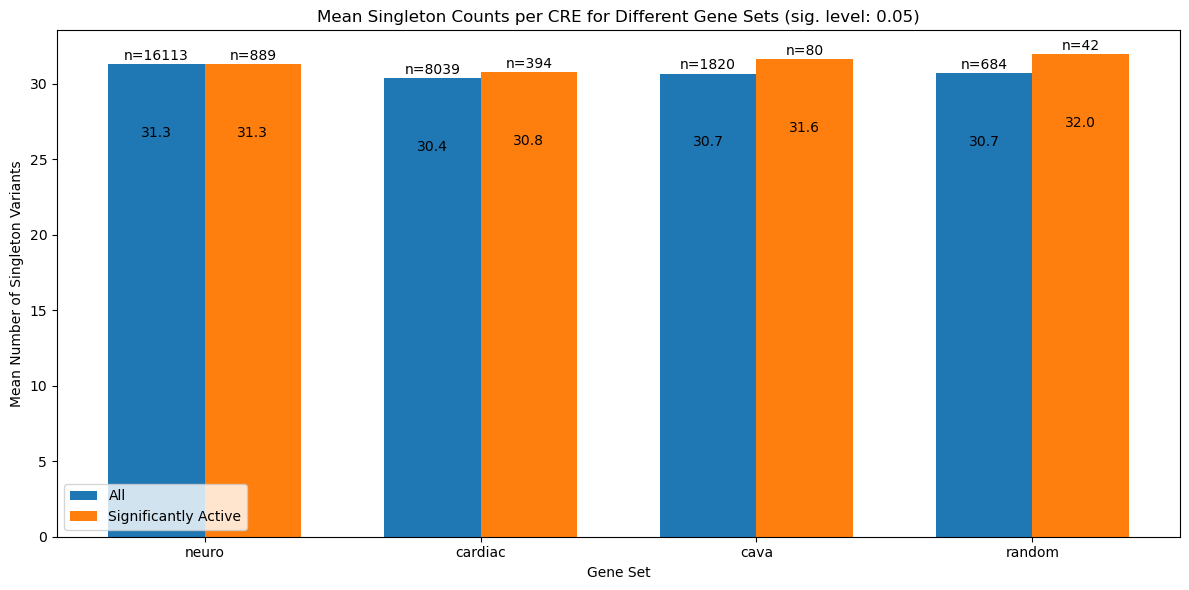

In [ ]:
plot_gene_set_for_all_vs_significant(
    df=NGN2_natural_CREs_activity_tested_singleton_overlap,
    group_list=['neuro', 'cardiac', 'cava', 'random'], # Make sure these match your 'gene_set' values
    column_to_plot='singleton_overlap_count',
    y_label='Mean Number of Singleton Variants',
    title='Mean Singleton Counts per CRE for Different Gene Sets',
    significance_threshold=significance_threshold,
    legend_location='lower left'
)

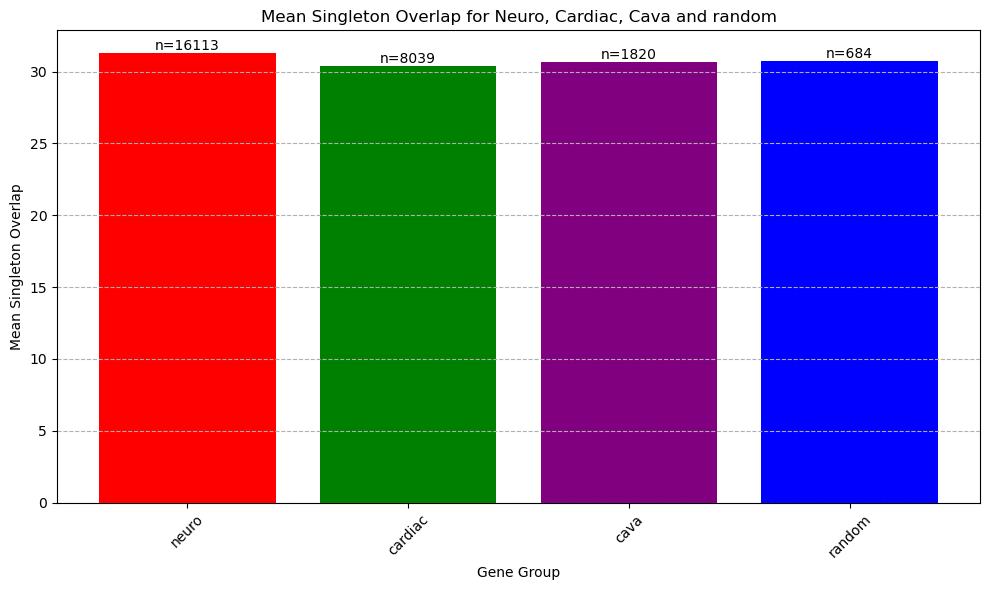

In [ ]:
group_sums = {}
group_counts = {}

# Calculate the sum and count for each group using the .apply() method.
for group in groups:
    # Filter the DataFrame for the current group
    filtered_df = NGN2_natural_CREs_activity_tested_singleton_overlap[
        NGN2_natural_CREs_activity_tested_singleton_overlap['gene_set'].apply(lambda x: group in x)
    ]
    # Store the sum and count
    group_sums[group] = filtered_df['singleton_overlap_count'].mean()
    group_counts[group] = len(filtered_df)

# Create a DataFrame for plotting, making it easier to manage both sum and count
plot_data = pd.DataFrame({
    'Gene_Set': groups,
    'Mean Singleton Overlap': [group_sums[g] for g in groups],
    'Count': [group_counts[g] for g in groups]
})

# Create the bar plot.
fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ['red', 'green', 'purple', 'blue']
bars = ax.bar(plot_data['Gene_Set'], plot_data['Mean Singleton Overlap'], color=bar_colors)

# Add group sizes as text labels on top of each bar
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height,
            f'n={plot_data["Count"].iloc[i]}',
            ha='center', va='bottom')

plt.title('Mean Singleton Overlap for Neuro, Cardiac, Cava and random')
plt.xlabel('Gene Group')
plt.ylabel('Mean Singleton Overlap')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()

In [ ]:
REF_tested_cre_activity_remap_tfbs_occurences

,chrom,start,end,name,strand,TFBS_list,number_of_TFBS,n_unique_TFBS,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,bcalm_data_exists,gene_name,gene_set,SCREEN_ID,is_NPC_SCREEN_cCRE,is_H9_SCREEN_cCRE,is_H1_SCREEN_cCRE,is_neural_stem_SCREEN_cCRE,is_excitatory_neuron_SCREEN_cCRE
0,chr1,10588680,10588950,cardiac_neuro_cava_random:REF_CASZ1|ENSG000001...,-,[MAFF],1,1,1.0,0.015284,True,CASZ1,[neuro],EH38E1318114,False,False,False,False,False
1,chr1,10594736,10595006,cardiac_neuro_cava_random:REF_CASZ1|ENSG000001...,-,"[RBPJ, MEF2B, TFAP2C, SND1, ZNF263, POU5F1, SM...",24,24,1.0,0.018937,True,CASZ1,[neuro],EH38E1318122,False,True,False,False,False
2,chr1,10597875,10598145,cardiac_neuro_cava_random:CASZ1|ENSG0000013094...,-,"[SMARCC1, KLF4, TFAP2C, EZH2, RBBP4, SS18, MYC...",13,13,1.0,-0.052969,True,CASZ1,[neuro],EH38E1318127,False,False,False,False,False
3,chr1,10599192,10599462,cardiac_neuro_cava_random:CASZ1|ENSG0000013094...,-,"[EGR1, CREBBP, ZNF44, HOXA3, ARID2, MED1, ZBTB...",133,130,1.0,-0.029333,True,CASZ1,[neuro],EH38E2785540,False,False,False,False,False
4,chr1,10601429,10601699,cardiac_neuro_cava_random:CASZ1|ENSG0000013094...,-,"[KMT2A, RAD21, ZNF3, NR3C1, ZNF550, MYCN, NKX2...",13,13,1.0,-0.070292,True,CASZ1,[neuro],EH38E2785543,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24581,chrX,77784045,77784315,cardiac_neuro_cava_random:ATRX|ENSG00000085224...,-,"[CRX, MEF2D, OTX2, SMARCA4, TBX21, RBFOX2, BCL...",9,9,1.0,-0.039769,True,ATRX,[neuro],EH38E2759267,False,False,False,False,False
24582,chrX,77786807,77787077,cardiac_neuro_cava_random:REF_ATRX|ENSG0000008...,-,"[ZSCAN4, FOXA1, RFX5, SPI1, ZBTB2, SPIB, KDM1A...",8,8,1.0,0.035090,True,ATRX,[neuro],EH38E2759274,False,False,False,False,False
24583,chrX,77787587,77787857,cardiac_neuro_cava_random:ATRX|ENSG00000085224...,-,"[BRD4, ZGPAT, HAND2, PHOX2B, ZBED4, TEAD4, SRE...",9,9,1.0,-0.010949,True,ATRX,[neuro],EH38E2759276,False,False,False,False,False
24584,chrX,77788137,77788407,cardiac_neuro_cava_random:ATRX|ENSG00000085224...,-,"[LIN54, SREBP2, MYBL2, FOXA2, ZNF24, KLF4, NFY...",45,45,1.0,-0.031196,True,ATRX,[neuro],EH38E3938017,False,False,False,False,False


In [129]:
# average over all CREs from SCREEN:
singleton_all_SCREE_CRE_path = "/home/kisa/coding/80K_MPRA/singleton_frequency_per_element/all_CRE_singleton_overlaps_with_counts.bed.gz"
singleton_all_SCREEN_CRE = pd.read_csv(singleton_all_SCREE_CRE_path, sep="\t", header=None, compression='gzip')
singleton_all_SCREEN_CRE.columns = ['chrom_no_chr', 'start', 'end', 'SCREEN_ID', 'score', 'strand', 'singleton_overlap_count']
singleton_all_SCREEN_CRE


/tmp/ipykernel_420402/2225868298.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  singleton_all_SCREEN_CRE = pd.read_csv(singleton_all_SCREE_CRE_path, sep="\t", header=None, compression='gzip')


,chrom_no_chr,start,end,SCREEN_ID,score,strand,singleton_overlap_count
0,1,10033,10250,EH38D4327497,0,.,117
1,1,10385,10713,EH38D4327498,0,.,168
2,1,16097,16381,EH38D6144701,0,.,57
3,1,17343,17642,EH38D6144702,0,.,45
4,1,29320,29517,EH38D6144703,0,.,27
...,...,...,...,...,...,...,...
2348849,Y,26670948,26671287,EH38D6144696,0,.,0
2348850,Y,26671292,26671478,EH38D6144697,0,.,0
2348851,Y,26671538,26671787,EH38D6473458,0,.,0
2348852,Y,56684007,56684171,EH38D6144699,0,.,2


In [130]:
singleton_all_SCREEN_CRE['singleton_overlap_count'].describe()

count    2.348854e+06
mean     3.260669e+01
std      1.418454e+01
min      0.000000e+00
25%      2.300000e+01
50%      3.100000e+01
75%      3.900000e+01
max      1.437000e+03
Name: singleton_overlap_count, dtype: float64

In [131]:
# compute sequence length:
singleton_all_SCREEN_CRE['sequence_length'] = singleton_all_SCREEN_CRE['end'] - singleton_all_SCREEN_CRE['start']
singleton_all_SCREEN_CRE['sequence_length'].describe()
singleton_all_SCREEN_CRE['singleton_count_per_base'] = singleton_all_SCREEN_CRE['singleton_overlap_count'] / singleton_all_SCREEN_CRE['sequence_length']
singleton_all_SCREEN_CRE['singleton_count_per_270bp'] = singleton_all_SCREEN_CRE['singleton_count_per_base'] * 270
singleton_all_SCREEN_CRE['singleton_count_per_270bp'].describe()

count    2.348854e+06
mean     3.295866e+01
std      1.186091e+01
min      0.000000e+00
25%      2.668605e+01
50%      3.135484e+01
75%      3.687805e+01
max      1.301722e+03
Name: singleton_count_per_270bp, dtype: float64

In [ ]:
singleton_all_SCREEN_CRE

In [ ]:
# for the potential significant CREs => sample with the expected proportion of 5% 1000 times and plot the confidence interval

## Investigate the transition vs transversion variant effects: 


In [5]:
variant_path = "/home/kisa/coding/80K_MPRA/element_variant_analysis_output/NGN2_variants_metadata_with_bcalm_2025_04_bbmap_normalized_counts.tsv.gz"
variant_bcalm_metadata_df = pd.read_csv(variant_path, sep="\t", low_memory=False)
variant_bcalm_metadata_df

,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,bcalm_reference_log_ratio_activity,bcalm_alternative_adjusted_p_value,bcalm_alternative_log_ratio_activity,label
0,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,[83],False,NaN,NaN,0.022133,0.131536,5.965362e-07,0.190591,cardiac_neuro_cava_random
1,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,[181],False,NaN,NaN,NaN,NaN,NaN,NaN,cardiac_neuro_cava_random
2,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGAGGC...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGATGC...,[43],False,NaN,NaN,NaN,NaN,NaN,NaN,cardiac_neuro_cava_random
3,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,[116],True,0.944787,-0.043372,1.000000,-0.068107,1.000000e+00,-0.072051,cardiac_neuro_cava_random
4,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,[205],True,0.926799,-0.036392,1.000000,0.001944,1.000000e+00,-0.005889,cardiac_neuro_cava_random
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47039,C_positive_heart_CAD:ALT_rs7865618_rs7865618,C_positive_heart_CAD:REF_rs7865618,C_positive_heart_CAD:ALT_rs7865618_rs7865618,TATTGATAACAGGGGATGGATTCTTGTGGACAAAAAAATTTAGAAT...,TATTGATAACAGGGGATGGATTCTTGTGGACAAAAAAATTTAGAAT...,[136],True,0.069025,0.177548,1.000000,-0.037515,1.000000e+00,-0.012714,C_positive_heart_CAD
47040,C_positive_heart_CAD:ALT_rs4977757_rs4977757,C_positive_heart_CAD:REF_rs4977757,C_positive_heart_CAD:ALT_rs4977757_rs4977757,CTGATGGGCTTCCCTTTGTGGGTAACCCGACCTTTCTCTCTGGCTG...,CTGATGGGCTTCCCTTTGTGGGTAACCCGACCTTTCTCTCTGGCTG...,[136],True,0.220035,-0.313776,0.042527,-0.087468,7.038279e-05,-0.102879,C_positive_heart_CAD
47041,C_positive_heart_CAD:ALT_rs1537373_rs1537373,C_positive_heart_CAD:REF_rs1537373,C_positive_heart_CAD:ALT_rs1537373_rs1537373,AGAAAACCATACCCACTTTCCCACATATCCCAACTATGACTGGGCA...,AGAAAACCATACCCACTTTCCCACATATCCCAACTATGACTGGGCA...,[136],True,0.341678,0.214433,1.000000,-0.027086,1.000000e+00,0.002929,C_positive_heart_CAD
47042,C_positive_heart_CAD:ALT_rs10811656_rs10811656,C_positive_heart_CAD:REF_rs10811656,C_positive_heart_CAD:ALT_rs10811656_rs10811656,AAATTAAAAGCTTCTAAACTAACAAACAGCCAATTTGTGGAGTGTC...,AAATTAAAAGCTTCTAAACTAACAAACAGCCAATTTGTGGAGTGTC...,[136],True,0.775080,0.089574,1.000000,-0.070829,1.000000e+00,-0.067582,C_positive_heart_CAD


In [17]:
for col in ['variant_pos']:
    variant_bcalm_metadata_df[col] = variant_bcalm_metadata_df[col].apply(safe_eval)

In [24]:
variant_bcalm_metadata_df_tested = variant_bcalm_metadata_df.loc[variant_bcalm_metadata_df["bcalm_variant_effect_data_exists"] & variant_bcalm_metadata_df['ID'].str.contains("cardiac_neuro_cava_random")].copy()
variant_bcalm_metadata_df_tested

,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,bcalm_reference_log_ratio_activity,bcalm_alternative_adjusted_p_value,bcalm_alternative_log_ratio_activity,label
3,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,[116],True,0.944787,-0.043372,1.000000,-0.068107,1.000000,-0.072051,cardiac_neuro_cava_random
4,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,[205],True,0.926799,-0.036392,1.000000,0.001944,1.000000,-0.005889,cardiac_neuro_cava_random
6,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,[71],True,0.779710,-0.130556,1.000000,-0.053109,1.000000,-0.065999,cardiac_neuro_cava_random
7,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,[144],True,0.953076,-0.034817,1.000000,-0.053109,1.000000,-0.074918,cardiac_neuro_cava_random
8,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,[183],True,0.632794,-0.167928,1.000000,-0.053109,1.000000,-0.060033,cardiac_neuro_cava_random
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46369,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,[64],True,0.911154,-0.076406,0.015993,0.100370,0.451154,0.065547,cardiac_neuro_cava_random
46370,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,[149],True,0.748684,-0.153448,1.000000,-0.080632,0.091747,-0.090558,cardiac_neuro_cava_random
46371,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,[126],True,0.989551,0.007846,0.409652,0.056209,0.436290,0.052674,cardiac_neuro_cava_random
46372,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCTC...,[44],True,0.514030,-0.243036,0.409652,0.056209,1.000000,0.016824,cardiac_neuro_cava_random


In [25]:
# get the reference allele and the alternative allele for each variant
def testing_variant_pos(row, ref_seq, alt_seq, variant_pos):
    # expectation: ref_seq and alt_seq are different just at the variant_pos
    if len(row[variant_pos]) != 1:
        print(row['ID'])
        raise ValueError("Variant position should contain exactly one position.")
    variant_position = int(row[variant_pos][0])
    ref_sequence = row[ref_seq]
    alt_sequence = row[alt_seq]
    ref_allele = ref_sequence[variant_position]
    alt_allele = alt_sequence[variant_position]
    if ref_allele != alt_allele:
        return row
    else:
        print(row['ID'])
        raise ValueError("Reference and alternative alleles are the same at the variant position.")

In [26]:
variant_bcalm_metadata_df_tested.apply(testing_variant_pos, axis=1, ref_seq="ref_sequence", alt_seq="alt_sequence", variant_pos="variant_pos")

,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,bcalm_reference_log_ratio_activity,bcalm_alternative_adjusted_p_value,bcalm_alternative_log_ratio_activity,label
3,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,[116],True,0.944787,-0.043372,1.000000,-0.068107,1.000000,-0.072051,cardiac_neuro_cava_random
4,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,[205],True,0.926799,-0.036392,1.000000,0.001944,1.000000,-0.005889,cardiac_neuro_cava_random
6,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,[71],True,0.779710,-0.130556,1.000000,-0.053109,1.000000,-0.065999,cardiac_neuro_cava_random
7,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,[144],True,0.953076,-0.034817,1.000000,-0.053109,1.000000,-0.074918,cardiac_neuro_cava_random
8,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,[183],True,0.632794,-0.167928,1.000000,-0.053109,1.000000,-0.060033,cardiac_neuro_cava_random
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46369,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,[64],True,0.911154,-0.076406,0.015993,0.100370,0.451154,0.065547,cardiac_neuro_cava_random
46370,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,[149],True,0.748684,-0.153448,1.000000,-0.080632,0.091747,-0.090558,cardiac_neuro_cava_random
46371,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,[126],True,0.989551,0.007846,0.409652,0.056209,0.436290,0.052674,cardiac_neuro_cava_random
46372,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCTC...,[44],True,0.514030,-0.243036,0.409652,0.056209,1.000000,0.016824,cardiac_neuro_cava_random


In [27]:
def classify_transition_vs_transversion(row, ref_seq, alt_seq, variant_pos):
    """if the variant is transition => return 'transition if transversion => return 'transversion'"""
    variant_position = int(row[variant_pos][0])
    ref_sequence = row[ref_seq]
    alt_sequence = row[alt_seq]
    ref_allele = ref_sequence[variant_position]
    alt_allele = alt_sequence[variant_position]
    if (ref_allele in ['A', 'G'] and alt_allele in ['A', 'G']) or (ref_allele in ['C', 'T'] and alt_allele in ['C', 'T']):
        return 'transition'
    else:
        return 'transversion'


In [28]:
variant_bcalm_metadata_df_tested['transition_vs_transversion'] = variant_bcalm_metadata_df_tested.apply(classify_transition_vs_transversion, axis=1, ref_seq="ref_sequence", alt_seq="alt_sequence", variant_pos="variant_pos")
variant_bcalm_metadata_df_tested['transition_vs_transversion'].value_counts()

transition_vs_transversion
transition      24765
transversion    13105
Name: count, dtype: int64

In [29]:
variant_bcalm_metadata_df_tested_significant = variant_bcalm_metadata_df_tested.loc[variant_bcalm_metadata_df_tested['bcalm_variant_effect_adjusted_p_value'] < significance_threshold].copy()
variant_bcalm_metadata_df_tested_significant['transition_vs_transversion'].value_counts()

transition_vs_transversion
transition      616
transversion    350
Name: count, dtype: int64

In [30]:
variant_bcalm_metadata_df_tested_significant

,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,bcalm_reference_log_ratio_activity,bcalm_alternative_adjusted_p_value,bcalm_alternative_log_ratio_activity,label,transition_vs_transversion
52,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GGGAGCGCCCAGCAGGTGTCCAGCGGTGCTGGCGCTGCCTCTGTCT...,GGGAGCGCCCAGCAGGTGTCCAGCGGTGCTGGCGCTGCCTCTGTCT...,[232],True,2.278011e-03,0.543880,1.000000e+00,-0.050667,1.000000e+00,0.015594,cardiac_neuro_cava_random,transition
98,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,AAGTGCTGAGATTACAGGCATGAGCCACTGTGCCCAGCAGGGCTGT...,AAGTGCTGAGATTACAGGCATGAGCCACTGTGCCCAGCAGGGCTGT...,[85],True,1.063292e-02,0.337798,1.000000e+00,0.021916,3.196609e-06,0.079893,cardiac_neuro_cava_random,transition
99,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,AAGTGCTGAGATTACAGGCATGAGCCACTGTGCCCAGCAGGGCTGT...,AAGTGCTGAGATTACAGGCATGAGCCACTGTGCCCAGCAGGGCTGT...,[125],True,2.354474e-18,0.877785,1.000000e+00,0.021916,4.199905e-32,0.186480,cardiac_neuro_cava_random,transition
240,cardiac_neuro_cava_random:ALT_PRDM16|ENSG00000...,cardiac_neuro_cava_random:REF_PRDM16|ENSG00000...,cardiac_neuro_cava_random:ALT_PRDM16|ENSG00000...,GGCTCTTTGCATGTCTCTGGGAAAACCTGATCAGCTGACCCAAACC...,GGCTCTTTGCATGTCTCTGGGAAAACCTGATCAGCTGACCCAAACC...,[60],True,2.490829e-08,-1.011462,1.000000e+00,-0.035330,4.711593e-03,-0.100917,cardiac_neuro_cava_random,transition
295,cardiac_neuro_cava_random:ALT_PRDM16|ENSG00000...,cardiac_neuro_cava_random:REF_PRDM16|ENSG00000...,cardiac_neuro_cava_random:ALT_PRDM16|ENSG00000...,CGTCTGCCTCCCTCACCTCCGCACAGCCCCAAACCCAGAACCGAGC...,CGTCTGCCTCCCTCACCTCCGCACAGCCCCAAACCCAGAACCGAGC...,[75],True,2.773029e-02,-0.406802,1.000000e+00,0.013334,1.000000e+00,-0.035623,cardiac_neuro_cava_random,transition
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46000,cardiac_neuro_cava_random:ALT_FGF13|ENSG000001...,cardiac_neuro_cava_random:REF_FGF13|ENSG000001...,cardiac_neuro_cava_random:ALT_FGF13|ENSG000001...,ACTTTGAGCTTTTCGAGGGCCCTAGCCAAAACAAAATGTTAGATGG...,ACTTTGAGCTTTTCGAGGGCCCTAGCCAAAACAAAATGTTAGATGG...,[198],True,1.152664e-02,0.273233,1.000000e+00,-0.033016,1.000000e+00,0.010618,cardiac_neuro_cava_random,transition
46023,cardiac_neuro_cava_random:ALT_FGF13|ENSG000001...,cardiac_neuro_cava_random:REF_FGF13|ENSG000001...,cardiac_neuro_cava_random:ALT_FGF13|ENSG000001...,ACCTGGTTCAAGCACAGTACAAAGAATACTAACAGAATAACAGTGA...,ACCTGGTTCAAGCACAGTACAAAGAATACTAACAGAATAACAGTGA...,[243],True,3.171487e-04,0.318240,1.000000e+00,-0.026800,1.000000e+00,0.018850,cardiac_neuro_cava_random,transition
46153,cardiac_neuro_cava_random:ALT_MECP2|ENSG000001...,cardiac_neuro_cava_random:REF_MECP2|ENSG000001...,cardiac_neuro_cava_random:ALT_MECP2|ENSG000001...,CACCCTGGCTCTGAGGGGAGACCCACAAAGCAACTTTCTGTTGAGA...,CACCCTGGCTCTGAGGGGAGACCCACAAAGCAACTTTCTGTTGAGA...,[117],True,4.614440e-04,0.436432,1.000000e+00,-0.053030,1.000000e+00,-0.000981,cardiac_neuro_cava_random,transversion
46169,cardiac_neuro_cava_random:ALT_MECP2|ENSG000001...,cardiac_neuro_cava_random:REF_MECP2|ENSG000001...,cardiac_neuro_cava_random:ALT_MECP2|ENSG000001...,AGGTCCCCAGGCTGCTCCATGTGACAGGCACAACCCATCCCCAGTG...,AGGTCCCCAGGCTGCTCCATGTGACAGGCACAACCCATCCCCAGTG...,[191],True,7.565204e-03,0.366324,3.143962e-25,0.154008,2.138371e-21,0.243131,cardiac_neuro_cava_random,transition


In [ ]:
# plot the ratio per AF: